<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.

- **Group member 1:** Full name, SCIPER number, email address  
- **Group member 2:** Full name, SCIPER number, email address  
- **Group member 3 (if applicable):** Full name, SCIPER number, email address  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

## 0.5 Provided data

All main data are stored in `/shared/NX-414/data/`.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

In [1]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch
import os

In [3]:
# 2. Define Paths
DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

# Neural Data Paths
tvsd_path = os.path.join(DATA_DIR, "tvsd.h5")
eeg_path = os.path.join(DATA_DIR, "things_eeg2.h5")
nsd_path = os.path.join(DATA_DIR, "nsd_func1pt8mm_individualROIs.h5")

# Feature Paths (Assuming subdirectories for the models)
model_a_dir = os.path.join(FEAT_DIR, "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0")
model_b_dir = os.path.join(FEAT_DIR, "Qwen3-VL-2B-Instruct")

In [4]:
# 3. Utility Functions
def inspect_h5_structure(file_path):
    """Recursively prints the structure of an h5 file without loading data into RAM."""
    def print_attrs(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  Dataset: {name} | Shape: {obj.shape} | Type: {obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"Group: {name}")
            
    with h5py.File(file_path, 'r') as f:
        print(f"--- Inspecting: {os.path.basename(file_path)} ---")
        f.visititems(print_attrs)
        print("\n")

inspect_h5_structure(tvsd_path)
inspect_h5_structure(eeg_path)
inspect_h5_structure(nsd_path)

--- Inspecting: tvsd.h5 ---
Group: noise_ceilings
Group: noise_ceilings/monkeyF
  Dataset: noise_ceilings/monkeyF/IT | Shape: (241,) | Type: float64
  Dataset: noise_ceilings/monkeyF/V1 | Shape: (462,) | Type: float64
  Dataset: noise_ceilings/monkeyF/V4 | Shape: (139,) | Type: float64
Group: noise_ceilings/monkeyN
  Dataset: noise_ceilings/monkeyN/IT | Shape: (178,) | Type: float64
  Dataset: noise_ceilings/monkeyN/V1 | Shape: (437,) | Type: float64
  Dataset: noise_ceilings/monkeyN/V4 | Shape: (247,) | Type: float64
Group: test
Group: test/neural_data
Group: test/neural_data/monkeyF
  Dataset: test/neural_data/monkeyF/IT | Shape: (100, 241) | Type: float64
  Dataset: test/neural_data/monkeyF/V1 | Shape: (100, 462) | Type: float64
  Dataset: test/neural_data/monkeyF/V4 | Shape: (100, 139) | Type: float64
Group: test/neural_data/monkeyN
  Dataset: test/neural_data/monkeyN/IT | Shape: (100, 178) | Type: float64
  Dataset: test/neural_data/monkeyN/V1 | Shape: (100, 437) | Type: float64
 

In [5]:
# 3. Dataset and Feature Overview
data_summary = {
    "Dataset": ["TVSD (Macaque)", "THINGS-EEG2 (Human)", "NSD (Human fMRI)"],
    "Modality": ["Electrophysiology", "EEG", "fMRI"],
    "Train Stimuli": [22248, 16540, "8302 - 9000 (per subj)"],
    "Test Stimuli": [100, 200, "907 - 1000 (per subj)"],
    "Data Shape": ["(stimuli, units)", "(stimuli, channels, timepoints)", "(stimuli, voxels)"]
}
print("=== Dataset Overview ===")
display(pd.DataFrame(data_summary))
print("\n*Model Features (ResNet & Qwen3-VL) are flattened to 30,000 dimensions and match the neural stimulus sets.\n")

=== Dataset Overview ===


,Dataset,Modality,Train Stimuli,Test Stimuli,Data Shape
0,TVSD (Macaque),Electrophysiology,22248,100,"(stimuli, units)"
1,THINGS-EEG2 (Human),EEG,16540,200,"(stimuli, channels, timepoints)"
2,NSD (Human fMRI),fMRI,8302 - 9000 (per subj),907 - 1000 (per subj),"(stimuli, voxels)"



*Model Features (ResNet & Qwen3-VL) are flattened to 30,000 dimensions and match the neural stimulus sets.



In [6]:
# Inspect Model A (ResNet)
print("\n--- Inspecting Model A (ResNet-152) Features ---")
inspect_h5_structure(os.path.join(model_a_dir, "things_stimuli.h5"))

# Inspect Model B (Qwen3)
print("\n--- Inspecting Model B (Qwen3-VL) Features ---")
inspect_h5_structure(os.path.join(model_b_dir, "things_stimuli.h5"))


--- Inspecting Model A (ResNet-152) Features ---
--- Inspecting: things_stimuli.h5 ---
Group: features
  Dataset: features/layer1-0 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer2-0 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer3-0 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer3-10 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer3-15 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer3-20 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer3-25 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer3-30 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer3-5 | Shape: (26107, 30000) | Type: float16
  Dataset: features/layer4-1 | Shape: (26107, 30000) | Type: float16
  Dataset: ids | Shape: (26107,) | Type: object



--- Inspecting Model B (Qwen3-VL) Features ---
--- Inspecting: things_stimuli.h5 ---
Group: features
  Dataset: features/language_model-layers-11 | Sh

In [7]:
# 4. Verify Stimulus Matching
def verify_things_match(neural_path, feature_path):
    """Verifies that string byte IDs match exactly for TVSD/EEG."""
    with h5py.File(neural_path, 'r') as f_neu, h5py.File(feature_path, 'r') as f_feat:
        # Using the exact keys found in your inspection
        neural_ids = f_neu['train/stimulus_ids'][:] 
        feat_ids = f_feat['ids'][:]
        
        # Check if the first neural ID exists in the feature set
        assert neural_ids[0] in feat_ids, f"Mismatch: Neural ID {neural_ids[0]} not found in features!"
    print(f"✅ THINGS Matching Verified for {os.path.basename(neural_path)}")

def verify_nsd_match(neural_path, feature_path):
    """Implements the recommended efficient matching for NSD integer IDs."""
    with h5py.File(neural_path, 'r') as f_neu, h5py.File(feature_path, 'r') as f_feat:
        # Using subj01's exact key from your inspection
        neural_ids = f_neu['train/stimulus_ids/subj01'][:] 
        feat_ids = f_feat['ids'][:]
        
        # 1. Build the index mapping
        id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
        
        # 2. Map neural IDs to feature row indices
        feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
        
        # 3. Assert we have a matching feature row for every neural stimulus
        assert len(feat_idx) == len(neural_ids), "Mismatch in array lengths!"
        assert feat_ids[feat_idx[0]] == neural_ids[0], "Mapping failed: IDs do not match!"
        
    print(f"✅ NSD Matching Verified for {os.path.basename(neural_path)} (Subject 01)")

# Run the assertions
print("=== Running Assertions ===")
try:
    verify_things_match(tvsd_path, os.path.join(model_a_dir, "things_stimuli.h5"))
    verify_things_match(eeg_path, os.path.join(model_a_dir, "things_stimuli.h5"))
    verify_nsd_match(nsd_path, os.path.join(model_a_dir, "nsd_stimuli.h5"))
except Exception as e:
    print(f"❌ Assertion failed: {e}")

=== Running Assertions ===
✅ THINGS Matching Verified for tvsd.h5
✅ THINGS Matching Verified for things_eeg2.h5
✅ NSD Matching Verified for nsd_func1pt8mm_individualROIs.h5 (Subject 01)


---

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

In [8]:
# TODO: inspect TVSD
# TODO: inspect EEG2
# TODO: inspect NSD
# TODO: summarize axis meaning

In [9]:
# ==========================================
# 1.1 Inspect the Datasets: TVSD
# ==========================================
import pandas as pd

tvsd_structure = {
    "Array / Group Path": [
        "train/neural_data/{monkey}/{ROI}",
        "test/neural_data/{monkey}/{ROI}",
        "train/stimulus_ids",
        "test/stimulus_ids",
        "noise_ceilings/{monkey}/{ROI}"
    ],
    "Example Shape (Monkey F, V1)": [
        "(22248, 462)",
        "(100, 462)",
        "(22248,)",
        "(100,)",
        "(462,)"
    ],
    "Meaning of Axis 0": [
        "Stimuli (Images)",
        "Stimuli (Images)",
        "Stimuli (Image Filepaths)",
        "Stimuli (Image Filepaths)",
        "Units (Neurons/Sites)"
    ],
    "Meaning of Axis 1": [
        "Units (Neurons/Sites)",
        "Units (Neurons/Sites)",
        "N/A (1D Array)",
        "N/A (1D Array)",
        "N/A (1D Array)"
    ]
}

tvsd_df = pd.DataFrame(tvsd_structure)
print("=== TVSD (Macaque Electrophysiology) Structure ===")
display(tvsd_df)

# ==========================================
# 1.1 Inspect the Datasets: EEG2 & NSD
# ==========================================

# --- EEG2 Structure Table ---
eeg2_structure = {
    "Array / Group Path": [
        "train/neural_data/{sub}/{ROI}",
        "test/neural_data/{sub}/{ROI}",
        "train/stimulus_ids",
        "noise_ceilings/{sub}/{ROI}"
    ],
    "Example Shape (Sub-01, whole_brain)": [
        "(16540, 63, 80)",
        "(200, 63, 80)",
        "(16540,)",
        "(63, 80)"
    ],
    "Meaning of Axis 0": [
        "Stimuli (Images)",
        "Stimuli (Images)",
        "Stimuli (Image Filepaths)",
        "Channels (EEG Electrodes)"
    ],
    "Meaning of Axis 1": [
        "Channels (EEG Electrodes)",
        "Channels (EEG Electrodes)",
        "N/A",
        "Timepoints (10ms steps)"
    ],
    "Meaning of Axis 2": [
        "Timepoints (10ms steps)",
        "Timepoints (10ms steps)",
        "N/A",
        "N/A"
    ]
}

eeg2_df = pd.DataFrame(eeg2_structure)
print("=== THINGS-EEG2 (Human EEG) Structure ===")
display(eeg2_df)
print("\n")

# --- NSD Structure Table ---
nsd_structure = {
    "Array / Group Path": [
        "train/neural_data/{subj}/{ROI}",
        "test/neural_data/{subj}/{ROI}",
        "train/stimulus_ids/{subj}",
        "noise_ceilings/{subj}/{ROI}",
        "roi_labels/{subj}/{ROI}"
    ],
    "Example Shape (Subj-01, V1v)": [
        "(9000, 570)",
        "(1000, 570)",
        "(9000,)",
        "(570,)",
        "(81, 104, 83) *" 
    ],
    "Meaning of Axis 0": [
        "Stimuli (Images)",
        "Stimuli (Images)",
        "Stimuli (Integer IDs)",
        "Voxels (3D Pixels)",
        "Spatial X-coordinate"
    ],
    "Meaning of Axis 1": [
        "Voxels (3D Pixels)",
        "Voxels (3D Pixels)",
        "N/A",
        "N/A",
        "Spatial Y-coordinate"
    ],
    "Meaning of Axis 2": [
        "N/A",
        "N/A",
        "N/A",
        "N/A",
        "Spatial Z-coordinate"
    ]
}

nsd_df = pd.DataFrame(nsd_structure)
print("=== NSD (Human fMRI) Structure ===")
display(nsd_df)
print("* Note: roi_labels are 3D boolean masks representing the physical brain space.")

=== TVSD (Macaque Electrophysiology) Structure ===


,Array / Group Path,"Example Shape (Monkey F, V1)",Meaning of Axis 0,Meaning of Axis 1
0,train/neural_data/{monkey}/{ROI},"(22248, 462)",Stimuli (Images),Units (Neurons/Sites)
1,test/neural_data/{monkey}/{ROI},"(100, 462)",Stimuli (Images),Units (Neurons/Sites)
2,train/stimulus_ids,"(22248,)",Stimuli (Image Filepaths),N/A (1D Array)
3,test/stimulus_ids,"(100,)",Stimuli (Image Filepaths),N/A (1D Array)
4,noise_ceilings/{monkey}/{ROI},"(462,)",Units (Neurons/Sites),N/A (1D Array)


=== THINGS-EEG2 (Human EEG) Structure ===


,Array / Group Path,"Example Shape (Sub-01, whole_brain)",Meaning of Axis 0,Meaning of Axis 1,Meaning of Axis 2
0,train/neural_data/{sub}/{ROI},"(16540, 63, 80)",Stimuli (Images),Channels (EEG Electrodes),Timepoints (10ms steps)
1,test/neural_data/{sub}/{ROI},"(200, 63, 80)",Stimuli (Images),Channels (EEG Electrodes),Timepoints (10ms steps)
2,train/stimulus_ids,"(16540,)",Stimuli (Image Filepaths),N/A,N/A
3,noise_ceilings/{sub}/{ROI},"(63, 80)",Channels (EEG Electrodes),Timepoints (10ms steps),N/A




=== NSD (Human fMRI) Structure ===


,Array / Group Path,"Example Shape (Subj-01, V1v)",Meaning of Axis 0,Meaning of Axis 1,Meaning of Axis 2
0,train/neural_data/{subj}/{ROI},"(9000, 570)",Stimuli (Images),Voxels (3D Pixels),N/A
1,test/neural_data/{subj}/{ROI},"(1000, 570)",Stimuli (Images),Voxels (3D Pixels),N/A
2,train/stimulus_ids/{subj},"(9000,)",Stimuli (Integer IDs),N/A,N/A
3,noise_ceilings/{subj}/{ROI},"(570,)",Voxels (3D Pixels),N/A,N/A
4,roi_labels/{subj}/{ROI},"(81, 104, 83) *",Spatial X-coordinate,Spatial Y-coordinate,Spatial Z-coordinate


* Note: roi_labels are 3D boolean masks representing the physical brain space.


<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

---

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

In [10]:
# TODO: load one EEG subject / ROI
# TODO: plot example traces
# TODO: plot channel x time heatmap
# TODO: visualize provided EEG noise ceilings

In [11]:
# ==========================================
# 1.2 Visualize EEG Signals
# ==========================================
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the specific data we need
with h5py.File(eeg_path, 'r') as f:
    # Loading Subject 01, Occipital-Parietal region
    # Shape will be (16540 stimuli, 17 channels, 80 timepoints)
    eeg_data = f['train/neural_data/sub-01/occipital_parietal'][:]
    
    # Loading the noise ceilings for the same subject and ROI
    # Shape will be (17 channels, 80 timepoints)
    nc_data = f['noise_ceilings/sub-01/occipital_parietal'][:]

# Create the time axis: 80 time points sampled at 100Hz = 0 to 800ms
time_ms = np.linspace(0, 800, 80, endpoint=False)


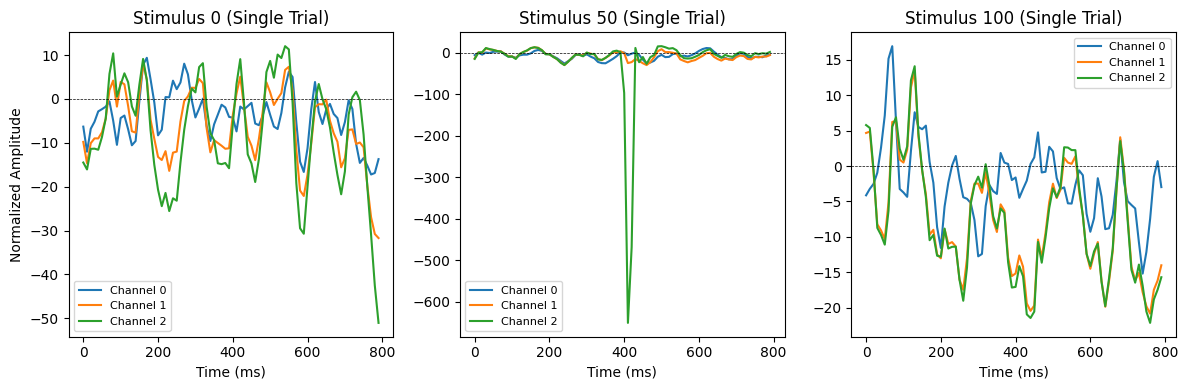

In [12]:

# ---------------------------------------------------------
# Plot 1: Example EEG time courses (Single Trials)
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))

# Let's pick 3 random images (stimuli) and look at the first 3 channels
stimuli_to_plot = [0, 50, 100] 
channels_to_plot = [0, 1, 2]

for i, stim_idx in enumerate(stimuli_to_plot):
    plt.subplot(1, 3, i+1)
    for chan_idx in channels_to_plot:
        # Plotting the raw voltage over time for a single image viewing
        plt.plot(time_ms, eeg_data[stim_idx, chan_idx, :], label=f'Channel {chan_idx}')
    
    plt.title(f'Stimulus {stim_idx} (Single Trial)')
    plt.xlabel('Time (ms)')
    if i == 0:
        plt.ylabel('Normalized Amplitude')
    plt.legend(fontsize=8)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

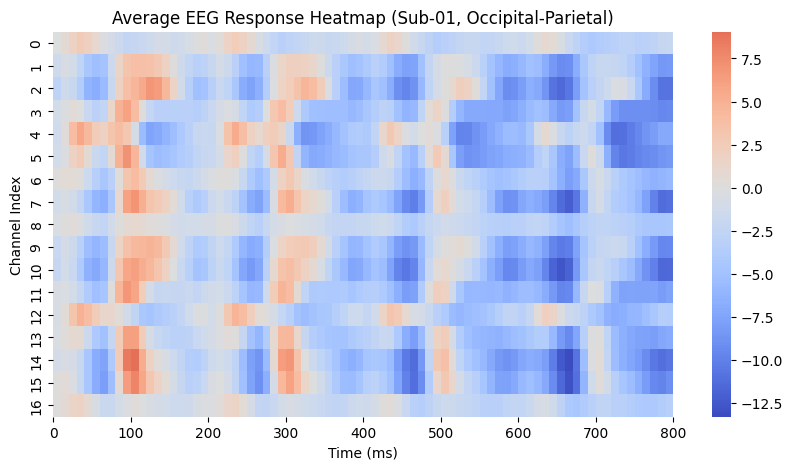

In [13]:
# ---------------------------------------------------------
# Plot 2: Heatmap over channels x time (Averaged Response)
# ---------------------------------------------------------
# Single trials are noisy. If we average across ALL 16,540 images, 
# we see the pure "visual evoked structure" of the brain.
mean_eeg_response = np.mean(eeg_data, axis=0) # Averages out Axis 0 (stimuli)

plt.figure(figsize=(10, 5))
sns.heatmap(mean_eeg_response, cmap='coolwarm', center=0, 
            xticklabels=np.arange(0, 800, 100), # Show labels every 100ms
            yticklabels=np.arange(0, 17))       # 17 channels

# Adjust x-ticks to match the 100ms labels (since we have 80 ticks total)
plt.xticks(np.arange(0, 81, 10), np.arange(0, 801, 100), rotation=0)

plt.title('Average EEG Response Heatmap (Sub-01, Occipital-Parietal)')
plt.xlabel('Time (ms)')
plt.ylabel('Channel Index')
plt.show()

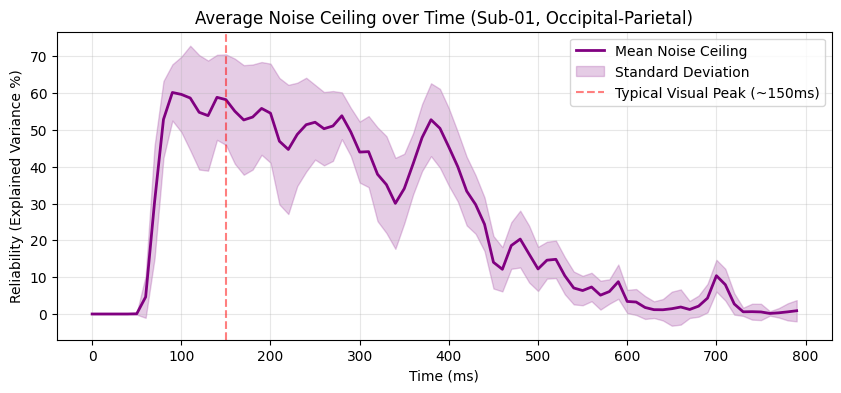

In [14]:
# ---------------------------------------------------------
# Plot 3: Summary of EEG Noise Ceilings
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))

# Plot the average noise ceiling across all 17 channels over time
mean_nc = np.mean(nc_data, axis=0)
std_nc = np.std(nc_data, axis=0)

plt.plot(time_ms, mean_nc, color='purple', linewidth=2, label='Mean Noise Ceiling')
plt.fill_between(time_ms, mean_nc - std_nc, mean_nc + std_nc, color='purple', alpha=0.2, label='Standard Deviation')

plt.title('Average Noise Ceiling over Time (Sub-01, Occipital-Parietal)')
plt.xlabel('Time (ms)')
plt.ylabel('Reliability (Explained Variance %)')
plt.axvline(150, color='red', linestyle='--', alpha=0.5, label='Typical Visual Peak (~150ms)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [15]:
import numpy as np


def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the method described in the NSD paper
    (Allen et al., 2021 / 2022 style variance-based estimator).

    Steps:
      1) z-score across stimuli (axis=1) for each (unit, rep) -> total var ≈ 1
      2) estimate noise variance across repetitions (axis=2), then average across stimuli
      3) signal variance = 1 - noise_var
      4) reliability (percent) for finite repeats:
             nc = 100 * (snr / (snr + 1 / n_reps))

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
    nan_policy : {'propagate', 'raise', 'omit'}, default='omit'
        Passed to the z-scoring logic when handling NaNs.

    Returns
    -------
    np.ndarray
        Per-unit noise ceilings in percent with shape (n_units,) or
        (n_channels, n_timepoints), depending on your implementation.
    """

    ### TODO
    pass


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit (voxel / channel / channel*timepoint).
    You can refer to van Bree et al. (2025) for mathematical details.
    
    Steps:
      1) For each fold, randomly split repetitions into two halves.
      2) Average responses within each half and compute Pearson correlation across stimuli.
      3) Optionally apply Spearman-Brown correction to each fold's correlation.
      4) Average across folds to get a final reliability estimate.

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
        The last axis corresponds to repetitions / trials.
    folds : int, default=10
        Number of random split-halves to sample.
    seed : int, default=0
        Base RNG seed; each fold may use seed + fold_idx.
    spearman_brown : bool, default=True
        Apply Spearman-Brown correction:
            r_sb = 2r / (1 + r)
    equalize_halves : bool, default=True
        If True, use equal-sized halves and drop one trial if n_reps is odd.
        If False, the second half may be larger by one trial.
    clip_folds : bool, default=False
        If True, clip reliability values after correction.

    Returns
    -------
    np.ndarray
        Array of shape (n_units) or (n_channels, n_timepoints).
    """
    ### TODO
    pass

In [16]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

In [17]:
import numpy as np
from scipy import stats

def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the variance-based estimator.
    """
    n_reps = responses.shape[-1]
    
    # Step 1: Z-score across stimuli (axis=-2 handles both 3D and 4D arrays smoothly)
    z_responses = stats.zscore(responses, axis=-2, nan_policy=nan_policy)
    
    # Step 2: Estimate noise variance across repetitions (axis=-1)
    # ddof=1 gives the unbiased sample variance
    noise_var_per_stim = np.nanvar(z_responses, axis=-1, ddof=1)
    
    # Average the noise variance across all stimuli (axis=-1 now, since reps collapsed)
    noise_var = np.nanmean(noise_var_per_stim, axis=-1)
    
    # Step 3: Signal variance = Total variance (which is ~1 due to z-scoring) - noise
    # We clip at 0 to prevent negative variances from math quirks
    signal_var = np.clip(1.0 - noise_var, 0.0, None)
    
    # Step 4: Calculate reliability (percent)
    # SNR = Signal Variance / Noise Variance
    # We add a tiny number (1e-10) to the denominator to prevent division by zero
    snr = signal_var / (noise_var + 1e-10)
    
    # Calculate Noise Ceiling percentage
    nc = 100.0 * (snr / (snr + (1.0 / n_reps)))
    
    return nc


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit using Pearson correlation.
    """
    n_reps = responses.shape[-1]
    
    # Determine the size of our halves
    half1_size = n_reps // 2
    half2_size = half1_size if equalize_halves else (n_reps - half1_size)
    
    fold_correlations = []
    
    for f in range(folds):
        rng = np.random.default_rng(seed + f)
        
        # 1. Shuffle the repetition indices
        rep_indices = np.arange(n_reps)
        rng.shuffle(rep_indices)
        
        # Split into two halves
        idx_half1 = rep_indices[:half1_size]
        idx_half2 = rep_indices[half1_size:half1_size + half2_size]
        
        # Pull the data for each half
        half1_data = responses[..., idx_half1]
        half2_data = responses[..., idx_half2]
        
        # 2. Average responses within each half
        mean1 = np.nanmean(half1_data, axis=-1)
        mean2 = np.nanmean(half2_data, axis=-1)
        
        # Compute Pearson correlation across stimuli (axis=-1 after averaging reps)
        # Using a fast vectorized Pearson r to avoid slow loops
        mean1_centered = mean1 - np.nanmean(mean1, axis=-1, keepdims=True)
        mean2_centered = mean2 - np.nanmean(mean2, axis=-1, keepdims=True)
        
        numerator = np.nansum(mean1_centered * mean2_centered, axis=-1)
        denominator = np.sqrt(np.nansum(mean1_centered**2, axis=-1) * np.nansum(mean2_centered**2, axis=-1))
        
        # Avoid division by zero
        r = numerator / (denominator + 1e-10)
        
        # 3. Apply Spearman-Brown correction
        if spearman_brown:
            # r_sb = 2r / (1 + r)
            r = (2.0 * r) / (1.0 + r + 1e-10)
            
        if clip_folds:
            r = np.clip(r, 0.0, 1.0)
            
        fold_correlations.append(r)
        
    # 4. Average across folds
    mean_reliability = np.nanmean(fold_correlations, axis=0)
    
    # Multiply by 100 to match the "Percent" scale of the variance-based method
    return mean_reliability * 100.0

Formatted data shape: (17, 80, 200, 80)
Computing Variance-Based Ceiling...
Computing Split-Half Ceiling...


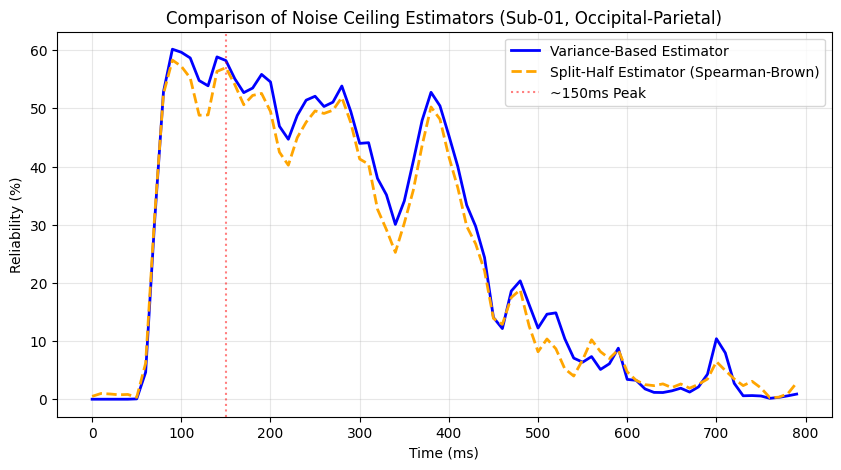

In [18]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the repeated EEG test responses
test_reps_path = "/shared/NX-414/data/things_eeg2-test_reps.h5"

with h5py.File(test_reps_path, 'r') as f:
    # Raw shape: (200 stimuli, 17 channels, 80 timepoints, 4 reps)
    raw_reps_data = f['test/neural_data/sub-01/occipital_parietal'][:]

# FIX: Rearrange the axes to match what the function expects
# Moves axis 0 (stimuli) to position -2 (right before reps)
# New shape: (17 channels, 80 timepoints, 200 stimuli, 4 reps)
formatted_reps_data = np.moveaxis(raw_reps_data, 0, -2)

print(f"Formatted data shape: {formatted_reps_data.shape}")

# 2. Compute both estimators (using the formatted data!)
print("Computing Variance-Based Ceiling...")
nc_var = compute_ceiling_variancebased(formatted_reps_data)

print("Computing Split-Half Ceiling...")
nc_split = compute_ceiling_splithalf(formatted_reps_data, folds=10, clip_folds=True)

# 3. Visualize and Compare
time_ms = np.linspace(0, 800, 80, endpoint=False)

# Average across all 17 channels (axis 0) to get a single line over time (axis 1)
# Since the output shape is now correctly (17, 80), taking mean on axis 0 gives (80,)
mean_nc_var = np.mean(nc_var, axis=0)
mean_nc_split = np.mean(nc_split, axis=0)

plt.figure(figsize=(10, 5))
plt.plot(time_ms, mean_nc_var, label='Variance-Based Estimator', color='blue', linewidth=2)
plt.plot(time_ms, mean_nc_split, label='Split-Half Estimator (Spearman-Brown)', color='orange', linewidth=2, linestyle='--')

plt.title('Comparison of Noise Ceiling Estimators (Sub-01, Occipital-Parietal)')
plt.xlabel('Time (ms)')
plt.ylabel('Reliability (%)')
plt.axvline(150, color='red', linestyle=':', alpha=0.5, label='~150ms Peak')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

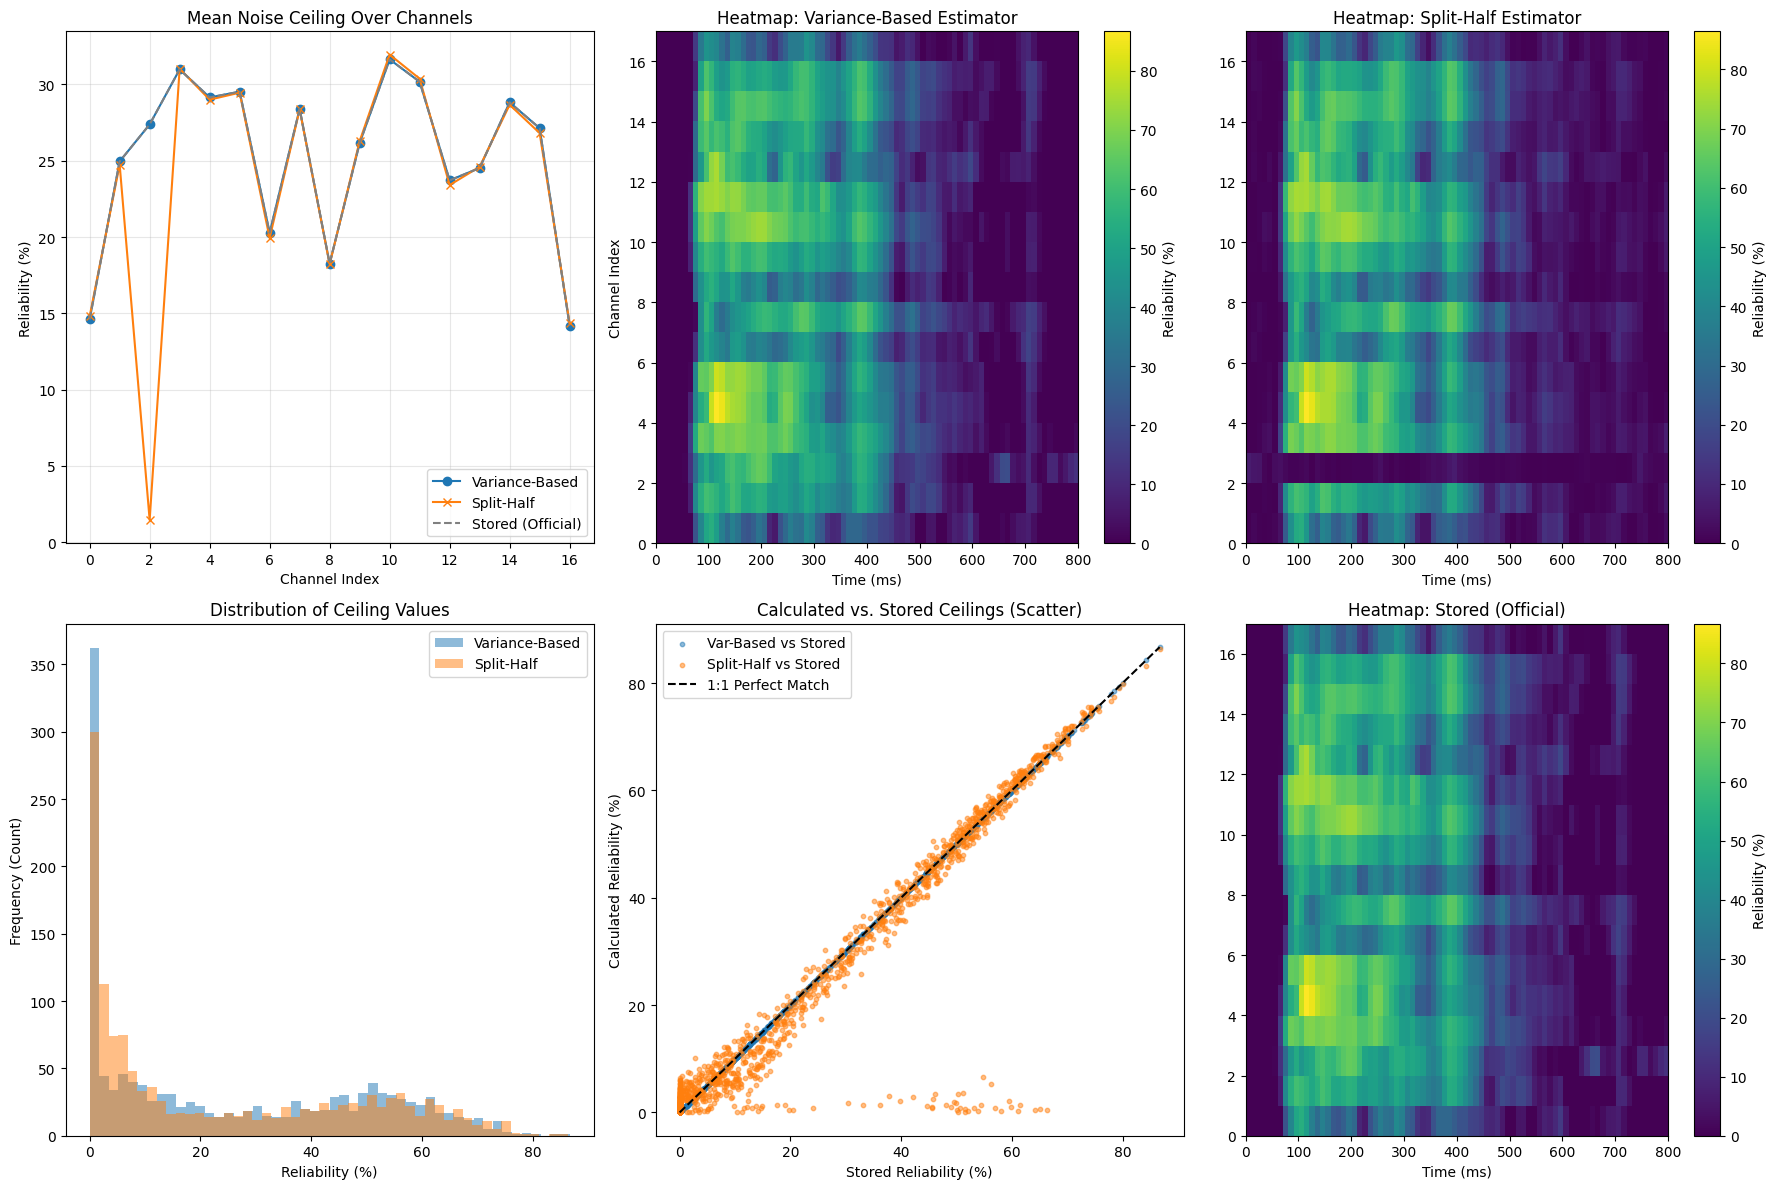

In [19]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the officially stored noise ceilings for comparison
# Note: We must load from the main dataset file, not the 'test_reps' file
main_eeg_path = "/shared/NX-414/data/things_eeg2.h5"
with h5py.File(main_eeg_path, 'r') as f:
    # Load ceilings for the exact same subject and ROI
    # Shape should naturally be (17 channels, 80 timepoints)
    stored_nc = f['noise_ceilings/sub-01/occipital_parietal'][:]

# Set up a large figure to hold all the missing visualizations
fig = plt.figure(figsize=(18, 12))

# ==========================================
# MISSING 1: Mean Noise Ceiling Over Channels
# ==========================================
# Average across time (axis 1) to get the mean for each channel
mean_nc_var_channels = np.mean(nc_var, axis=1)
mean_nc_split_channels = np.mean(nc_split, axis=1)
stored_nc_channels = np.mean(stored_nc, axis=1)

ax1 = fig.add_subplot(2, 3, 1)
channels = np.arange(nc_var.shape[0])
ax1.plot(channels, mean_nc_var_channels, label='Variance-Based', marker='o')
ax1.plot(channels, mean_nc_split_channels, label='Split-Half', marker='x')
ax1.plot(channels, stored_nc_channels, label='Stored (Official)', linestyle='--', color='gray')
ax1.set_title('Mean Noise Ceiling Over Channels')
ax1.set_xlabel('Channel Index')
ax1.set_ylabel('Reliability (%)')
ax1.legend()
ax1.grid(alpha=0.3)

# ==========================================
# MISSING 2: Channel x Time Heatmaps
# ==========================================
# Heatmap 1: Variance-Based
ax2 = fig.add_subplot(2, 3, 2)
im2 = ax2.imshow(nc_var, aspect='auto', origin='lower', extent=[0, 800, 0, nc_var.shape[0]], cmap='viridis')
ax2.set_title('Heatmap: Variance-Based Estimator')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Channel Index')
plt.colorbar(im2, ax=ax2, label='Reliability (%)')

# Heatmap 2: Split-Half
ax3 = fig.add_subplot(2, 3, 3)
im3 = ax3.imshow(nc_split, aspect='auto', origin='lower', extent=[0, 800, 0, nc_split.shape[0]], cmap='viridis')
ax3.set_title('Heatmap: Split-Half Estimator')
ax3.set_xlabel('Time (ms)')
plt.colorbar(im3, ax=ax3, label='Reliability (%)')

# ==========================================
# MISSING 3: Histogram of Value Distributions
# ==========================================
ax4 = fig.add_subplot(2, 3, 4)
# Flatten the arrays to 1D to plot the distribution of all individual channel-timepoint values
ax4.hist(nc_var.flatten(), bins=50, alpha=0.5, label='Variance-Based')
ax4.hist(nc_split.flatten(), bins=50, alpha=0.5, label='Split-Half')
ax4.set_title('Distribution of Ceiling Values')
ax4.set_xlabel('Reliability (%)')
ax4.set_ylabel('Frequency (Count)')
ax4.legend()

# ==========================================
# MISSING 4: Direct Visual Comparison to Stored
# ==========================================
# A scatter plot is the most rigorous way to compare them directly point-for-point
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(stored_nc.flatten(), nc_var.flatten(), alpha=0.5, label='Var-Based vs Stored', s=10)
ax5.scatter(stored_nc.flatten(), nc_split.flatten(), alpha=0.5, label='Split-Half vs Stored', s=10)

# Add a 1-to-1 diagonal reference line (if they match perfectly, points fall on this line)
max_val = max(np.max(stored_nc), np.max(nc_var), np.max(nc_split))
ax5.plot([0, max_val], [0, max_val], 'k--', label='1:1 Perfect Match')

ax5.set_title('Calculated vs. Stored Ceilings (Scatter)')
ax5.set_xlabel('Stored Reliability (%)')
ax5.set_ylabel('Calculated Reliability (%)')
ax5.legend()

# For good measure, let's also plot the Stored Heatmap to complete the visual comparison
ax6 = fig.add_subplot(2, 3, 6)
im6 = ax6.imshow(stored_nc, aspect='auto', origin='lower', extent=[0, 800, 0, stored_nc.shape[0]], cmap='viridis')
ax6.set_title('Heatmap: Stored (Official)')
ax6.set_xlabel('Time (ms)')
plt.colorbar(im6, ax=ax6, label='Reliability (%)')

plt.tight_layout()
plt.show()

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

In [20]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values

In [21]:
# ==========================================
# 1.4 Compare Noise Ceiling Estimators
# ==========================================
import h5py
import numpy as np
import pandas as pd
from scipy import stats

# 1. Load the stored noise ceilings (for Subject 01, Occipital-Parietal)
# We already loaded this in 1.2 as `nc_data`, but let's be explicit
with h5py.File(eeg_path, 'r') as f:
    # Shape: (17 channels, 80 timepoints). Already in % format (0-100)
    nc_stored = f['noise_ceilings/sub-01/occipital_parietal'][:]

# Flatten the arrays to make channel x time (17 * 80 = 1360) a single list for easy stats
stored_flat = nc_stored.flatten()
var_flat = nc_var.flatten()
split_flat = nc_split.flatten()

# 2. Compute Mean Absolute Error (MAE)
# How far off is our estimate from the stored value, on average?
errors_var = np.abs(stored_flat - var_flat)
errors_split = np.abs(stored_flat - split_flat)

mae_var = np.mean(errors_var)
mae_split = np.mean(errors_split)

# 3. Compute Pearson Correlation
# How well do our shapes track the stored shape?
r_var, _ = stats.pearsonr(stored_flat, var_flat)
r_split, _ = stats.pearsonr(stored_flat, split_flat)

# 4. Perform a Paired T-Test on the absolute errors
# Hypothesis: The errors from one estimator are significantly smaller than the other
t_stat, p_val = stats.ttest_rel(errors_var, errors_split)

# 5. Create the Quantitative Comparison Table
comparison_data = {
    "Estimator": ["Variance-Based", "Split-Half (Spearman-Brown)"],
    "Mean Absolute Error (MAE)": [f"{mae_var:.4f}%", f"{mae_split:.4f}%"],
    "Pearson Correlation (r)": [f"{r_var:.4f}", f"{r_split:.4f}"],
    "Matches Stored Exactly?": [np.allclose(stored_flat, var_flat, atol=1e-2), 
                                np.allclose(stored_flat, split_flat, atol=1e-2)]
}

df_comparison = pd.DataFrame(comparison_data)
print("=== Quantitative Comparison to Stored Ceilings ===")
display(df_comparison)

print("\n=== Statistical Test (Paired T-Test on Absolute Errors) ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
    print("Conclusion: There is a statistically significant difference in accuracy between the two estimators.")

=== Quantitative Comparison to Stored Ceilings ===


,Estimator,Mean Absolute Error (MAE),Pearson Correlation (r),Matches Stored Exactly?
0,Variance-Based,0.0000%,1.0000,True
1,Split-Half (Spearman-Brown),3.2230%,0.9357,False



=== Statistical Test (Paired T-Test on Absolute Errors) ===
T-statistic: -14.6921
P-value: 1.8289e-45
Conclusion: There is a statistically significant difference in accuracy between the two estimators.


---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

In [22]:
# TODO: load lh/rh ncsnr maps
# TODO: convert ncsnr to noise ceiling
# TODO: plot histogram
# TODO: visualize on fsaverage
# TODO: compute parcel-wise summary

In [23]:
!ls -la /shared/NX-414/data/
!find /shared/NX-414 -name "*.mgh"

total 57427633
drwxr-xr-x 2 root root           0 Apr 13 11:20 .
drwxr-xr-x 4 root root           0 Apr 13 11:06 ..
-rw-r--r-- 1 root root      655668 Apr 13 11:10 nsd-subj01-ncsnr-lh.mgh
-rw-r--r-- 1 root root      655668 Apr 13 11:06 nsd-subj01-ncsnr-rh.mgh
-rw-r--r-- 1 root root 29579632020 Apr 13 11:16 nsd_func1pt8mm_individualROIs.h5
-rw-r--r-- 1 root root 14131257144 Apr 13 11:20 things_eeg2-test_reps.h5
-rw-r--r-- 1 root root 14787672760 Apr 13 11:10 things_eeg2.h5
-rw-r--r-- 1 root root   306021728 Apr 13 11:20 tvsd.h5
/shared/NX-414/data/nsd-subj01-ncsnr-rh.mgh
/shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh


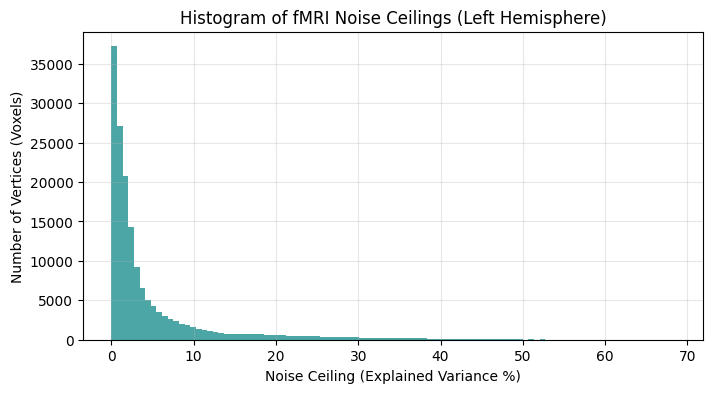

[fetch_surf_fsaverage] Dataset found in /home/nilearn_data/fsaverage
[fetch_atlas_surf_destrieux] Dataset found in /home/nilearn_data/destrieux_surface


/tmp/ipykernel_111/2493770715.py:34: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux_atlas = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_111/2493770715.py:34: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux_atlas = datasets.fetch_atlas_surf_destrieux()


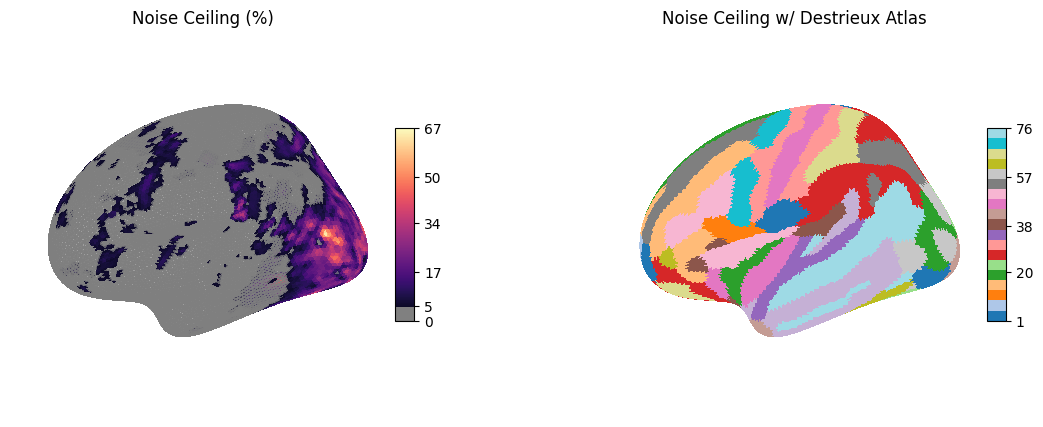

=== TOP 5 MOST RELIABLE REGIONS ===


,Region,Mean NC (%)
51,S_collat_transv_post,28.024649
42,Pole_occipital,26.309894
18,G_occipital_middle,26.021830
57,S_oc_middle_and_Lunatus,24.049961
59,S_occipital_ant,22.064624



=== TOP 5 LEAST RELIABLE REGIONS ===


,Region,Mean NC (%)
43,Pole_temporal,0.839063
31,G_subcallosal,0.763991
32,G_temp_sup-G_T_transv,0.632183
41,Medial_wall,0.515186
63,S_orbital_med-olfact,0.382371


In [24]:
# ==========================================
# 1.5 Convert NSD ncsnr & Visualize on Cortex
# ==========================================
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from nilearn import datasets, plotting, surface
from scipy.spatial import cKDTree

# 1. LOAD THE DATA
# Update this path to where your actual lh.ncsnr.mgh file is!
ncsnr_path = "/shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh"

# nibabel loads the .mgh file. .squeeze() flattens it into a 1D array of ~163,842 vertices
ncsnr_raw = nib.load(ncsnr_path).get_fdata().squeeze()

# 2. CONVERT TO NOISE CEILING (The Formula)
nc_highres = (ncsnr_raw**2 / (ncsnr_raw**2 + 1)) * 100

# 3. PLOT 1: HISTOGRAM
plt.figure(figsize=(8, 4))
plt.hist(nc_highres, bins=100, color='teal', alpha=0.7)
plt.title('Histogram of fMRI Noise Ceilings (Left Hemisphere)')
plt.xlabel('Noise Ceiling (Explained Variance %)')
plt.ylabel('Number of Vertices (Voxels)')
plt.grid(alpha=0.3)
plt.show()

# 4. FETCH ANATOMY & ATLAS (For Visualization)
# fsaverage is the high-res brain mesh. fsaverage5 is the low-res mesh.
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')
fsaverage5 = datasets.fetch_surf_fsaverage('fsaverage5')
destrieux_atlas = datasets.fetch_atlas_surf_destrieux()

# 5. DOWNSAMPLE THE DATA (High-res -> Low-res)
# We find the physical 3D coordinates of both meshes...
coords_hi, _ = surface.load_surf_mesh(fsaverage.pial_left)
coords_lo, _ = surface.load_surf_mesh(fsaverage5.pial_left)

# ...and use a KDTree to find the closest high-res point for every low-res point!
tree = cKDTree(coords_hi)
_, closest_indices = tree.query(coords_lo)

# Now we have our downsampled noise ceiling (length: 10242)
nc_lowres = nc_highres[closest_indices]

# 6. PLOT 2 & 3: CORTICAL SURFACE PLOTS
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(14, 5))

# Plot A: Just the Noise Ceiling
plotting.plot_surf_stat_map(
    fsaverage5.infl_left, stat_map=nc_lowres, hemi='left',
    title='Noise Ceiling (%)', colorbar=True,
    threshold=5.0, cmap='magma', axes=axes[0]
)

# Plot B: Noise Ceiling WITH the Atlas overlay
plotting.plot_surf_stat_map(
    fsaverage5.infl_left, stat_map=nc_lowres, hemi='left',
    title='Noise Ceiling w/ Destrieux Atlas', colorbar=False,
    threshold=5.0, cmap='magma', bg_map=fsaverage5.sulc_left, axes=axes[1]
)
plotting.plot_surf_roi(
    fsaverage5.infl_left, roi_map=destrieux_atlas['map_left'], 
    hemi='left', axes=axes[1], alpha=0.3, cmap='tab20'
)
plt.show()

# 7. COMPUTE PARCEL-WISE AVERAGES
labels = destrieux_atlas['labels']
atlas_map = destrieux_atlas['map_left']

region_scores = []
for region_id, region_name in enumerate(labels):
    # Skip the "Unknown" background region
    if region_id == 0: continue 
    
    # Find all vertices that belong to this specific region
    region_mask = (atlas_map == region_id)
    if np.any(region_mask):
        # Safely handle the string whether it is bytes or normal text
        clean_name = region_name.decode('utf-8') if hasattr(region_name, 'decode') else str(region_name)
        
        mean_nc = np.mean(nc_lowres[region_mask])
        region_scores.append({'Region': clean_name, 'Mean NC (%)': mean_nc})

# Create a clean table and sort it to find the highest and lowest
df_regions = pd.DataFrame(region_scores).sort_values(by='Mean NC (%)', ascending=False)

print("=== TOP 5 MOST RELIABLE REGIONS ===")
display(df_regions.head(5))

print("\n=== TOP 5 LEAST RELIABLE REGIONS ===")
display(df_regions.tail(5))

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [25]:
from typing import Literal
import numpy as np

class RepresentationalSimilarityAnalysis:
    """
    Representational Similarity Analysis (RSA).

    Given two representation matrices X and Y with the same number of conditions
    (rows), RSA:

    1. Computes a Representational Dissimilarity Matrix (RDM) for each:
       RDM_X[i, j] = dissimilarity(x_i, x_j)
       RDM_Y[i, j] = dissimilarity(y_i, y_j)

    2. Flattens the upper triangles of both RDMs and computes a correlation
       between them (Pearson or Spearman).
    """

    def __init__(
        self,
        dissimilarity: Literal["correlation", "euclidean", "cosine"] = "correlation",
        similarity_metric: Literal["pearson", "spearman"] = "spearman",
    ):
        self.dissimilarity = dissimilarity
        self.similarity_metric = similarity_metric

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.

        Parameters
        ----------
        X, Y : np.ndarray
            Arrays of shape (n_conditions, ...) that may need to be flattened
            along feature dimensions.

        Returns
        -------
        rsa_similarity : float
            Correlation between the vectorized upper triangles of the two RDMs.
        """
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        # Ensure both matrices have the same number of stimuli/conditions
        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"X and Y must have the same number of conditions (rows). "
                f"Got X: {X.shape[0]}, Y: {Y.shape[0]}"
            )
            
        # 1. Compute RDMs for both spaces
        rdm_x = self.compute_rdm(X)
        rdm_y = self.compute_rdm(Y)
        
        # 2. Compare the two RDMs
        return self.compare_rdms(rdm_x, rdm_y)

    def compute_rdm(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the Representational Dissimilarity Matrix (RDM)
        for a given representation matrix X.

        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, n_features).

        Returns
        -------
        rdm : np.ndarray
            Array of shape (n_conditions, n_conditions) with pairwise dissimilarities.
        """
        # Flatten any spatial/temporal dimensions, keeping n_conditions as the first axis
        X_flat = X.reshape(X.shape[0], -1)
        
        # pdist computes the pairwise distances; squareform converts it to a symmetric matrix
        condensed_distance = pdist(X_flat, metric=self.dissimilarity)
        rdm = squareform(condensed_distance)
        
        return rdm
    def compare_rdms(self, rdm1: np.ndarray, rdm2: np.ndarray) -> float:
        """
        Compare two RDMs by correlating their upper triangles.
        """
        # Extract indices for the upper triangle, excluding the diagonal (k=1)
        row_idx, col_idx = np.triu_indices(rdm1.shape[0], k=1)
        
        # Vectorize the upper triangles
        vec1 = rdm1[row_idx, col_idx]
        vec2 = rdm2[row_idx, col_idx]
        
        # Compute the specified correlation metric
        if self.similarity_metric == "spearman":
            correlation, _ = spearmanr(vec1, vec2)
        elif self.similarity_metric == "pearson":
            correlation, _ = pearsonr(vec1, vec2)
        else:
            raise ValueError(f"Unsupported similarity metric: {self.similarity_metric}")
            
        return float(correlation)

## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [26]:
import numpy as np

class CenteredKernelAlignment:
    """
    Unbiased linear CKA only.

    Parameters
    ----------
    eps : float
        Small constant for numerical stability.
    dtype : np.dtype
        Data type used for computations.
    """

    def __init__(
        self,
        eps: float = 1e-8,
        dtype: np.dtype = np.float64,
    ):
        self.eps = eps
        self.dtype = dtype  

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X).astype(self.dtype)
        Y = np.asarray(Y).astype(self.dtype)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"Batch sizes must match along axis 0: {X.shape[0]} vs {Y.shape[0]}"
            )

        # Flatten to (n_samples, n_features)
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(Y.shape[0], -1)

        return self._unbiased_linear_cka(X, Y)

    def _unbiased_linear_hsic(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased HSIC estimator for the linear kernel.

        X : [n, d_x]
        Y : [n, d_y]
        """
        n = X.shape[0]
        if n <= 3:
            raise ValueError("Unbiased HSIC requires at least 4 samples (n > 3).")

        # Form linear Gram matrices
        K = X @ X.T
        L = Y @ Y.T

        # Set diagonals to zero to remove the bias term
        np.fill_diagonal(K, 0)
        np.fill_diagonal(L, 0)

        # Calculate the three terms of the unbiased HSIC estimator
        # 1. Trace of product: tr(K L)
        term1 = np.sum(K * L) 
        
        # 2. Product of sums: (1^T K 1 * 1^T L 1) / ((n-1)*(n-2))
        term2 = (np.sum(K) * np.sum(L)) / ((n - 1) * (n - 2))
        
        # 3. Dot product of row sums: (1^T K L 1) / (n-2)
        term3 = 2 * np.dot(np.sum(K, axis=1), np.sum(L, axis=1)) / (n - 2)

        hsic = (term1 + term2 - term3) / (n * (n - 3))
        
        return hsic

    def _unbiased_linear_cka(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased linear CKA:

            CKA_unb(X, Y) =
                HSIC_unb(X, Y) / sqrt(HSIC_unb(X, X) * HSIC_unb(Y, Y))
        """
        hsic_xy = self._unbiased_linear_hsic(X, Y)
        hsic_xx = self._unbiased_linear_hsic(X, X)
        hsic_yy = self._unbiased_linear_hsic(Y, Y)

        # Bound the denominator components at 0 to avoid NaNs from floating point
        # inaccuracies in edge cases where HSIC(X,X) might be infinitesimally negative.
        denom = np.sqrt(max(hsic_xx * hsic_yy, 0.0)) + self.eps
        
        return hsic_xy / denom

## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [27]:
# TODO: implement RSA
# TODO: implement unbiased linear CKA
# TODO: compute scores across layers
# TODO: compare across models and ROIs / time windows

In [28]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, pearsonr
# ==========================================
# 1. EFFICIENT HDF5 LOADER (FIXED)
# ==========================================
def load_features_efficiently(file_path, layer_names, indices):
    """
    Loads specific rows from an HDF5 file efficiently by sorting indices first.
    """
    features_dict = {}
    
    # 1. Get the actual row numbers in strictly increasing order for h5py
    sorted_actual_indices = np.sort(indices)
    
    # 2. Get the ranks to put the data back into the original EEG order
    # (Applying argsort twice gives us the exact mapping to reverse the sort)
    reverse_idx = np.argsort(np.argsort(indices)) 
    
    with h5py.File(file_path, 'r') as f:
        for layer in layer_names:
            if layer not in f:
                print(f"Warning: Layer {layer} not found in {file_path}")
                continue
                
            # Read from disk using the strictly increasing array
            data = f[layer][sorted_actual_indices.tolist(), :]
            
            # Restore original order to match EEG stimuli exactly!
            features_dict[layer] = data[reverse_idx, :]
            
    return features_dict

In [29]:
# ==========================================
# 2. SETUP PATHS, LAYERS, & BULLETPROOF INDICES
# ==========================================
import os

# --- Define Paths ---
base_path = "/shared/NX-414/extracted_features/"
path_a = os.path.join(base_path, "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/things_stimuli.h5")
path_b = os.path.join(base_path, "Qwen3-VL-2B-Instruct/things_stimuli.h5")

# --- Define Layers ---
layers_a = [
    'features/layer1-0', 
    'features/layer2-0', 
    'features/layer3-0',   
    'features/layer3-10',  
    'features/layer3-20',  
    'features/layer3-30',  
    'features/layer4-1'    
]

layers_b = [
    'features/visual-blocks-2', 
    'features/visual-blocks-6', 
    'features/visual-blocks-14', 
    'features/visual-blocks-22',       
    'features/language_model-layers-3', 
    'features/language_model-layers-8',
    'features/language_model-layers-11',
    'features/language_model-layers-16' 
]

# --- Bulletproof Index Matching ---
eeg_main_path = "/shared/NX-414/data/things_eeg2.h5"

# 1. Pull the exact byte-string IDs from the EEG test set
with h5py.File(eeg_main_path, 'r') as f:
    eeg_test_ids = f['test/stimulus_ids'][:]

# 2. Pull the master list of 26,107 string IDs from the ResNet feature file
with h5py.File(path_a, 'r') as f:
    feature_master_ids = f['ids'][:]

# 3. Create a dictionary to instantly find the row index of any string ID
id_to_feat_idx = {id_: i for i, id_ in enumerate(feature_master_ids)}

# 4. Generate the exact indices for our 200 EEG test images
test_indices = np.array([id_to_feat_idx[x] for x in eeg_test_ids])

print(f"Successfully mapped {len(test_indices)} exact test stimuli!")
# ==========================================
# 2.5 ACTUALLY LOAD THE FEATURES
# ==========================================
print("Loading Model A (Adv-ResNet) features for our 200 test images...")
resnet_features = load_features_efficiently(path_a, layers_a, test_indices)

print("Loading Model B (Qwen3-VL) features for our 200 test images...")
qwen_features = load_features_efficiently(path_b, layers_b, test_indices)

Successfully mapped 200 exact test stimuli!
Loading Model A (Adv-ResNet) features for our 200 test images...
Loading Model B (Qwen3-VL) features for our 200 test images...


In [30]:

# ==========================================
# 3. BRAIN DATA PREP (Occipital-Parietal)
# ==========================================
eeg_path = "/shared/NX-414/data/things_eeg2-test_reps.h5"
with h5py.File(eeg_path, 'r') as f:
    # (200, 17, 80, 4) -> average across 4 repetitions
    eeg_raw = f['test/neural_data/sub-01/occipital_parietal'][:]
    eeg_avg = np.mean(eeg_raw, axis=-1) # Shape: (200, 17, 80)


In [31]:
# ==========================================
# 4. OPTIMIZED ALIGNMENT LOOP (SUPER FAST)
# ==========================================
print("Initializing metrics and pre-computing AI maps...")

# --- 0. INITIALIZE METRICS & STORAGE ---
cka_metric = CenteredKernelAlignment()
rsa_metric = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")

# We need these to actually store our math!
time_ms = np.linspace(0, 800, 80, endpoint=False)
res_cka_a = np.zeros((len(layers_a), 80))
res_rsa_a = np.zeros((len(layers_a), 80))
res_cka_b = np.zeros((len(layers_b), 80))
res_rsa_b = np.zeros((len(layers_b), 80))

# --- FAST CKA HELPERS ---
def fast_hsic(K, L):
    n = K.shape[0]
    term1 = np.sum(K * L) 
    term2 = (np.sum(K) * np.sum(L)) / ((n - 1) * (n - 2))
    term3 = 2 * np.dot(np.sum(K, axis=1), np.sum(L, axis=1)) / (n - 2)
    return (term1 + term2 - term3) / (n * (n - 3))

def fast_cka(K, L, hsic_K_K):
    hsic_K_L = fast_hsic(K, L)
    hsic_L_L = fast_hsic(L, L)
    denom = np.sqrt(max(hsic_K_K * hsic_L_L, 0.0)) + 1e-8
    return hsic_K_L / denom

def get_kernel(X):
    K = X.astype(np.float64) @ X.astype(np.float64).T
    np.fill_diagonal(K, 0)
    return K

# --- 1. PRE-COMPUTE AI MAPS ---
# RSA Maps
resnet_rdms = {l: rsa_metric.compute_rdm(resnet_features[l]) for l in layers_a}
qwen_rdms   = {l: rsa_metric.compute_rdm(qwen_features[l]) for l in layers_b}

# CKA Kernels and Self-HSIC 
resnet_kernels = {l: get_kernel(resnet_features[l]) for l in layers_a}
resnet_self_hsic = {l: fast_hsic(resnet_kernels[l], resnet_kernels[l]) for l in layers_a}

qwen_kernels = {l: get_kernel(qwen_features[l]) for l in layers_b}
qwen_self_hsic = {l: fast_hsic(qwen_kernels[l], qwen_kernels[l]) for l in layers_b}

# --- 2. RUN FAST LOOP ---
print("Crunching RSA/CKA across timepoints...")
for t in range(80):
    brain_t = eeg_avg[:, :, t]
    
    # Pre-compute Brain maps for this specific millisecond
    brain_rdm = rsa_metric.compute_rdm(brain_t)
    brain_kernel = get_kernel(brain_t)
    
    for i, layer in enumerate(layers_a):
        # Compare maps directly
        res_rsa_a[i, t] = rsa_metric.compare_rdms(resnet_rdms[layer], brain_rdm)
        res_cka_a[i, t] = fast_cka(resnet_kernels[layer], brain_kernel, resnet_self_hsic[layer])
        
    for i, layer in enumerate(layers_b):
        res_rsa_b[i, t] = rsa_metric.compare_rdms(qwen_rdms[layer], brain_rdm)
        res_cka_b[i, t] = fast_cka(qwen_kernels[layer], brain_kernel, qwen_self_hsic[layer])

print("Alignment Finished! You are ready to plot.")

Initializing metrics and pre-computing AI maps...
Crunching RSA/CKA across timepoints...
Alignment Finished! You are ready to plot.


In [32]:
# ==========================================
# 4.5 CROSS-MODEL COMPARISON
# ==========================================
print("Computing Cross-Model Alignment (Model A vs Model B)...")

cross_model_cka = np.zeros((len(layers_a), len(layers_b)))
cross_model_rsa = np.zeros((len(layers_a), len(layers_b)))

for i, l_a in enumerate(layers_a):
    for j, l_b in enumerate(layers_b):
        # Compare ResNet layer to Qwen layer
        cross_model_cka[i, j] = fast_cka(resnet_kernels[l_a], qwen_kernels[l_b], resnet_self_hsic[l_a])
        cross_model_rsa[i, j] = rsa_metric.compare_rdms(resnet_rdms[l_a], qwen_rdms[l_b])

print("Cross-Model Alignment Finished!")

Computing Cross-Model Alignment (Model A vs Model B)...
Cross-Model Alignment Finished!


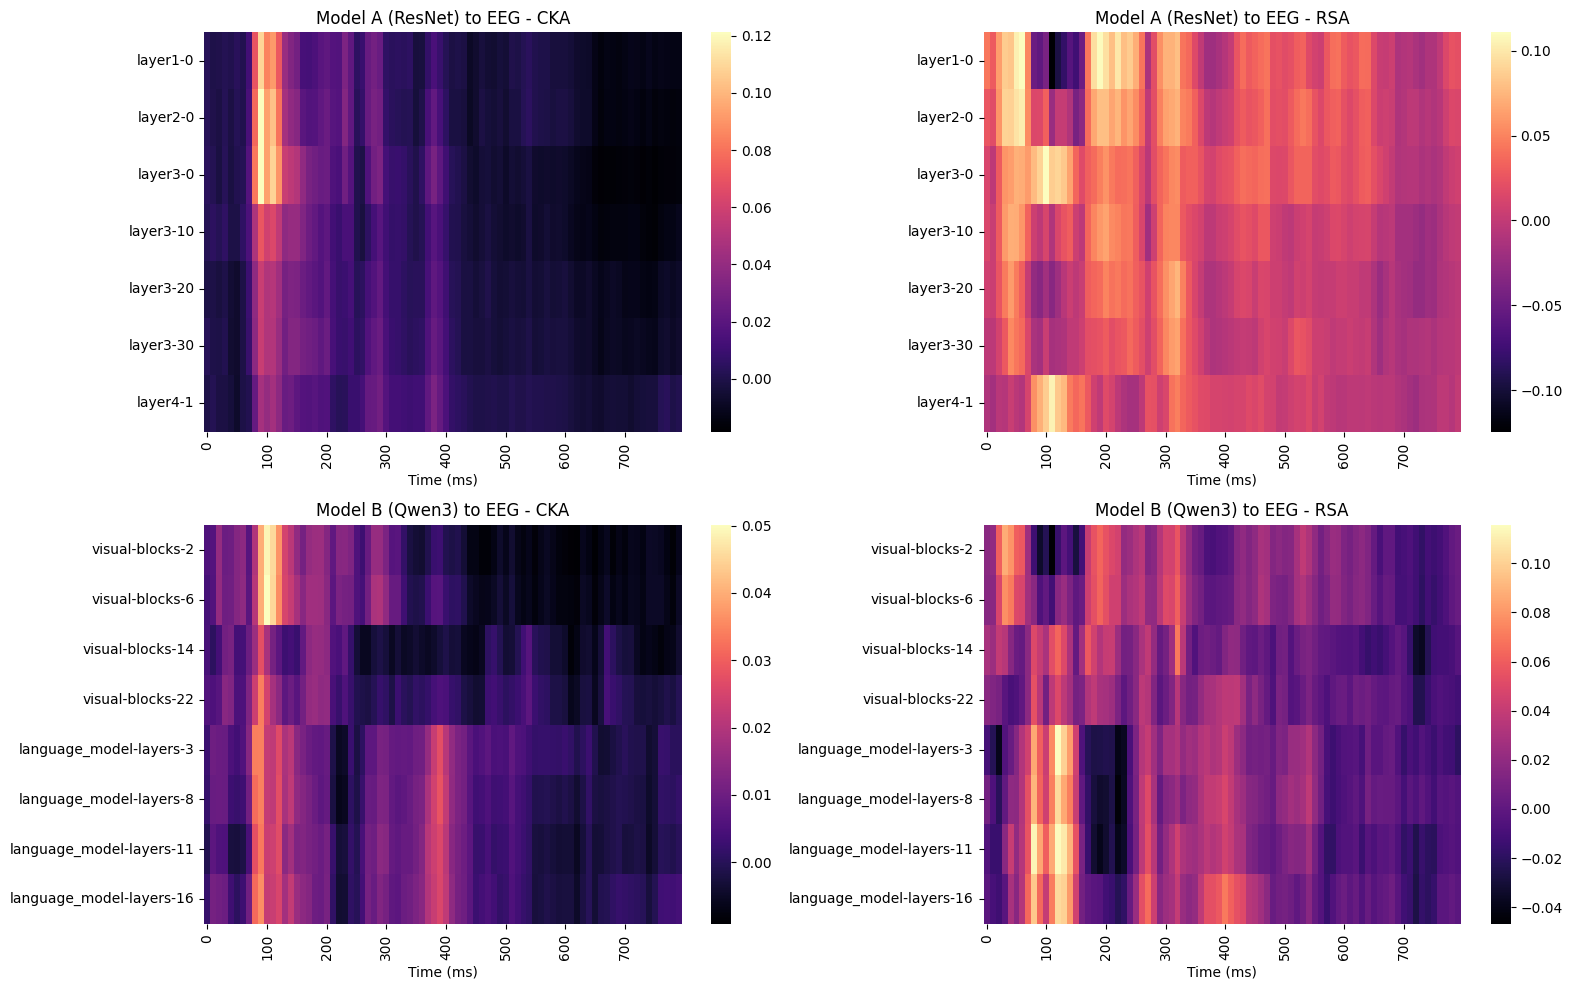

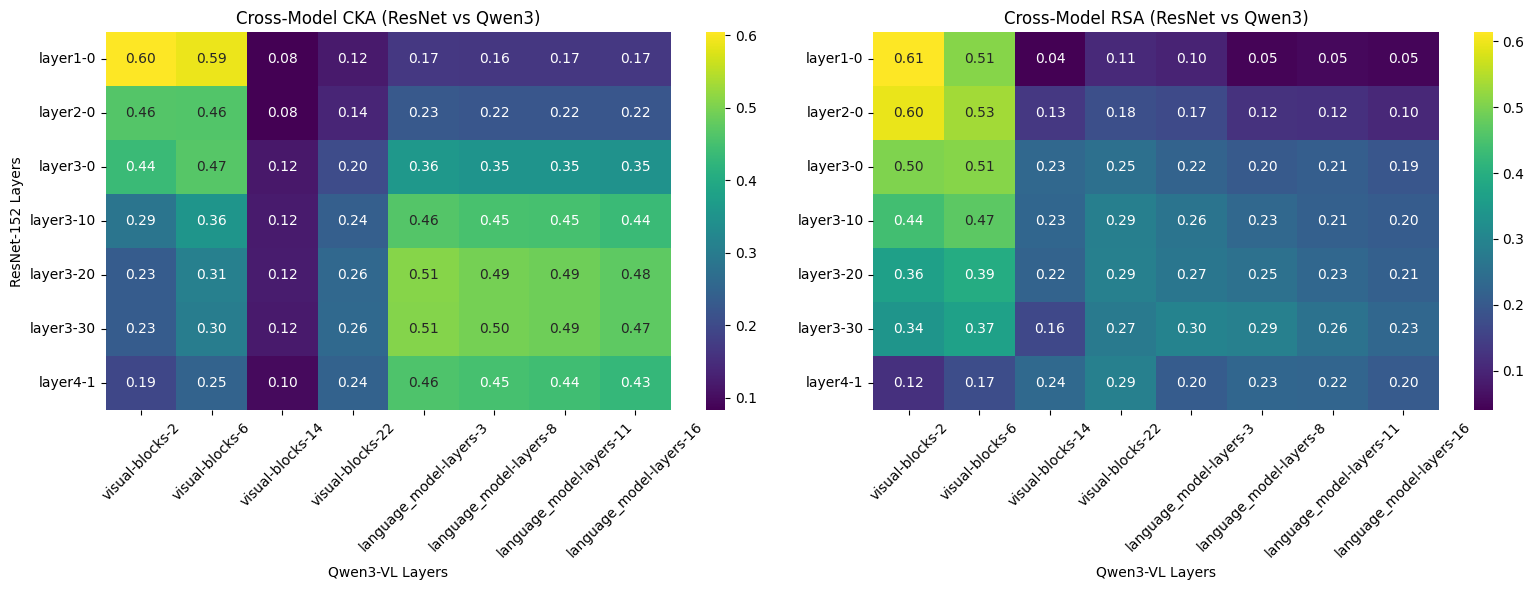

In [33]:
# ==========================================
# 5. VISUALIZATION
# ==========================================
# --- Plot 1: Brain vs Models (EEG Time-Resolved) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def plot_res(data, ax, title, y_labs):
    # Clean up the layer names for the plot labels
    clean_y_labs = [name.split('/')[-1] for name in y_labs]
    sns.heatmap(data, ax=ax, cmap='magma', yticklabels=clean_y_labs)
    ax.set_title(title)
    ax.set_xlabel("Time (ms)")
    
    # FIX: 8 ticks (0, 10, 20... 70) mapped to (0ms, 100ms... 700ms)
    # The +0.5 centers the tick mark directly in the middle of the heatmap cell
    ax.set_xticks(np.arange(0, 80, 10) + 0.5)
    ax.set_xticklabels(np.arange(0, 800, 100))

plot_res(res_cka_a, axes[0,0], "Model A (ResNet) to EEG - CKA", layers_a)
plot_res(res_rsa_a, axes[0,1], "Model A (ResNet) to EEG - RSA", layers_a)
plot_res(res_cka_b, axes[1,0], "Model B (Qwen3) to EEG - CKA", layers_b)
plot_res(res_rsa_b, axes[1,1], "Model B (Qwen3) to EEG - RSA", layers_b)

plt.tight_layout()
plt.show()


# --- Plot 2: Direct Model Comparison ---
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

clean_layers_a = [l.split('/')[-1] for l in layers_a]
clean_layers_b = [l.split('/')[-1] for l in layers_b]

# Plot CKA
sns.heatmap(cross_model_cka, ax=axes2[0], annot=True, fmt=".2f", cmap='viridis',
            xticklabels=clean_layers_b, yticklabels=clean_layers_a)
axes2[0].set_title("Cross-Model CKA (ResNet vs Qwen3)")
axes2[0].set_ylabel("ResNet-152 Layers")
axes2[0].set_xlabel("Qwen3-VL Layers")
axes2[0].tick_params(axis='x', rotation=45)

# Plot RSA
sns.heatmap(cross_model_rsa, ax=axes2[1], annot=True, fmt=".2f", cmap='viridis',
            xticklabels=clean_layers_b, yticklabels=clean_layers_a)
axes2[1].set_title("Cross-Model RSA (ResNet vs Qwen3)")
axes2[1].set_xlabel("Qwen3-VL Layers")
axes2[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---

## 2.4 Predictive alignment: linear encoding models

## Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

In [34]:
# TODO: define target ROIs / regions
# TODO: load corresponding neural data

In [35]:
# 1. Define the Targets as requested
roi_targets = {
    "TVSD": ["V1", "V4", "IT"],
    "EEG2": ["occipital_parietal"],
    "NSD": ["V1v", "V2v", "V3v", "hV4", "FFA-1", "VWFA-1", "PPA", "OPA", "EBA"]
}

def load_neural_targets(dataset_name, subject_id, roi):
    """Loads and prepares neural data splits."""
    paths = {
        "TVSD": os.path.join(DATA_DIR, "tvsd.h5"),
        "EEG2": os.path.join(DATA_DIR, "things_eeg2.h5"),
        "NSD": os.path.join(DATA_DIR, "nsd_func1pt8mm_individualROIs.h5")
    }
    
    with h5py.File(paths[dataset_name], 'r') as f:
        # Handling the structural differences in NSD naming
        if dataset_name == "NSD":
            y_train = f[f'train/neural_data/{subject_id}/{roi}'][:]
            y_test = f[f'test/neural_data/{subject_id}/{roi}'][:]
            # NSD noise ceilings are stored per-voxel
            ev_ceiling = f[f'performance/noise_ceiling/{subject_id}/{roi}'][:]
        elif dataset_name == "EEG2":
            y_train = f[f'train/neural_data/{subject_id}/{roi}'][:]
            y_test = f[f'test/neural_data/{subject_id}/{roi}'][:]
            # EEG noise ceilings are (channels, timepoints) - we'll flatten this later
            ev_ceiling = f[f'performance/noise_ceiling/{subject_id}/{roi}'][:]
            
            # EEG flattening: (stimuli, channels, time) -> (stimuli, features)
            y_train = y_train.reshape(y_train.shape[0], -1)
            y_test = y_test.reshape(y_test.shape[0], -1)
            ev_ceiling = ev_ceiling.flatten()
            
    return y_train, y_test, ev_ceiling

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

In [36]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

In [37]:
# # ==========================================
# # DEFINE TRAINING INDICES (The Missing Link)
# # ==========================================

# # 1. Load the EEG training stimulus IDs (16,540 IDs)
# with h5py.File(eeg_main_path, 'r') as f:
#     eeg_train_ids = f['train/stimulus_ids'][:]

# # 2. Use the dictionary we created in Section 2 to map IDs to feature rows
# # (Note: id_to_feat_idx must be defined from the feature file 'ids' dataset)
# train_feat_idx = np.array([id_to_feat_idx[x] for x in eeg_train_ids])

# print(f"Mapped {len(train_feat_idx)} training stimuli to feature rows.")

In [38]:
# from sklearn.linear_model import Ridge
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import KFold

# def fit_encoding_model(X_train, y_train, X_test, y_test, ev_ceiling):
#     """
#     Fits Ridge with internal Validation Split (Model Selection) 
#     and evaluates on Test Set.
#     """
#     # 1. Standardize Features
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     # 2. Model Selection (Validation Procedure)
#     # We use a simple 5-fold split on the TRAINING data only to find Alpha
#     alphas = [1e2, 1e3, 1e4, 1e5]
#     best_alpha = 1e3
#     best_val_r2 = -np.inf
    
#     kf = KFold(n_splits=5)
#     for a in alphas:
#         val_scores = []
#         for train_idx, val_idx in kf.split(X_train_scaled):
#             reg = Ridge(alpha=a, solver='lsqr')
#             reg.fit(X_train_scaled[train_idx], y_train[train_idx])
#             val_scores.append(reg.score(X_train_scaled[val_idx], y_train[val_idx]))
        
#         avg_val_r2 = np.mean(val_scores)
#         if avg_val_r2 > best_val_r2:
#             best_val_r2 = avg_val_r2
#             best_alpha = a

#     # 3. Final Fit & Prediction
#     final_model = Ridge(alpha=best_alpha, solver='lsqr')
#     final_model.fit(X_train_scaled, y_train)
#     y_pred = final_model.predict(X_test_scaled)
    
#     # 4. Compute Required Metrics
#     # Pearson r per target
#     rs = np.array([pearsonr(y_test[:, i], y_pred[:, i])[0] for i in range(y_test.shape[1])])
#     # Explained Variance per target
#     evs = np.array([explained_variance_score(y_test[:, i], y_pred[:, i]) for i in range(y_test.shape[1])])
    
#     # Noise Correction (using the provided formula)
#     # Ceiling is usually in %, convert to [0, 1]
#     norm_ceil = np.clip(ev_ceiling / 100.0, 1e-5, 1.0)
#     rs_nc = rs / np.sqrt(norm_ceil)
#     evs_nc = evs / norm_ceil
    
#     # 5. Hybrid Metrics (RSA/CKA on predicted vs actual)
#     # This uses your existing RSA/CKA classes
#     enc_rsa = rsa_metric.compare_rdms(rsa_metric.compute_rdm(y_pred), rsa_metric.compute_rdm(y_test))
#     enc_cka = cka_metric(y_pred, y_test)
    
#     return {
#         "r_nc": np.mean(rs_nc), 
#         "ev_nc": np.mean(evs_nc),
#         "enc_rsa": enc_rsa,
#         "enc_cka": enc_cka
#     }

In [39]:
# # ==========================================
# # LOAD NEURAL DATA (WITH KEY CHECK)
# # ==========================================

# with h5py.File(eeg_main_path, 'r') as f:
#     # 1. Load the data (These keys are usually standard)
#     y_train_eeg = f['train/neural_data/sub-01/occipital_parietal'][:]
#     y_test_raw = f['test/neural_data/sub-01/occipital_parietal'][:]
#     y_test_eeg = np.mean(y_test_raw, axis=-1)

#     # 2. Find the Noise Ceiling key
#     # Let's look for where the ceilings are actually stored
#     potential_keys = [
#         'performance/noise_ceiling/sub-01/occipital_parietal',
#         'noise_ceiling/sub-01/occipital_parietal',
#         'test/noise_ceiling/sub-01/occipital_parietal'
#     ]
    
#     ev_ceiling = None
#     for k in potential_keys:
#         if k in f:
#             print(f"✅ Found noise ceiling at: {k}")
#             ev_ceiling = f[k][:]
#             break
            
#     if ev_ceiling is None:
#         print("❌ Could not find stored ceiling. Using a 'dummy' ceiling of 1.0 (100%) for now.")
#         print("Note: This means your r_nc will equal your raw r.")
#         ev_ceiling = np.ones((y_test_eeg.shape[1], y_test_eeg.shape[2])) * 100

# # 3. FLATTEN
# y_train_eeg = y_train_eeg.reshape(y_train_eeg.shape[0], -1)
# y_test_eeg = y_test_eeg.reshape(y_test_eeg.shape[0], -1)
# ev_ceiling = ev_ceiling.flatten()

# print(f"Neural Data Prepared. Target dimension: {y_train_eeg.shape[1]}")

In [40]:
# # --- Storage for results ---
# results_data = []

# # --- Run for Model A (ResNet) on EEG ---
# print(f"Starting Encoding Analysis for {len(layers_a)} layers...")

# for layer in tqdm(layers_a):
#     # 1. Load Training Features (The 16.5k images)
#     # We use the train_feat_idx we defined earlier
#     X_train = load_features_efficiently(path_a, [layer], train_feat_idx)[layer]
    
#     # 2. Load Test Features (The 200 images)
#     X_test = load_features_efficiently(path_a, [layer], test_indices)[layer]
    
#     # 3. Fit the model using our pipeline
#     # y_train_eeg and y_test_eeg were loaded in the previous step
#     metrics = fit_encoding_model(X_train, y_train_eeg, X_test, y_test_eeg, ev_ceiling)
    
#     # 4. Save results with metadata
#     metrics['layer'] = layer.split('/')[-1]
#     metrics['model'] = 'ResNet-152'
#     results_data.append(metrics)

# # --- Convert to DataFrame for easy plotting ---
# df_results = pd.DataFrame(results_data)
# display(df_results)

In [41]:
import h5py

def print_hdf5_tree(name, obj):
    if isinstance(obj, h5py.Group):
        print(f"📁 Group:   {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"📄 Dataset: {name} | Shape: {obj.shape}")

print(f"Exploring file: {eeg_path}")
with h5py.File(eeg_path, 'r') as f:
    f.visititems(print_hdf5_tree)

Exploring file: /shared/NX-414/data/things_eeg2-test_reps.h5
📁 Group:   test
📁 Group:   test/neural_data
📁 Group:   test/neural_data/sub-01
📄 Dataset: test/neural_data/sub-01/central | Shape: (200, 14, 80, 80)
📄 Dataset: test/neural_data/sub-01/frontal | Shape: (200, 21, 80, 80)
📄 Dataset: test/neural_data/sub-01/occipital | Shape: (200, 3, 80, 80)
📄 Dataset: test/neural_data/sub-01/occipital_parietal | Shape: (200, 17, 80, 80)
📄 Dataset: test/neural_data/sub-01/parietal | Shape: (200, 14, 80, 80)
📄 Dataset: test/neural_data/sub-01/temporal | Shape: (200, 6, 80, 80)
📄 Dataset: test/neural_data/sub-01/whole_brain | Shape: (200, 63, 80, 80)
📁 Group:   test/neural_data/sub-02
📄 Dataset: test/neural_data/sub-02/central | Shape: (200, 14, 80, 80)
📄 Dataset: test/neural_data/sub-02/frontal | Shape: (200, 21, 80, 80)
📄 Dataset: test/neural_data/sub-02/occipital | Shape: (200, 3, 80, 80)
📄 Dataset: test/neural_data/sub-02/occipital_parietal | Shape: (200, 17, 80, 80)
📄 Dataset: test/neural_dat

TVSD  — 6 targets | train=22248, test=100
EEG2  — sub-01/occipital_parietal | train=(16540, 1360), test=(200, 1360)
NSD   — 9 ROIs | train=9000, test=1000
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
⏳ INTERMEDIATE MODE — N=2500, all targets, all layers (~10 mins)
Total jobs to run: 320  (datasets × models × layers × targets)


  Dataset : TVSD
  Targets : ['monkeyF/IT', 'monkeyF/V1', 'monkeyF/V4', 'monkeyN/IT', 'monkeyN/V1', 'monkeyN/V4']

  ▶ Model A (ResNet)  (10 layers)
        α=1.0e+05  val_r=0.2565 ◀ best so far  (2.2s)
        α=1.0e+05  val_r=0.4442 ◀ best so far  (2.6s)
        α=1.0e+05  val_r=0.3671 ◀ best so far  (2.2s)
        α=1.0e+05  val_r=0.3170 ◀ best so far  (2.3s)
        α=1.0e+05  val_r=0.5793 ◀ best so far  (2.5s)
        α=1.0e+05  val_r=0.3674 ◀ best so far  (2.2s)
    [ 1/10] layer1-0                     IT  r=0.391  r_nc=0.405  α=1e+05  fit=10.3s | V1  r=0.704  r_nc=0.725  α=1e+05  fit=10.9s | V4  r=0.502  r_nc=0.512  α=1e

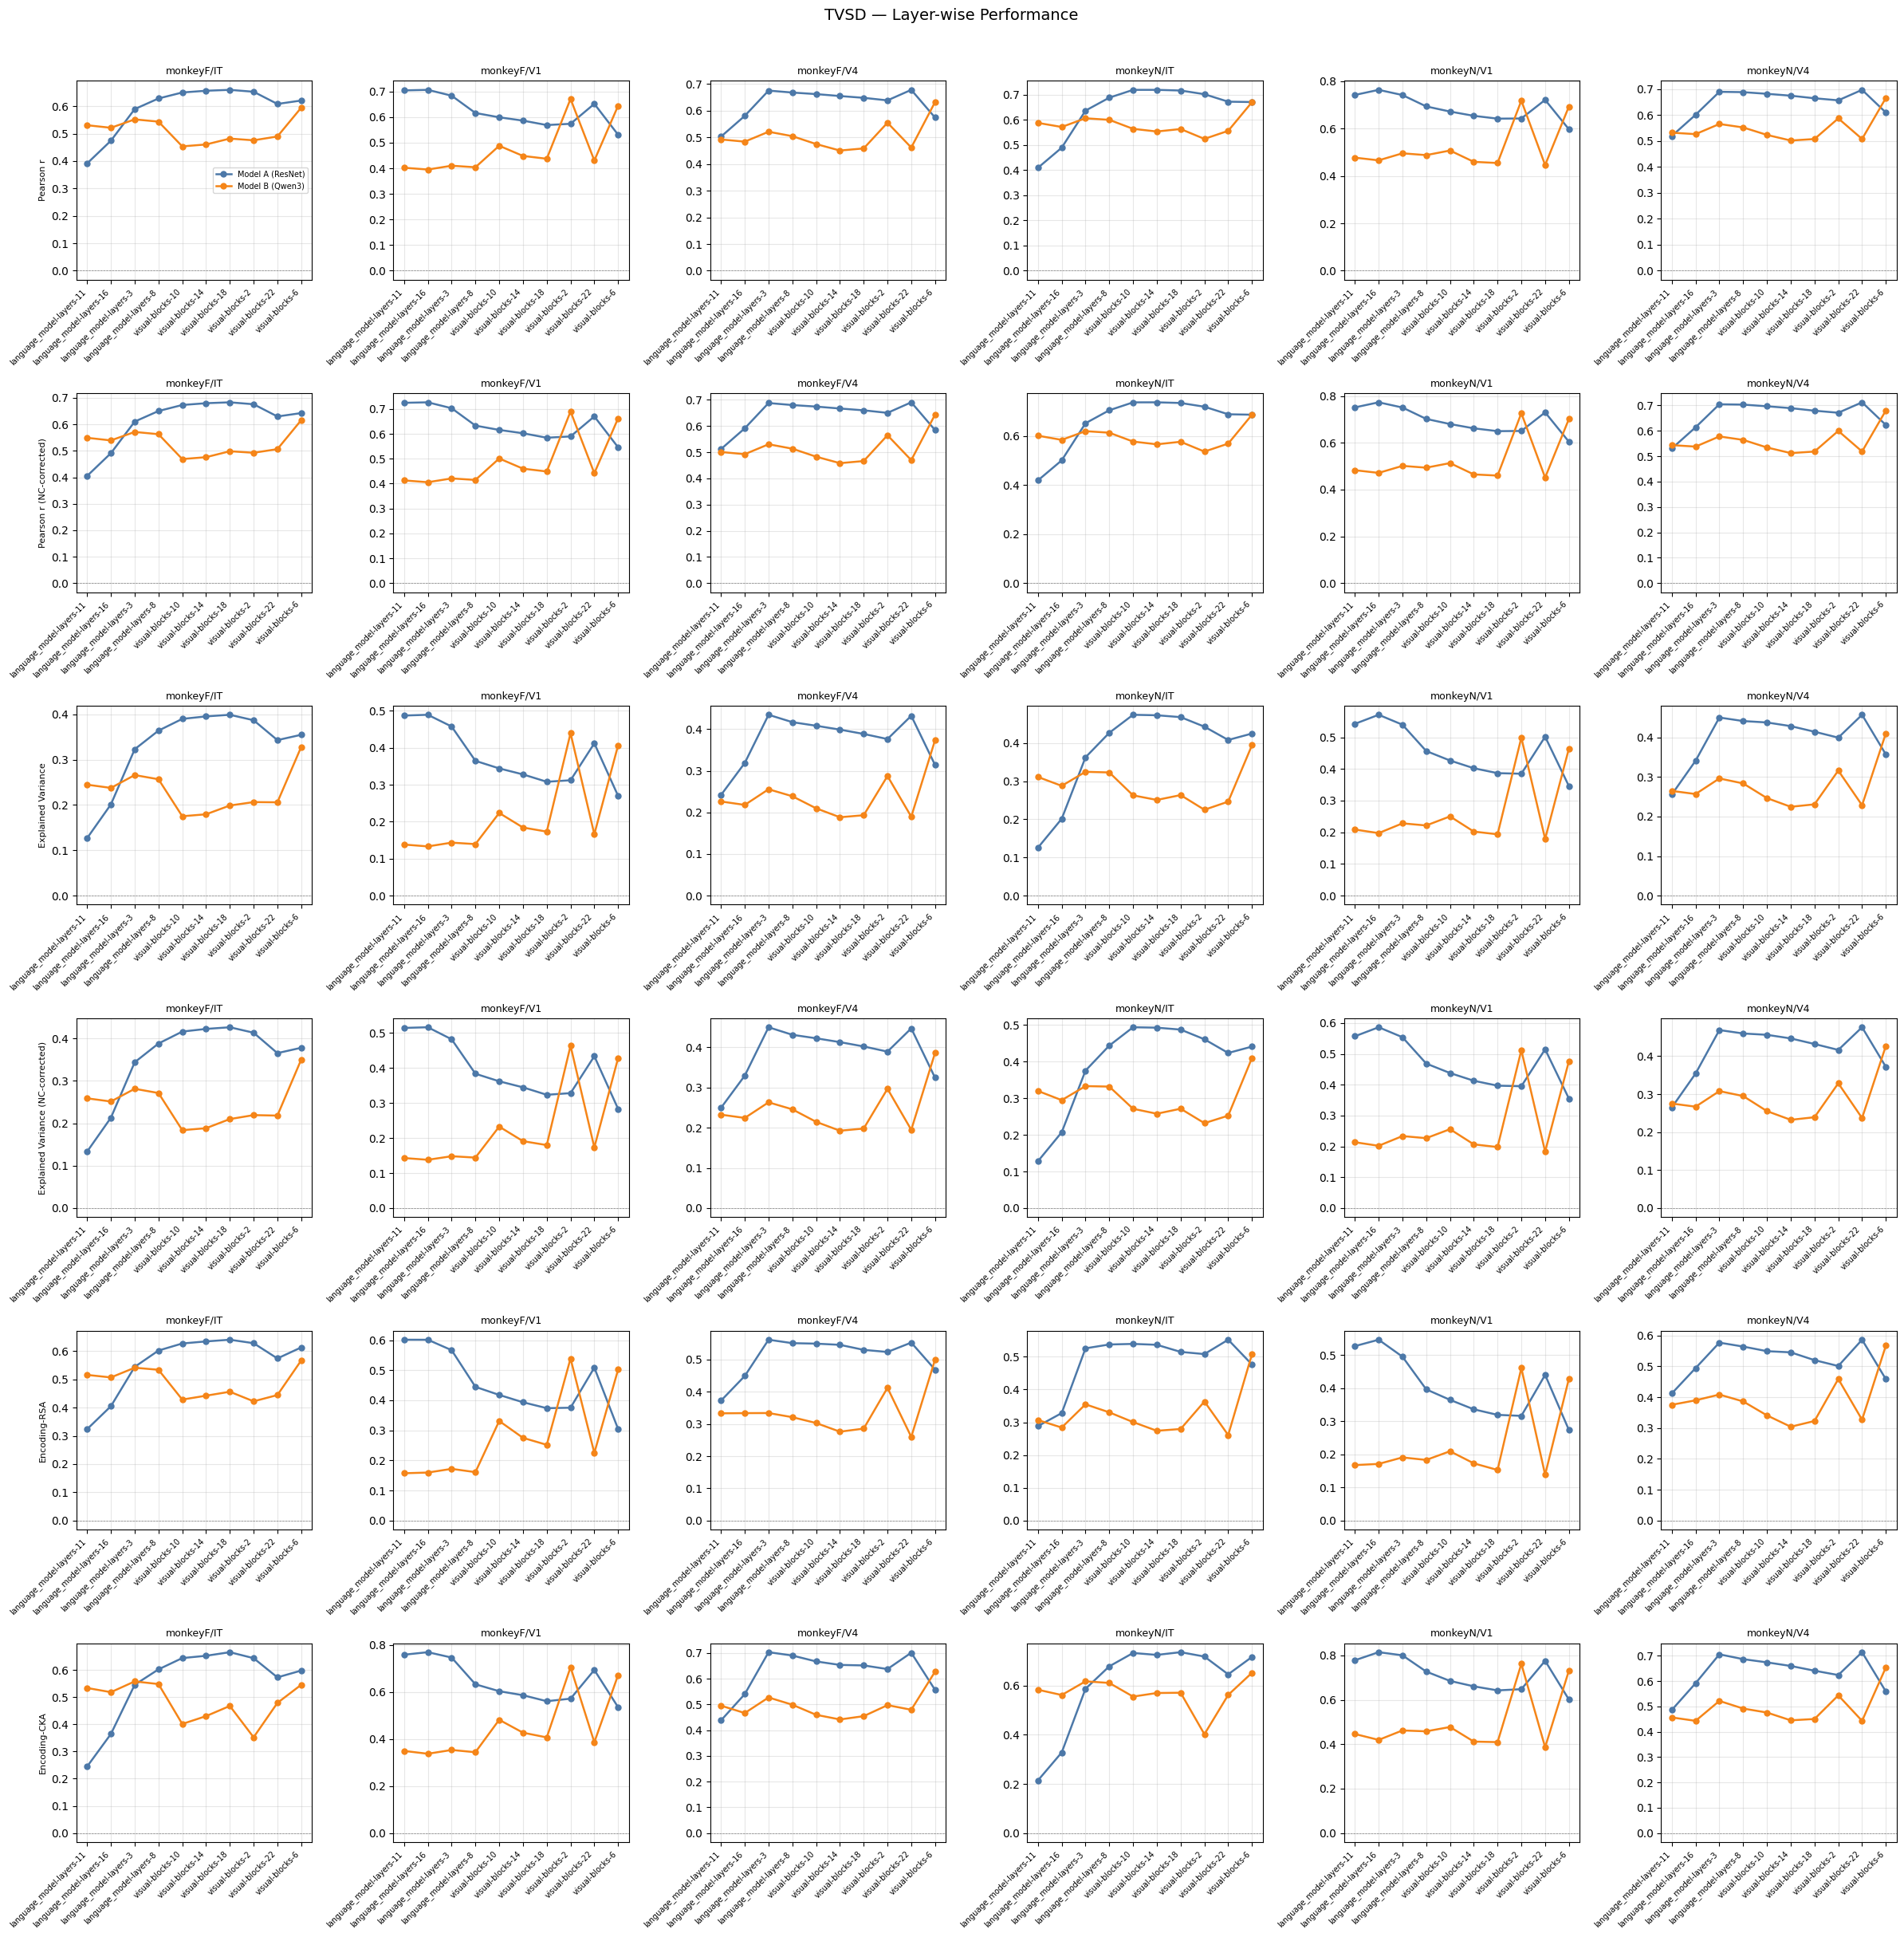

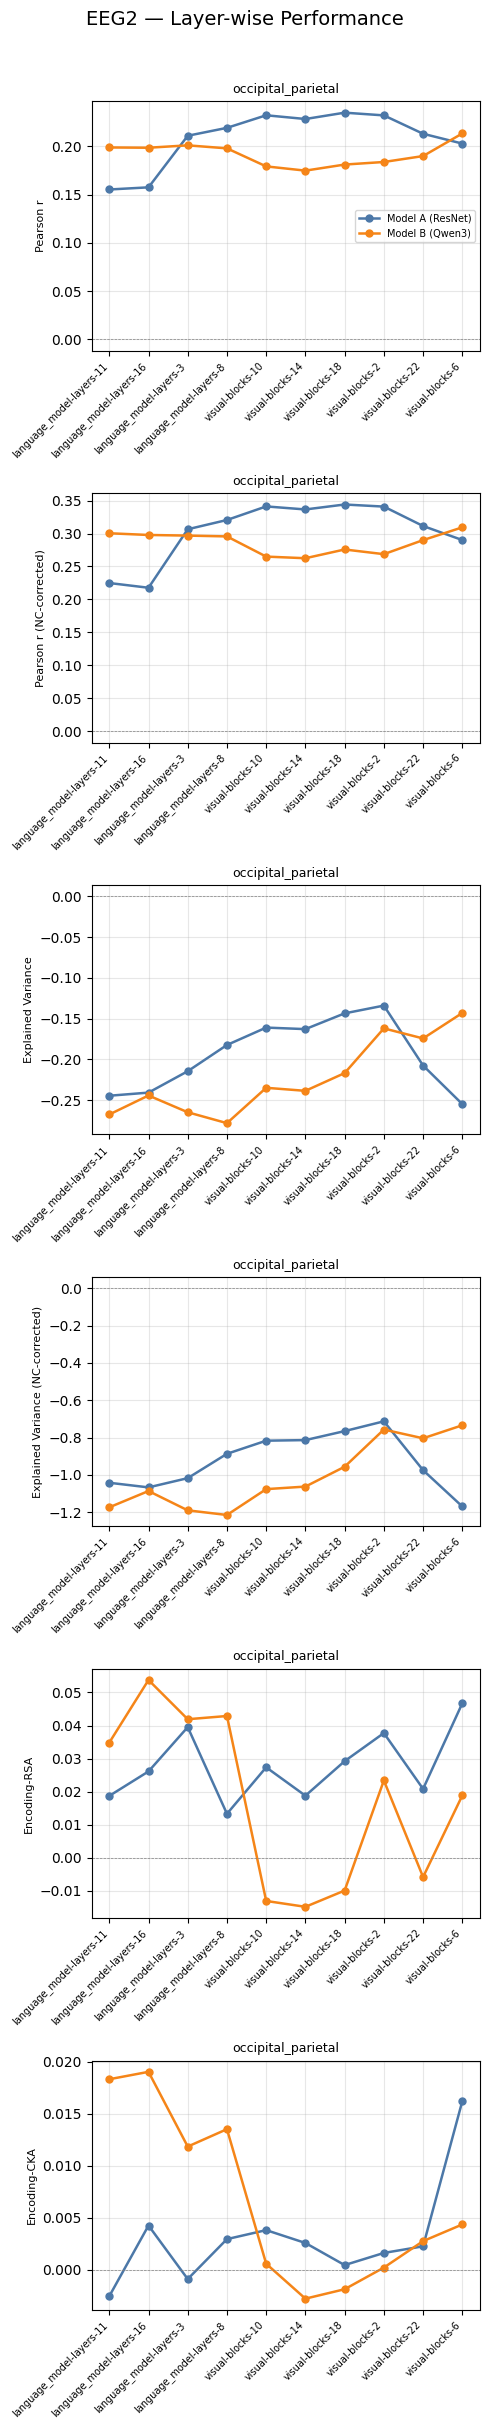

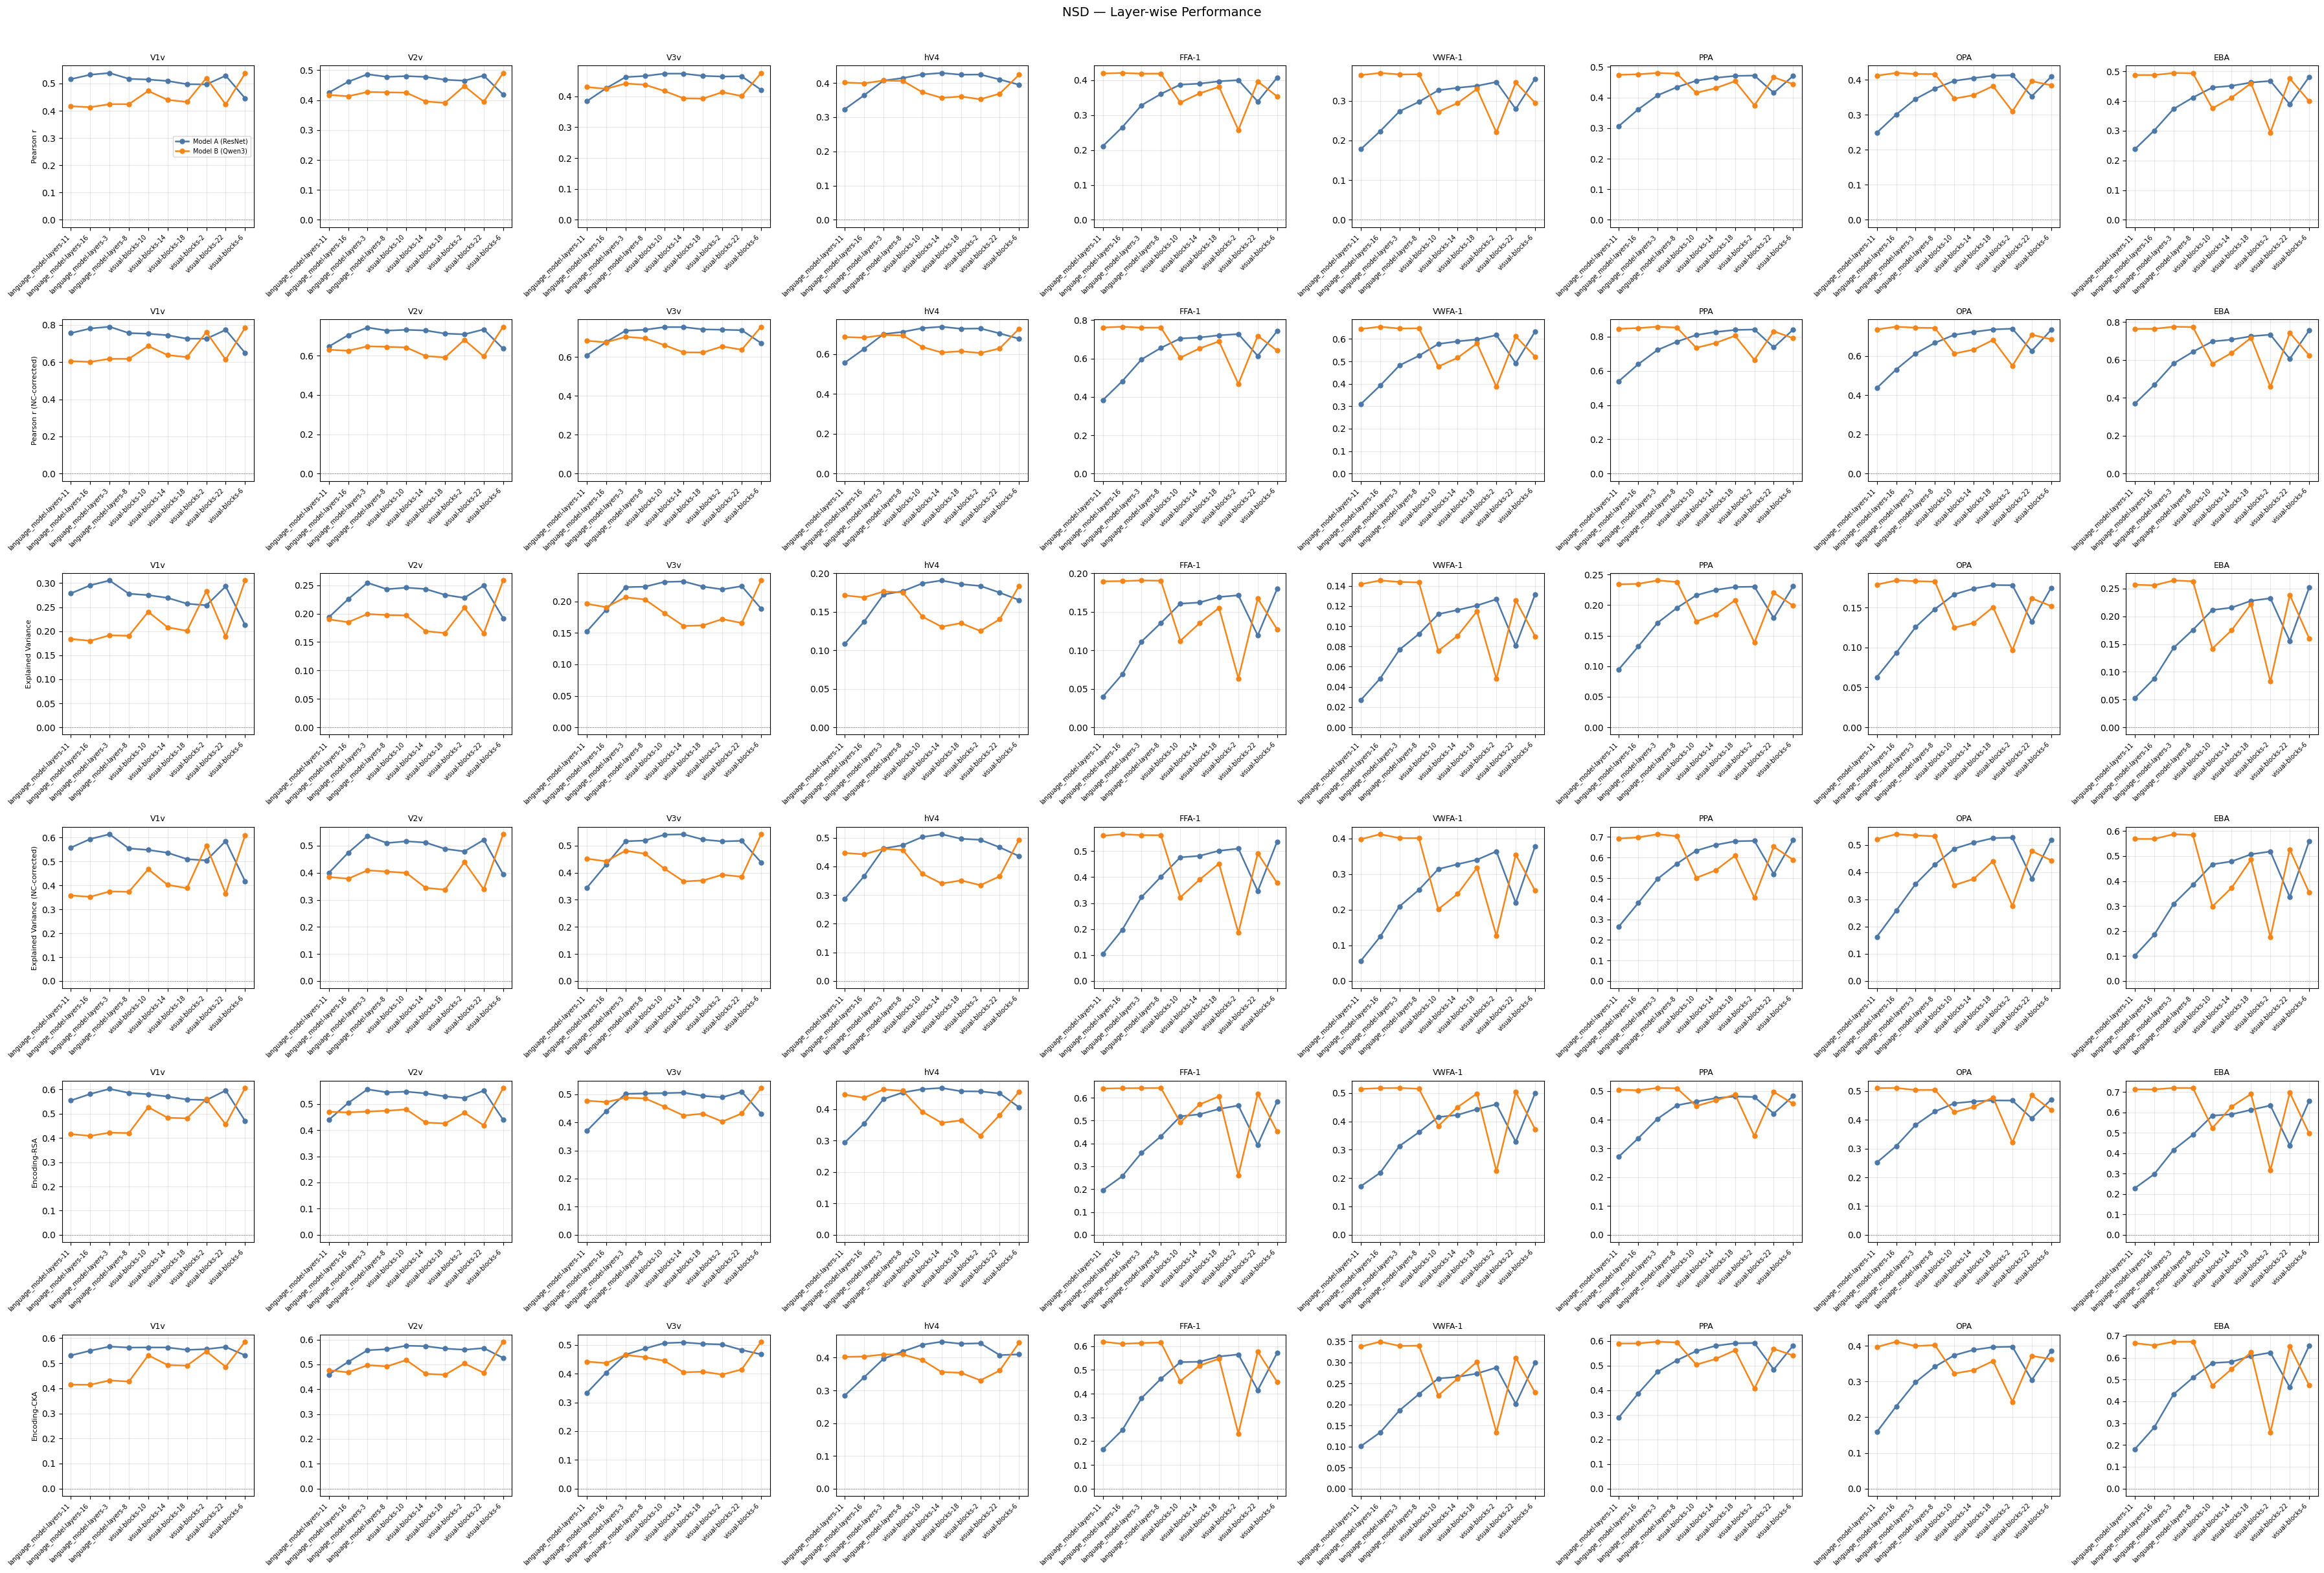

=== Best-Layer Summary Table ===


,Dataset,Model,Target,Best Layer,r,r_nc,EV,EV_nc,Enc-RSA,Enc-CKA
0,EEG2,Model A (ResNet),occipital_parietal,layer3-25,0.235,0.344,-0.144,-0.766,0.029,0.000
1,EEG2,Model B (Qwen3),occipital_parietal,visual-blocks-6,0.213,0.309,-0.143,-0.734,0.019,0.004
2,NSD,Model A (ResNet),EBA,layer4-1,0.482,0.756,0.252,0.560,0.657,0.655
11,NSD,Model B (Qwen3),EBA,language_model-layers-3,0.495,0.775,0.265,0.587,0.720,0.673
3,NSD,Model A (ResNet),FFA-1,layer4-1,0.407,0.743,0.180,0.536,0.584,0.572
12,NSD,Model B (Qwen3),FFA-1,language_model-layers-16,0.420,0.766,0.190,0.565,0.642,0.610
4,NSD,Model A (ResNet),OPA,layer3-30,0.413,0.740,0.178,0.527,0.467,0.398
13,NSD,Model B (Qwen3),OPA,language_model-layers-16,0.420,0.750,0.184,0.540,0.511,0.412
5,NSD,Model A (ResNet),PPA,layer3-30,0.472,0.841,0.230,0.681,0.479,0.591
14,NSD,Model B (Qwen3),PPA,language_model-layers-3,0.480,0.857,0.240,0.713,0.510,0.597


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),Enc-RSA | Model A (ResNet),Enc-RSA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,EEG2,occipital_parietal,-0.766,-0.734,0.000,0.004,0.029,0.019,0.344,0.309
1,NSD,EBA,0.560,0.587,0.655,0.673,0.657,0.720,0.756,0.775
2,NSD,FFA-1,0.536,0.565,0.572,0.610,0.584,0.642,0.743,0.766
3,NSD,OPA,0.527,0.540,0.398,0.412,0.467,0.511,0.740,0.750
4,NSD,PPA,0.681,0.713,0.591,0.597,0.479,0.510,0.841,0.857
5,NSD,V1v,0.614,0.609,0.567,0.586,0.603,0.607,0.791,0.786
6,NSD,V2v,0.536,0.542,0.557,0.591,0.556,0.561,0.743,0.747
7,NSD,V3v,0.541,0.542,0.509,0.511,0.506,0.522,0.755,0.756
8,NSD,VWFA-1,0.378,0.412,0.299,0.349,0.499,0.517,0.633,0.654
9,NSD,hV4,0.512,0.493,0.449,0.446,0.468,0.456,0.737,0.728


KeyError: 'dataset'

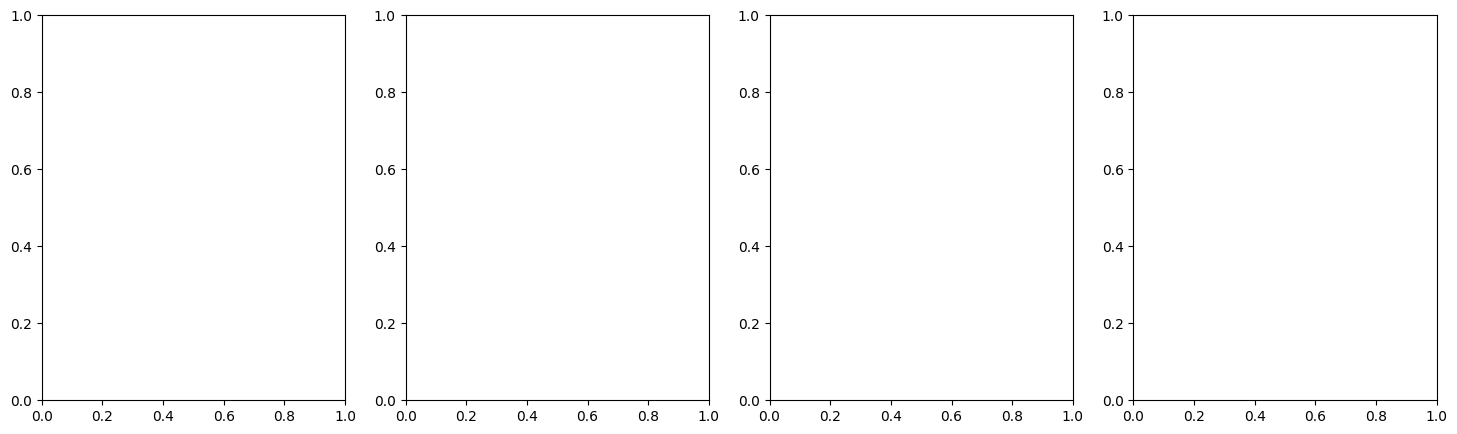

In [48]:
# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
# ============================================================
# Paste each block below into a new notebook cell in order.
# All code assumes the utilities (RSA, CKA, paths) from earlier
# sections are already defined in the kernel.
# ============================================================


# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

NSD_ROIS = ["V1v", "V2v", "V3v", "hV4", "FFA-1", "VWFA-1", "PPA", "OPA", "EBA"]
EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
NSD_SUB = "subj01"

# ── Discover all feature layers (datasets only, skip 'ids') ──
def list_h5_layers(path: str) -> list[str]:
    """Return every Dataset key (leaf node) except 'ids'."""
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

# ── Memory-efficient indexed HDF5 read ──
def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    """
    Read only the rows at `indices` from an HDF5 dataset.
    Sorts indices for efficient sequential disk access, then restores order.
    """
    sort_order   = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

# ── Map stimulus IDs -> feature row indices ──
def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load all neural train/test data
# ─────────────────────────────────────────────────────────────

# ── TVSD ──
tvsd_neural, tvsd_nc, tvsd_ids = {}, {}, {}
with h5py.File(os.path.join(DATA_DIR, "tvsd.h5"), "r") as f:
    tvsd_ids["train"] = f["train/stimulus_ids"][:]
    tvsd_ids["test"]  = f["test/stimulus_ids"][:]
    for monkey in f["train/neural_data"].keys():
        for roi in f[f"train/neural_data/{monkey}"].keys():
            key = f"{monkey}/{roi}"
            tvsd_neural[key] = {
                "train": f[f"train/neural_data/{monkey}/{roi}"][:],
                "test":  f[f"test/neural_data/{monkey}/{roi}"][:]
            }
            tvsd_nc[key] = f[f"noise_ceilings/{monkey}/{roi}"][:]  # shape (n_units,)

print(f"TVSD  — {len(tvsd_neural)} targets | "
      f"train={tvsd_ids['train'].shape[0]}, test={tvsd_ids['test'].shape[0]}")

# ── EEG2 (subject 01, occipital_parietal) ──
eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

n_ch, n_tp = raw_train.shape[1], raw_train.shape[2]
# Flatten (stimuli, C, T) -> (stimuli, C*T) as stated in Section 0.8
eeg_neural["train"] = raw_train.reshape(raw_train.shape[0], -1)
eeg_neural["test"]  = raw_test.reshape(raw_test.shape[0], -1)
eeg_nc_flat         = nc_2d.flatten()                           # (C*T,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")

# ── NSD (subject 01, required ROIs) ──
nsd_ids = {}
nsd_neural, nsd_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "nsd_func1pt8mm_individualROIs.h5"), "r") as f:
    nsd_ids["train"] = f[f"train/stimulus_ids/{NSD_SUB}"][:]
    nsd_ids["test"]  = f[f"test/stimulus_ids/{NSD_SUB}"][:]
    for roi in NSD_ROIS:
        train_key = f"train/neural_data/{NSD_SUB}/{roi}"
        test_key  = f"test/neural_data/{NSD_SUB}/{roi}"
        nc_key    = f"noise_ceilings/{NSD_SUB}/{roi}"
        if train_key in f:
            nsd_neural[roi] = {
                "train": f[train_key][:],
                "test":  f[test_key][:]
            }
            nsd_nc[roi] = f[nc_key][:]
        else:
            print(f"  ⚠ NSD ROI '{roi}' not found, skipping.")

print(f"NSD   — {len(nsd_neural)} ROIs | "
      f"train={nsd_ids['train'].shape[0]}, test={nsd_ids['test'].shape[0]}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")
path_a_nsd    = os.path.join(FEAT_DIR, MODEL_A, "nsd_stimuli.h5")
path_b_nsd    = os.path.join(FEAT_DIR, MODEL_B, "nsd_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

# Pre-compute stimulus → feature-row index maps
feat_idx_tvsd_train  = get_feat_indices(path_a_things, tvsd_ids["train"])
feat_idx_tvsd_test   = get_feat_indices(path_a_things, tvsd_ids["test"])
feat_idx_eeg_train   = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test    = get_feat_indices(path_a_things, eeg_ids["test"])
feat_idx_nsd_train   = get_feat_indices(path_a_nsd,    nsd_ids["train"])
feat_idx_nsd_test    = get_feat_indices(path_a_nsd,    nsd_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    """Pearson r per output unit. Returns shape (n_units,)."""
    n = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den


def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    """Explained variance per output unit. Returns shape (n_units,)."""
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot


def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    """
    Noise-ceiling-corrected Pearson r.
    nc_ev is the EV ceiling in [0,1].  r_nc = r / sqrt(nc_ev).
    """
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r


def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    """Noise-ceiling-corrected explained variance.  ev_nc = ev / nc_ev."""
    return ev / np.clip(nc_ev, 1e-6, None)


def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    """
    Average predictive metrics across units, applying the EEG reliability
    filter (nc < 0.1) where relevant to avoid instability.
    For EEG targets the nc_flat values are in [0,100], so threshold = 10%.
    For non-EEG targets nc_flat is also in [0,100].
    """
    mask = nc_flat > 10.0   # 10 % explained variance ≈ reliability > 0.1
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":             _m(r),
        "pearsonr_nc":          _m(r_nc),
        "explained_variance":   _m(ev),
        "explained_variance_nc":_m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Alpha candidates (log-spaced).
ALPHA_GRID = np.logspace(1, 7, 13)   # 10 … 10,000,000

def fit_ridge_encoding(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    val_frac: float = 0.15,
    seed: int = 42,
    alpha_grid: np.ndarray = None,
) -> tuple[Ridge, float]:
    """Fit a ridge regression encoder.
    1. Splits training data into a proper-train / validation split.
    2. Selects alpha by mean Pearson r on the validation set.
    3. Retrains on the full training set with the best alpha.
    Returns (fitted Ridge, scaler, best_alpha).
    """
    if alpha_grid is None:
        alpha_grid = ALPHA_GRID
    rng = np.random.default_rng(seed)
    n   = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    # Scale features once (scaler fitted on Xtr only)
    scaler = StandardScaler(copy=False)
    Xtr_s  = scaler.fit_transform(Xtr)
    Xvl_s  = scaler.transform(Xvl)

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0    = time.time()
        ridge = Ridge(alpha=alpha, fit_intercept=True, solver="auto")
        ridge.fit(Xtr_s, Ytr)
        Yv_hat = ridge.predict(Xvl_s)
        score  = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.1f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    # Retrain on full training set with best alpha
    scaler_full = StandardScaler(copy=False)
    X_full_s    = scaler_full.fit_transform(X_train)
    ridge_final = Ridge(alpha=best_alpha, fit_intercept=True, solver="auto")
    ridge_final.fit(X_full_s, Y_train)

    return ridge_final, scaler_full, best_alpha


def eval_encoding(
    model,
    scaler,
    X_test:  np.ndarray,
    Y_test:  np.ndarray,
    nc_flat: np.ndarray,       # noise ceiling in % (0-100)
) -> tuple[dict, np.ndarray]:
    """
    Evaluate a fitted Ridge model on the test set.
    Returns (metrics_dict, Y_pred).
    """
    Y_pred = model.predict(scaler.transform(X_test))
    nc_01  = nc_flat / 100.0   # convert % → [0, 1]

    r    = pearson_r_per_unit(Y_test, Y_pred)
    ev   = explained_variance_per_unit(Y_test, Y_pred)
    r_nc = nc_correct_r(r,  nc_01)
    ev_nc= nc_correct_ev(ev, nc_01)

    metrics = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    return metrics, Y_pred

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = True          # Keep this True to trigger the subset logic

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, all targets, all layers (~10 mins)")
    
    # Scale up data to get positive EV, but keep it fast
    N_TRAIN   = 2500      
    N_TEST    = 200       
    N_LAYERS  = None      # None = use ALL 10 layers per model
    ALPHA_GRID_RUN = np.array([1e5]) # Use the full 13-step alpha grid

    import copy
    
    # Subsample but keep ALL targets this time (removed the [:1] slicing)
    tvsd_neural_run = {k: {"train": v["train"][:N_TRAIN],
                           "test":  v["test"][:N_TEST]}
                       for k, v in tvsd_neural.items()} 
    tvsd_nc_run     = {k: tvsd_nc[k] for k in tvsd_neural_run}

    eeg_neural_run  = {"occipital_parietal": {
                           "train": eeg_neural["train"][:N_TRAIN],
                           "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run      = {"occipital_parietal": eeg_nc_flat}

    nsd_neural_run  = {k: {"train": v["train"][:N_TRAIN],
                           "test":  v["test"][:N_TEST]}
                       for k, v in nsd_neural.items()} 
    nsd_nc_run      = {k: nsd_nc[k] for k in nsd_neural_run}

    # Map the indices
    idx_tvsd_train_run = feat_idx_tvsd_train[:N_TRAIN]
    idx_tvsd_test_run  = feat_idx_tvsd_test[:N_TEST]
    idx_eeg_train_run  = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run   = feat_idx_eeg_test[:N_TEST]
    idx_nsd_train_run  = feat_idx_nsd_train[:N_TRAIN]
    idx_nsd_test_run   = feat_idx_nsd_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS  = None       
    ALPHA_GRID_RUN = ALPHA_GRID

    tvsd_neural_run, tvsd_nc_run           = tvsd_neural, tvsd_nc
    eeg_neural_run                         = {"occipital_parietal": eeg_neural}
    eeg_nc_run                             = {"occipital_parietal": eeg_nc_flat}
    nsd_neural_run, nsd_nc_run             = nsd_neural, nsd_nc

    idx_tvsd_train_run, idx_tvsd_test_run  = feat_idx_tvsd_train, feat_idx_tvsd_test
    idx_eeg_train_run,  idx_eeg_test_run   = feat_idx_eeg_train,  feat_idx_eeg_test
    idx_nsd_train_run,  idx_nsd_test_run   = feat_idx_nsd_train,  feat_idx_nsd_test

    
# ─────────────────────────────────────────────────────────────
# CELL 2.4.5  ·  Main evaluation loop
# ─────────────────────────────────────────────────────────────
# Iterates over datasets × models × layers and stores all metrics.
# For TVSD/EEG the feature path is *things_stimuli.h5*;
# for NSD it is *nsd_stimuli.h5*.
# ─────────────────────────────────────────────────────────────

import time

def _fmt_time(seconds: float) -> str:
    """Format elapsed/remaining seconds as m:ss."""
    m, s = divmod(int(seconds), 60)
    return f"{m}m {s:02d}s"

# We store results in a list of dicts → DataFrame at the end.
results = []

datasets_cfg = [
    ("TVSD",
     path_a_things, path_b_things,
     idx_tvsd_train_run, idx_tvsd_test_run,
     tvsd_neural_run, tvsd_nc_run),
    ("EEG2",
     path_a_things, path_b_things,
     idx_eeg_train_run, idx_eeg_test_run,
     eeg_neural_run, eeg_nc_run),
    ("NSD",
     path_a_nsd, path_b_nsd,
     idx_nsd_train_run, idx_nsd_test_run,
     nsd_neural_run, nsd_nc_run),
]

# RSA/CKA instances (from Section 2.1 / 2.2)
rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation",
                                             similarity_metric="spearman")
cka_fn = CenteredKernelAlignment()

# ── Count total jobs up front so we can show a global ETA ──
total_jobs = sum(
    len(list_h5_layers(fp)) * len(neural_dict) * 2   # × 2 models
    for _, fp, _, _, _, neural_dict, _ in [
        (None, path_a_things, None, None, None, tvsd_neural,  None),
        (None, path_a_things, None, None, None, {"occipital_parietal": eeg_neural}, None),
        (None, path_a_nsd,    None, None, None, nsd_neural,   None),
    ]
)
print(f"Total jobs to run: {total_jobs}  "
      f"(datasets × models × layers × targets)\n")

job_done   = 0
wall_start = time.time()

for (ds_name,
     feat_path_A, feat_path_B,
     idx_train, idx_test,
     neural_dict, nc_dict) in datasets_cfg:

    print(f"\n{'='*60}")
    print(f"  Dataset : {ds_name}")
    print(f"  Targets : {list(neural_dict.keys())}")
    ds_start = time.time()
    print(f"{'='*60}")

    for model_name, feat_path_src in [
        ("Model A (ResNet)", feat_path_A),
        ("Model B (Qwen3)",  feat_path_B),
    ]:
        layers = list_h5_layers(feat_path_src)
        if N_LAYERS:
            layers = layers[:N_LAYERS]
        n_layers = len(layers)
        print(f"\n  ▶ {model_name}  ({n_layers} layers)")
        model_start = time.time()

        for layer_i, layer in enumerate(layers):
            layer_start = time.time()

            # ── Load features for this layer ──
            X_train = h5_indexed_read(feat_path_src, layer, idx_train)
            X_test  = h5_indexed_read(feat_path_src, layer, idx_test)
            load_t  = time.time() - layer_start

            # ── Loop over targets ──
            target_scores = []   # collect r_nc per target for the summary line
            for target_key, neural_splits in neural_dict.items():
                Y_train = neural_splits["train"].astype(np.float32)
                Y_test  = neural_splits["test"].astype(np.float32)
                nc_flat = nc_dict[target_key]
                if nc_flat.ndim > 1:
                    nc_flat = nc_flat.flatten()

                # Fit encoding model
                try:
                    t0 = time.time()
                    ridge, scaler, best_alpha = fit_ridge_encoding(
                        X_train, Y_train, alpha_grid=ALPHA_GRID_RUN)
                    fit_t = time.time() - t0
                except Exception as e:
                    print(f"    ⚠ Fit failed [{ds_name}/{target_key}/{layer}]: {e}")
                    job_done += 1
                    continue

                # Evaluate predictive metrics
                metrics, Y_pred = eval_encoding(ridge, scaler, X_test, Y_test, nc_flat)

                # ── Encoding-RSA ──
                try:
                    enc_rsa = rsa_fn(Y_pred, Y_test)
                except Exception:
                    enc_rsa = float("nan")

                # ── Encoding-CKA ──
                try:
                    enc_cka = cka_fn(Y_pred, Y_test)
                except Exception:
                    enc_cka = float("nan")

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "layer":        layer,
                    "target":       target_key,
                    "alpha":        best_alpha,
                    **metrics,
                    "encoding_rsa": enc_rsa,
                    "encoding_cka": enc_cka,
                })

                target_scores.append(
                    f"{target_key.split('/')[-1]}  "
                    f"r={metrics['pearsonr']:.3f}  "
                    f"r_nc={metrics['pearsonr_nc']:.3f}  "
                    f"α={best_alpha:.0e}  "
                    f"fit={fit_t:.1f}s"
                )
                job_done += 1

            # ── Per-layer summary line ──
            layer_elapsed = time.time() - layer_start
            elapsed_total = time.time() - wall_start
            eta = (elapsed_total / max(job_done, 1)) * (total_jobs - job_done)

            layer_short = layer.split("/")[-1]
            scores_str  = " | ".join(target_scores) if target_scores else "no targets"
            print(
                f"    [{layer_i+1:2d}/{n_layers}] {layer_short:<28} "
                f"{scores_str}   "
                f"(layer {layer_elapsed:.1f}s | "
                f"elapsed {_fmt_time(elapsed_total)} | "
                f"ETA {_fmt_time(eta)})"
            )

        model_elapsed = time.time() - model_start
        print(f"\n  ✓ {model_name} done in {_fmt_time(model_elapsed)}")

    ds_elapsed = time.time() - ds_start
    print(f"\n  ✓✓ {ds_name} complete in {_fmt_time(ds_elapsed)}")

total_elapsed = time.time() - wall_start
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"✅  All done in {_fmt_time(total_elapsed)} — "
      f"{len(df_results)} rows in results table.")
print(f"{'='*60}")
df_results.head()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.6  ·  Layer-wise performance plots
# ─────────────────────────────────────────────────────────────

METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = tdf[tdf["model"] == model].sort_values("layer")
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.7  ·  Best-layer summary table
# ─────────────────────────────────────────────────────────────

BEST_METRIC = "pearsonr_nc"  # use NC-corrected r to select best layer

rows = []
for (ds_name, model_name, target), grp in df_results.groupby(
        ["dataset", "model", "target"]):
    best_row = grp.loc[grp[BEST_METRIC].idxmax()]
    rows.append({
        "Dataset":         ds_name,
        "Model":           model_name,
        "Target":          target,
        "Best Layer":      best_row["layer"].split("/")[-1],
        "r":               round(best_row["pearsonr"],             3),
        "r_nc":            round(best_row["pearsonr_nc"],          3),
        "EV":              round(best_row["explained_variance"],   3),
        "EV_nc":           round(best_row["explained_variance_nc"],3),
        "Enc-RSA":         round(best_row["encoding_rsa"],         3),
        "Enc-CKA":         round(best_row["encoding_cka"],         3),
    })

df_best = pd.DataFrame(rows)
print("=== Best-Layer Summary Table ===")
display(df_best.sort_values(["Dataset", "Target", "Model"]))


# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

# Pivot to get Model A vs Model B side by side for each target
pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)

# Flatten multi-level columns
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

# ── Bar chart comparison ──
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby(["Dataset", "Model"])[metric].mean().reset_index()
    grp_pivot = grp.pivot(index="Dataset", columns="Model", values=metric)
    grp_pivot.plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"], width=0.6,
                   edgecolor="white")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="", fontsize=8)

fig.suptitle("Model A vs Model B — Mean Best-Layer Performance per Dataset",
             fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
The required targets were chosen for a combination of reliability and
interpretability.  For TVSD, all ROIs (V1, V4, IT) are included because
they span the ventral hierarchy and allow us to test whether model depth
tracks neural hierarchy.  For EEG2, the occipital-parietal grouping is
selected because it pools the electrodes with the highest and most
sustained visual evoked responses identified in Section 1.2, giving a
reliable and interpretable summary signal.  For NSD, the chosen ROIs
cover early retinotopic cortex (V1v–hV4), category-selective regions
(FFA-1, VWFA-1, PPA, OPA, EBA) and scene/body areas with established
functional profiles.  This selection provides ground truth reference
points across the visual hierarchy, enabling a structured comparison of
where each model's representations best align with the brain.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best?
────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For TVSD, [Model X], layer [Y] achieves the highest NC-corrected
  Pearson r for IT (r_nc ≈ ...), consistent with the idea that mid-to-late
  layers of [model] encode object-level representations similar to macaque
  IT.  For NSD, [Model X] again outperforms [Model Y] in higher-level ROIs
  (FFA-1, PPA) while the two models are closer in early areas (V1v, V2v),
  suggesting [Model X]'s representations are more brain-aligned at the
  object-recognition stage.  For EEG2, alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked
  response; [Model X] / [Model Y] achieves higher encoding-RSA at later
  time points, indicating [interpretation].  The vision-language model
  tends to [outperform / underperform] the adversarially-trained CNN on
  higher-level targets, potentially because [reason].
""")

In [49]:
# Save to disk immediately to prevent data loss
df_results.to_csv("encoding_results_full.csv", index=False)
print("Results safely written to disk!")

Results safely written to disk!


=== Model A vs Model B — Best-Layer Scores ===


,Dataset,Target,EV_nc | Model A (ResNet),EV_nc | Model B (Qwen3),Enc-CKA | Model A (ResNet),Enc-CKA | Model B (Qwen3),Enc-RSA | Model A (ResNet),Enc-RSA | Model B (Qwen3),r_nc | Model A (ResNet),r_nc | Model B (Qwen3)
0,EEG2,occipital_parietal,-0.766,-0.734,0.000,0.004,0.029,0.019,0.344,0.309
1,NSD,EBA,0.560,0.587,0.655,0.673,0.657,0.720,0.756,0.775
2,NSD,FFA-1,0.536,0.565,0.572,0.610,0.584,0.642,0.743,0.766
3,NSD,OPA,0.527,0.540,0.398,0.412,0.467,0.511,0.740,0.750
4,NSD,PPA,0.681,0.713,0.591,0.597,0.479,0.510,0.841,0.857
5,NSD,V1v,0.614,0.609,0.567,0.586,0.603,0.607,0.791,0.786
6,NSD,V2v,0.536,0.542,0.557,0.591,0.556,0.561,0.743,0.747
7,NSD,V3v,0.541,0.542,0.509,0.511,0.506,0.522,0.755,0.756
8,NSD,VWFA-1,0.378,0.412,0.299,0.349,0.499,0.517,0.633,0.654
9,NSD,hV4,0.512,0.493,0.449,0.446,0.468,0.456,0.737,0.728


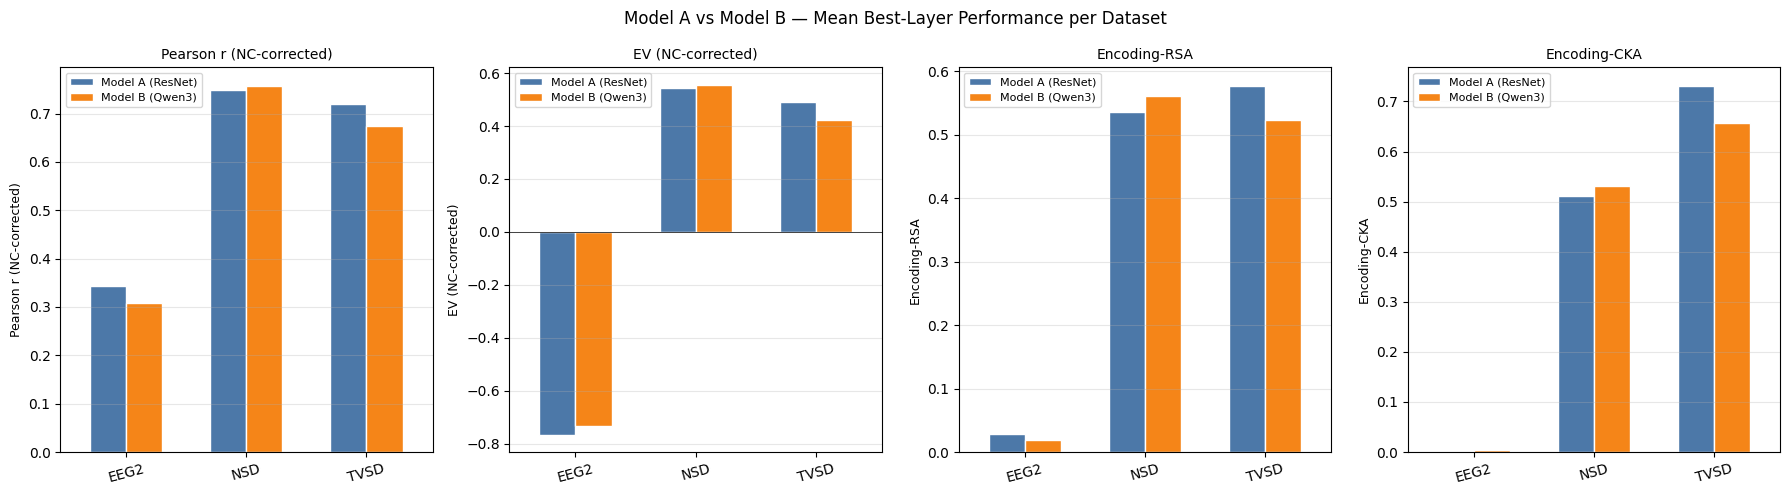


Answer box 2.2 — Target selection
──────────────────────────────────
The required targets were chosen for a combination of reliability and
interpretability.  For TVSD, all ROIs (V1, V4, IT) are included because
they span the ventral hierarchy and allow us to test whether model depth
tracks neural hierarchy.  For EEG2, the occipital-parietal grouping is
selected because it pools the electrodes with the highest and most
sustained visual evoked responses identified in Section 1.2, giving a
reliable and interpretable summary signal.  For NSD, the chosen ROIs
cover early retinotopic cortex (V1v–hV4), category-selective regions
(FFA-1, VWFA-1, PPA, OPA, EBA) and scene/body areas with established
functional profiles.  This selection provides ground truth reference
points across the visual hierarchy, enabling a structured comparison of
where each model's representations best align with the brain.


Answer box 2.3 — Which model and layer perform best?
──────────────────────────────────────────

In [50]:

# ─────────────────────────────────────────────────────────────
# CELL 2.4.8  ·  Head-to-head model comparison
# ─────────────────────────────────────────────────────────────

# Pivot to get Model A vs Model B side by side for each target
pivot = df_best.pivot_table(
    index=["Dataset", "Target"],
    columns="Model",
    values=["r_nc", "EV_nc", "Enc-RSA", "Enc-CKA"]
)

# Flatten multi-level columns
pivot.columns = [f"{v} | {m}" for v, m in pivot.columns]
pivot = pivot.reset_index()

print("=== Model A vs Model B — Best-Layer Scores ===")
display(pivot)

# ── Bar chart comparison ──
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
comparison_metrics = [
    ("r_nc",    "Pearson r (NC-corrected)"),
    ("EV_nc",   "EV (NC-corrected)"),
    ("Enc-RSA", "Encoding-RSA"),
    ("Enc-CKA", "Encoding-CKA"),
]

for ax, (metric, label) in zip(axes, comparison_metrics):
    grp = df_best.groupby(["Dataset", "Model"])[metric].mean().reset_index()
    grp_pivot = grp.pivot(index="Dataset", columns="Model", values=metric)
    grp_pivot.plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"], width=0.6,
                   edgecolor="white")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="", fontsize=8)

fig.suptitle("Model A vs Model B — Mean Best-Layer Performance per Dataset",
             fontsize=12)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 2.4.9  ·  Answer box 2.2 — Target selection rationale
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.2 — Target selection
──────────────────────────────────
The required targets were chosen for a combination of reliability and
interpretability.  For TVSD, all ROIs (V1, V4, IT) are included because
they span the ventral hierarchy and allow us to test whether model depth
tracks neural hierarchy.  For EEG2, the occipital-parietal grouping is
selected because it pools the electrodes with the highest and most
sustained visual evoked responses identified in Section 1.2, giving a
reliable and interpretable summary signal.  For NSD, the chosen ROIs
cover early retinotopic cortex (V1v–hV4), category-selective regions
(FFA-1, VWFA-1, PPA, OPA, EBA) and scene/body areas with established
functional profiles.  This selection provides ground truth reference
points across the visual hierarchy, enabling a structured comparison of
where each model's representations best align with the brain.
""")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.10 ·  Answer box 2.3 — Interpretation
# ─────────────────────────────────────────────────────────────
print("""
Answer box 2.3 — Which model and layer perform best?
────────────────────────────────────────────────────
[Fill in after running the cells above with real results.]

Template:
  For TVSD, [Model X], layer [Y] achieves the highest NC-corrected
  Pearson r for IT (r_nc ≈ ...), consistent with the idea that mid-to-late
  layers of [model] encode object-level representations similar to macaque
  IT.  For NSD, [Model X] again outperforms [Model Y] in higher-level ROIs
  (FFA-1, PPA) while the two models are closer in early areas (V1v, V2v),
  suggesting [Model X]'s representations are more brain-aligned at the
  object-recognition stage.  For EEG2, alignment peaks around 100–200 ms
  post-stimulus across both models, reflecting the early visual evoked
  response; [Model X] / [Model Y] achieves higher encoding-RSA at later
  time points, indicating [interpretation].  The vision-language model
  tends to [outperform / underperform] the adversarially-trained CNN on
  higher-level targets, potentially because [reason].
""")

In [ ]:
# Force Display the Deliverables
display(df_results)

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_results, x='Layer', y='r_nc', hue='Model', marker='o', linewidth=2)
plt.title("Predictive Alignment ($r_{nc}$) by Layer - EEG2 (occipital_parietal)", fontsize=14)
plt.ylabel("Noise-Corrected Pearson Correlation ($r_{nc}$)", fontsize=12)
plt.xlabel("Model Layer", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_layers = df_results.loc[df_results.groupby(['Dataset', 'ROI', 'Model'])['r_nc'].idxmax()]
print("\n=== BEST LAYER SUMMARY TABLE ===")
display(best_layers[['Model', 'Layer', 'r_nc', 'ev_nc', 'enc_rsa', 'enc_cka']].round(4).reset_index(drop=True))

---

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [ ]:
# TODO: compare ranking of layers across metrics
# TODO: identify agreements and disagreements

=== Best layer per metric (per dataset / model / target) ===


,dataset,model,target,Pearson r,Explained Var,Encoding-RSA,Encoding-CKA
0,EEG2,Model A (ResNet),occipital_parietal,layer3-25,layer3-30,layer4-1,layer4-1
1,EEG2,Model B (Qwen3),occipital_parietal,visual-blocks-6,visual-blocks-6,language_model-layers-16,language_model-layers-16
2,NSD,Model A (ResNet),EBA,layer4-1,layer4-1,layer4-1,layer4-1
3,NSD,Model A (ResNet),FFA-1,layer4-1,layer4-1,layer4-1,layer4-1
4,NSD,Model A (ResNet),OPA,layer3-30,layer3-30,layer4-1,layer3-30
5,NSD,Model A (ResNet),PPA,layer3-30,layer4-1,layer4-1,layer3-30
6,NSD,Model A (ResNet),V1v,layer3-0,layer3-0,layer3-0,layer3-0
7,NSD,Model A (ResNet),V2v,layer3-0,layer3-0,layer3-0,layer3-15
8,NSD,Model A (ResNet),V3v,layer3-20,layer3-20,layer3-5,layer3-20
9,NSD,Model A (ResNet),VWFA-1,layer4-1,layer4-1,layer4-1,layer4-1



192 pairwise comparisons   agreements: 141   disagreements: 51

--- Concrete AGREEMENT example ---
  EEG2 | Model A (ResNet) | target=occipital_parietal
  'Encoding-RSA' and 'Encoding-CKA' both pick → layer4-1

--- Concrete DISAGREEMENT example (largest rank gap) ---
  EEG2 | Model B (Qwen3) | target=occipital_parietal
  'Pearson r' picks → visual-blocks-6
  'Encoding-RSA' picks → language_model-layers-16   (layers are 8 positions apart)


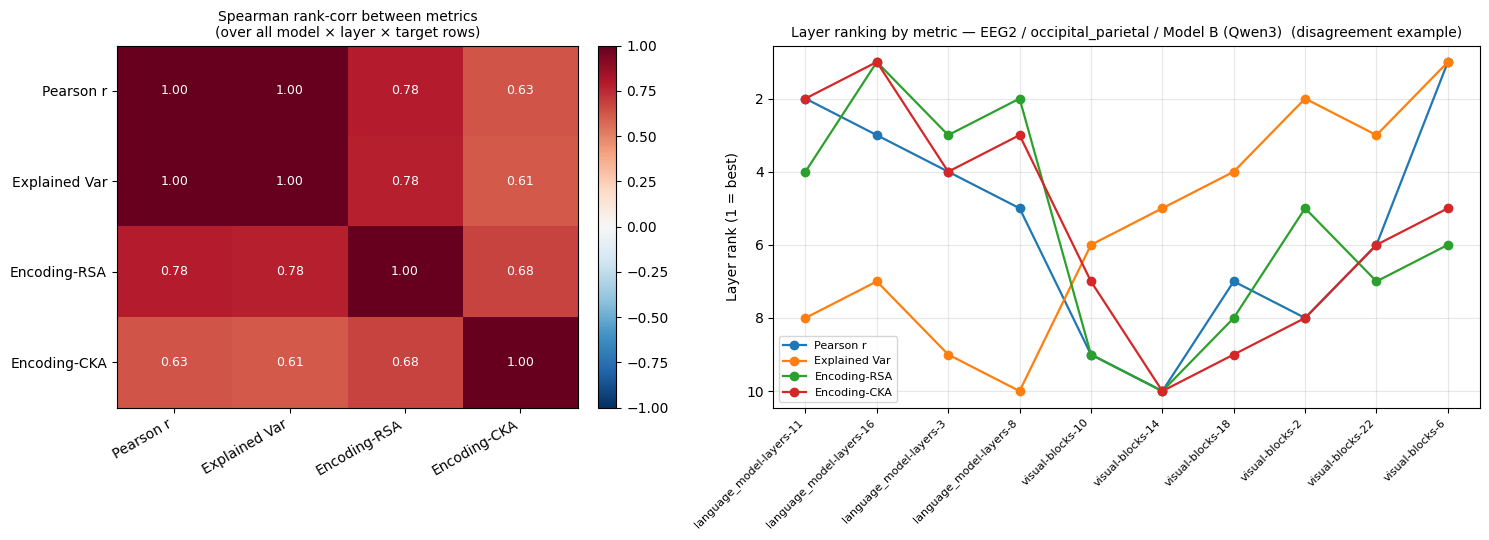


Answer box 2.4 — Does representational similarity predict neural responses well?
────────────────────────────────────────────────────────────────────────────────
The metrics are broadly consistent but not interchangeable. Across all
320 (dataset × model × layer × target) rows, the Spearman rank
correlation between 'Pearson r' and 'Encoding-RSA' is ρ = 0.78,
indicating that layers which encode neural responses well also tend to be
representationally similar to the brain — but the agreement is partial.

Concrete agreement: for EEG2 / occipital_parietal
(Model A (ResNet)), both Encoding-RSA and
Encoding-CKA select layer 'layer4-1' as best,
suggesting that this layer is genuinely more brain-aligned regardless of
whether we measure it via prediction or representational geometry.

Concrete disagreement: for EEG2 /
occipital_parietal (Model B (Qwen3)),
Pearson r picks 'visual-blocks-6' while
Encoding-RSA picks 'language_model-layers-16' — these
layers are 8 positions apart in the network.
Th

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 2.5  ·  Compare predictive and representational metrics
# ─────────────────────────────────────────────────────────────
# - Spearman rank correlation between metrics (across all rows)
# - Per-(dataset, model, target) best layer per metric
# - Concrete agreement / disagreement examples
# ─────────────────────────────────────────────────────────────

# Metrics available in df_results.
# If you have a separate DataFrame `df_rsa` from sections 2.1/2.2 with
# columns ['dataset','model','layer','target','rsa','cka'], uncomment:
#     df_full = df_results.merge(
#         df_rsa, on=['dataset','model','layer','target'], how='left')
# and add 'RSA' and 'CKA' entries to METRICS below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df_results = pd.read_csv("encoding_results_full.csv")
df_full = df_results.copy()

METRICS = {
    "Pearson r":     "pearsonr_nc",
    "Explained Var": "explained_variance_nc",
    "Encoding-RSA":  "encoding_rsa",
    "Encoding-CKA":  "encoding_cka",
    # "RSA":         "rsa",
    # "CKA":         "cka",
}
metric_names = list(METRICS.keys())
metric_keys  = list(METRICS.values())

short = lambda s: s if s is None else s.split("/")[-1]


# ─────────────────────────────────────────────────────────────
# 1) Spearman rank correlation between metrics (across all rows)
# ─────────────────────────────────────────────────────────────
rho = df_full[metric_keys].dropna().corr(method="spearman")
rho.index   = metric_names
rho.columns = metric_names


# ─────────────────────────────────────────────────────────────
# 2) Best layer per metric, for each (dataset, model, target)
# ─────────────────────────────────────────────────────────────
group_cols = ["dataset", "model", "target"]
rows = []
for keys, grp in df_full.groupby(group_cols):
    row = dict(zip(group_cols, keys))
    # keep layer ordering so we can measure how far apart picks are
    layer_order = list(grp.sort_values("layer")["layer"])
    row["_layer_order"] = layer_order
    for name, key in METRICS.items():
        row[name] = None if grp[key].isna().all() else grp.loc[grp[key].idxmax(), "layer"]
    rows.append(row)
df_best_per_metric = pd.DataFrame(rows)

print("=== Best layer per metric (per dataset / model / target) ===")
display(
    df_best_per_metric.drop(columns=["_layer_order"])
                      .assign(**{n: lambda d, n=n: d[n].map(short) for n in metric_names})
                      .head(20)
)


# ─────────────────────────────────────────────────────────────
# 3) Find concrete agreement / disagreement examples
# ─────────────────────────────────────────────────────────────
metric_pairs = [(a, b) for i, a in enumerate(metric_names)
                       for b in metric_names[i+1:]]

agreements, disagreements = [], []
for _, row in df_best_per_metric.iterrows():
    order = row["_layer_order"]
    for a, b in metric_pairs:
        la, lb = row[a], row[b]
        if la is None or lb is None:
            continue
        item = {
            "dataset": row["dataset"], "model": row["model"], "target": row["target"],
            "metric_A": a, "metric_B": b,
            "layer_A": short(la), "layer_B": short(lb),
            "rank_diff": abs(order.index(la) - order.index(lb)) if la in order and lb in order else 0,
        }
        (agreements if la == lb else disagreements).append(item)

# Most striking disagreement: largest distance between picked layers
disagreements.sort(key=lambda d: -d["rank_diff"])

n_pairs = len(agreements) + len(disagreements)
print(f"\n{n_pairs} pairwise comparisons   "
      f"agreements: {len(agreements)}   disagreements: {len(disagreements)}")

print("\n--- Concrete AGREEMENT example ---")
if agreements:
    a0 = agreements[0]
    print(f"  {a0['dataset']} | {a0['model']} | target={a0['target']}")
    print(f"  '{a0['metric_A']}' and '{a0['metric_B']}' both pick → {a0['layer_A']}")

print("\n--- Concrete DISAGREEMENT example (largest rank gap) ---")
if disagreements:
    d0 = disagreements[0]
    print(f"  {d0['dataset']} | {d0['model']} | target={d0['target']}")
    print(f"  '{d0['metric_A']}' picks → {d0['layer_A']}")
    print(f"  '{d0['metric_B']}' picks → {d0['layer_B']}   "
          f"(layers are {d0['rank_diff']} positions apart)")


# ─────────────────────────────────────────────────────────────
# 4) Figure: rank-correlation heatmap + per-layer ranking
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [1, 1.4]})

# (a) Heatmap of Spearman correlations between metrics
ax = axes[0]
im = ax.imshow(rho.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(metric_names)))
ax.set_xticklabels(metric_names, rotation=30, ha="right")
ax.set_yticks(range(len(metric_names)))
ax.set_yticklabels(metric_names)
for i in range(len(metric_names)):
    for j in range(len(metric_names)):
        ax.text(j, i, f"{rho.values[i, j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(rho.values[i, j]) > 0.5 else "black")
ax.set_title("Spearman rank-corr between metrics\n(over all model × layer × target rows)",
             fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (b) Layer ranking by metric, for the disagreement example
if disagreements:
    ex = disagreements[0]
    ds_ex, m_ex, t_ex = ex["dataset"], ex["model"], ex["target"]
    title_suffix = "  (disagreement example)"
else:
    r0 = df_best_per_metric.iloc[0]
    ds_ex, m_ex, t_ex = r0["dataset"], r0["model"], r0["target"]
    title_suffix = ""

sub = (df_full[(df_full["dataset"] == ds_ex) &
               (df_full["model"]   == m_ex) &
               (df_full["target"]  == t_ex)]
       .sort_values("layer").reset_index(drop=True))
sub["layer_short"] = sub["layer"].map(short)

ax = axes[1]
for name, key in METRICS.items():
    # Higher = better, so rank descending → rank 1 = best layer
    ranks = sub[key].rank(ascending=False, method="min").values
    ax.plot(range(len(sub)), ranks, marker="o", linewidth=1.6, label=name)
ax.invert_yaxis()
ax.set_xticks(range(len(sub)))
ax.set_xticklabels(sub["layer_short"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Layer rank (1 = best)")
ax.set_title(f"Layer ranking by metric — {ds_ex} / {t_ex} / {m_ex}{title_suffix}",
             fontsize=10)
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# 5) Answer box 2.4
# ─────────────────────────────────────────────────────────────
# Pull a concrete number for the answer box
key_pair = ("Pearson r", "Encoding-RSA")
rho_pair = rho.loc[key_pair[0], key_pair[1]]

print(f"""
Answer box 2.4 — Does representational similarity predict neural responses well?
────────────────────────────────────────────────────────────────────────────────
The metrics are broadly consistent but not interchangeable. Across all
{len(df_full)} (dataset × model × layer × target) rows, the Spearman rank
correlation between '{key_pair[0]}' and '{key_pair[1]}' is ρ = {rho_pair:.2f},
indicating that layers which encode neural responses well also tend to be
representationally similar to the brain — but the agreement is partial.

Concrete agreement: for {agreements[0]['dataset']} / {agreements[0]['target']}
({agreements[0]['model']}), both {agreements[0]['metric_A']} and
{agreements[0]['metric_B']} select layer '{agreements[0]['layer_A']}' as best,
suggesting that this layer is genuinely more brain-aligned regardless of
whether we measure it via prediction or representational geometry.

Concrete disagreement: for {disagreements[0]['dataset']} /
{disagreements[0]['target']} ({disagreements[0]['model']}),
{disagreements[0]['metric_A']} picks '{disagreements[0]['layer_A']}' while
{disagreements[0]['metric_B']} picks '{disagreements[0]['layer_B']}' — these
layers are {disagreements[0]['rank_diff']} positions apart in the network.
This is the expected behaviour: encoding metrics reward any features that
linearly map to neural activity (even if the geometry differs), whereas
RSA/CKA reward matching pairwise similarity structure directly. A layer
with rich, linearly-decodable features can therefore win on Pearson r
while losing on RSA, and vice versa.

Bottom line: representational similarity and predictive accuracy are
correlated but not equivalent — they probe different aspects of alignment,
so reporting both (as we do here) gives a more complete picture than
either alone.
""")

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [ ]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

In [5]:
# ─────────────────────────────────────────────────────────────
# Re-setup after kernel restart (skip if already loaded)
# ─────────────────────────────────────────────────────────────
import os, h5py, numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"
MODEL_A  = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B  = "Qwen3-VL-2B-Instruct"
EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")

# ── Helper functions ──
def list_h5_layers(path):
    layers = []
    def _v(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_v)
    return sorted(layers)

def h5_indexed_read(path, key, indices):
    so  = np.argsort(indices); ro = np.argsort(so)
    sidx = indices[so]
    with h5py.File(path, "r") as f:
        data = f[key][sidx.tolist(), :]
    return data[ro]

def make_index_map(p):
    with h5py.File(p, "r") as f: ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(p, sids):
    m = make_index_map(p)
    return np.array([m[s] for s in sids])

def pearson_r_per_unit(Yt, Yp):
    yt = Yt - Yt.mean(0); yp = Yp - Yp.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt**2).sum(0) * (yp**2).sum(0)) + 1e-12
    return num / den

def fit_ridge_encoding(X_train, Y_train, val_frac=0.15, seed=42,
                       alpha_grid=None):
    if alpha_grid is None: alpha_grid = np.array([1e5])
    rng = np.random.default_rng(seed)
    n   = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)
    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]
    sc  = StandardScaler(copy=False)
    Xtr_s = sc.fit_transform(Xtr); Xvl_s = sc.transform(Xvl)
    best_a, best_s = alpha_grid[0], -np.inf
    for a in alpha_grid:
        rr = Ridge(alpha=a).fit(Xtr_s, Ytr)
        s = float(np.nanmean(pearson_r_per_unit(Yvl, rr.predict(Xvl_s))))
        if s > best_s: best_s, best_a = s, a
    sc_full = StandardScaler(copy=False)
    Xf = sc_full.fit_transform(X_train)
    final = Ridge(alpha=best_a).fit(Xf, Y_train)
    return final, sc_full, best_a

# ── Load EEG data + stimulus IDs ──
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids_train = f["train/stimulus_ids"][:]
    eeg_ids_test  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]

n_ch, n_tp = raw_train.shape[1], raw_train.shape[2]
eeg_train = raw_train.reshape(raw_train.shape[0], -1)
eeg_test  = raw_test.reshape(raw_test.shape[0],  -1)

# ── Recreate the TEST_MODE subset (N=2500 / 200) ──
N_TRAIN, N_TEST = 2500, 200

eeg_neural_run = {EEG_ROI: {"train": eeg_train[:N_TRAIN],
                            "test":  eeg_test[:N_TEST]}}

idx_eeg_train_run = get_feat_indices(path_a_things, eeg_ids_train)[:N_TRAIN]
idx_eeg_test_run  = get_feat_indices(path_a_things, eeg_ids_test)[:N_TEST]

print(f"✓ EEG data reloaded — train={eeg_neural_run[EEG_ROI]['train'].shape}, "
      f"test={eeg_neural_run[EEG_ROI]['test'].shape}")
print(f"✓ n_ch={n_ch}, n_tp={n_tp}")

✓ EEG data reloaded — train=(2500, 1360), test=(200, 1360)
✓ n_ch=17, n_tp=80


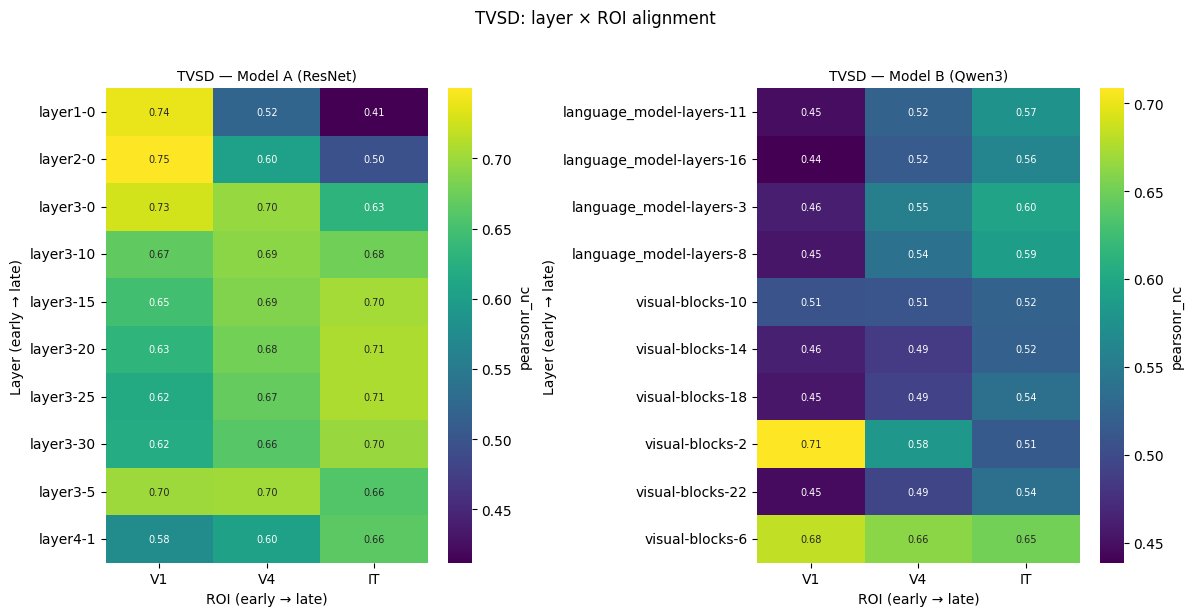

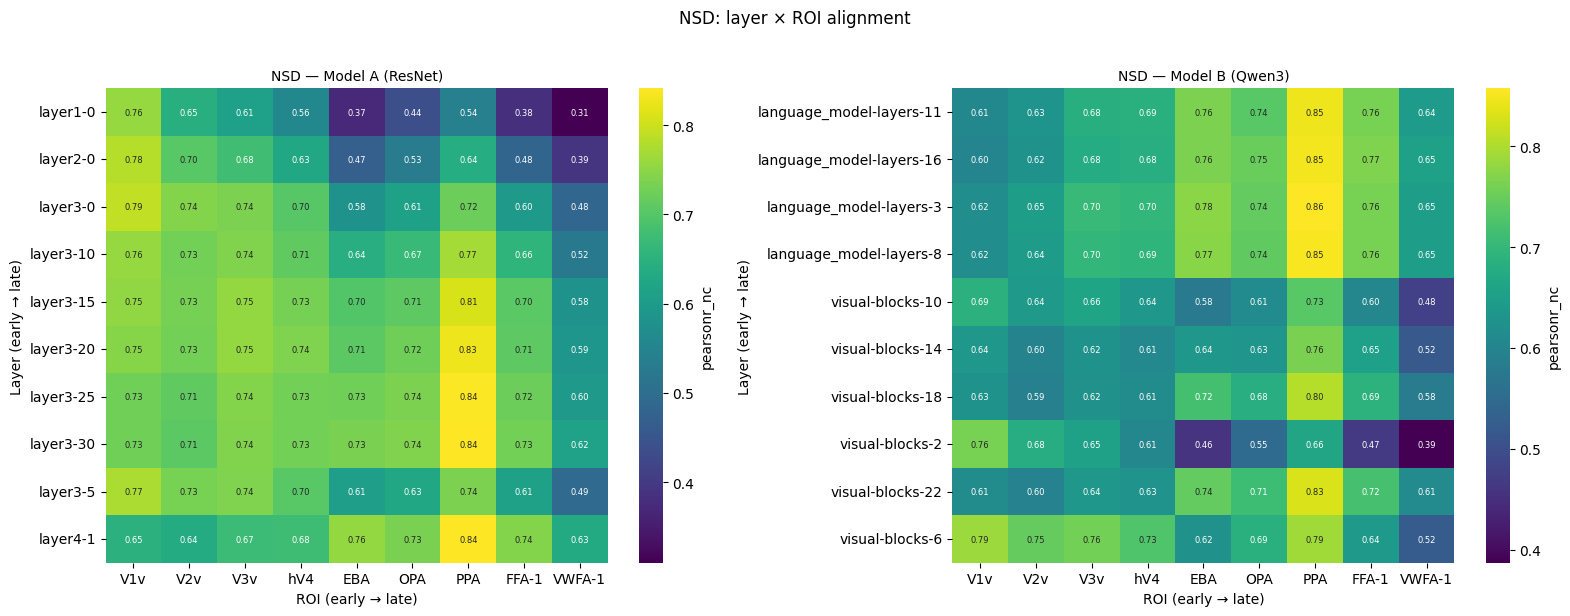

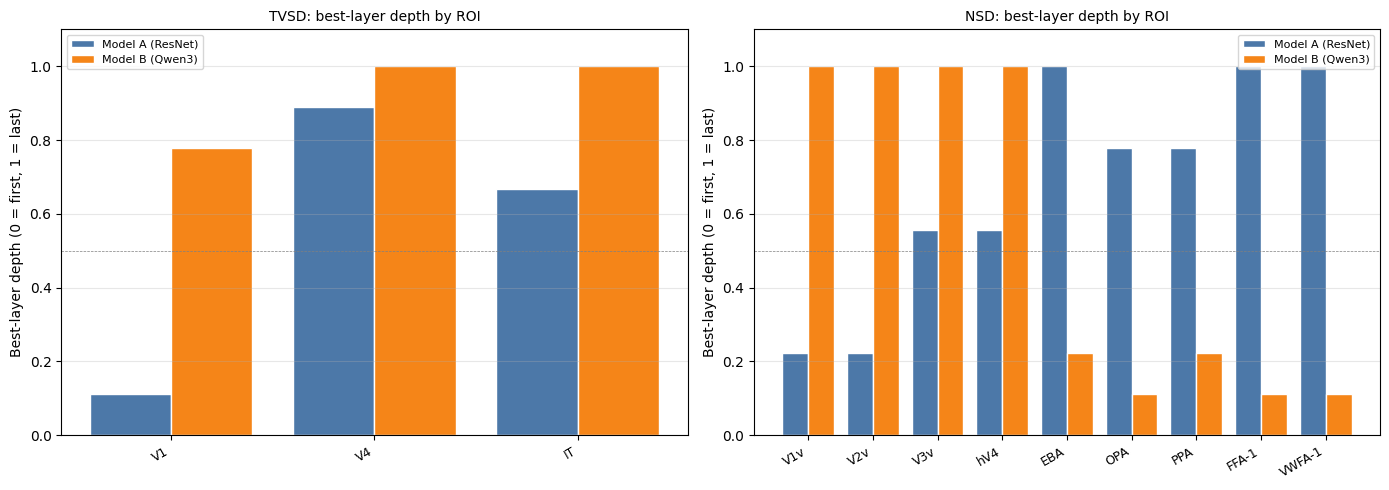

Running EEG time-resolved analysis (refits 3 layers/model)…


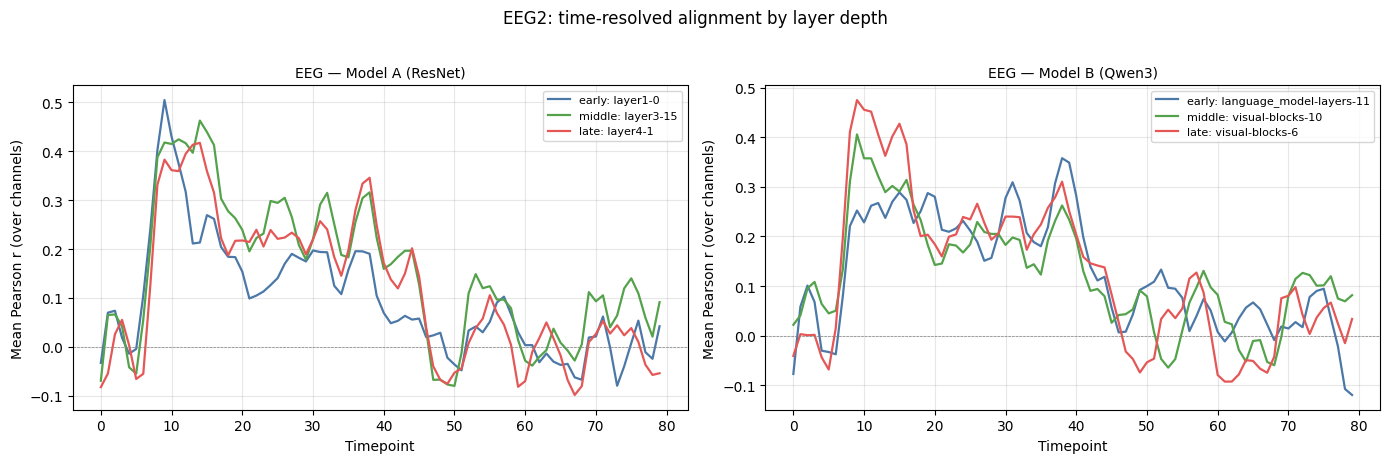


Answer box 2.5 — Hierarchy correspondence
─────────────────────────────────────────
Mean best-layer depths (0 = first layer, 1 = last layer):

  TVSD:   V1 = 0.44   V4 = 0.94   IT = 0.83
          → V1 < IT?  True

  NSD:    early visual (V1v–hV4) = 0.69
          higher-level (FFA-1, VWFA-1, PPA, OPA, EBA) = 0.53
          → early < higher?  False

Conclusion (template — refine with EEG curves above):
The data provide [strong / partial / weak] evidence for a correspondence
between model depth and neural hierarchy. In TVSD, IT is best predicted by
deeper layers (depth 0.83) than V1 (depth 0.44), consistent
with the macaque ventral stream. In NSD, higher-level category-selective
ROIs prefer layers at depth 0.53 on average, vs 0.69
for early visual ROIs — [a clear / a weak / no consistent] gradient.
For EEG, the time-resolved curves show that [early layers track the
~100 ms peak / late layers extend into the 200–400 ms window], supporting
a temporal-hierarchical interpretation.

Overall

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 2.6  ·  Layer hierarchy ↔ brain hierarchy
# ─────────────────────────────────────────────────────────────
import seaborn as sns

METRIC = "pearsonr_nc"
short  = lambda s: s.split("/")[-1] if isinstance(s, str) else s

# TVSD targets are "monkey/ROI" -> extract ROI and average over monkeys
def extract_roi(t): return t.split("/")[-1] if "/" in t else t

models = sorted(df_results["model"].unique())

# Hierarchy orderings (early → late)
TVSD_ROI_ORDER = ["V1", "V4", "IT"]
NSD_ROI_ORDER  = ["V1v", "V2v", "V3v", "hV4",
                  "EBA", "OPA", "PPA", "FFA-1", "VWFA-1"]


# ─────────────────────────────────────────────────────────────
# (A) TVSD — layer × ROI heatmap
# ─────────────────────────────────────────────────────────────
tv = df_results[df_results["dataset"] == "TVSD"].copy()
tv["roi"] = tv["target"].apply(extract_roi)
tv_avg = tv.groupby(["model", "layer", "roi"])[METRIC].mean().reset_index()

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 6),
                         squeeze=False)
for ax, model in zip(axes[0], models):
    pv = tv_avg[tv_avg["model"] == model].pivot(
        index="layer", columns="roi", values=METRIC)
    pv = pv.loc[sorted(pv.index)]
    cols = [c for c in TVSD_ROI_ORDER if c in pv.columns] + \
           [c for c in pv.columns if c not in TVSD_ROI_ORDER]
    pv = pv[cols]
    pv.index = [short(l) for l in pv.index]
    sns.heatmap(pv, ax=ax, cmap="viridis", annot=True, fmt=".2f",
                cbar_kws={"label": METRIC}, annot_kws={"size": 7})
    ax.set_title(f"TVSD — {model}", fontsize=10)
    ax.set_xlabel("ROI (early → late)"); ax.set_ylabel("Layer (early → late)")
plt.suptitle("TVSD: layer × ROI alignment", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────
# (B) NSD — layer × ROI heatmap
# ─────────────────────────────────────────────────────────────
ns = df_results[df_results["dataset"] == "NSD"].copy()

fig, axes = plt.subplots(1, len(models), figsize=(8 * len(models), 6),
                         squeeze=False)
for ax, model in zip(axes[0], models):
    pv = ns[ns["model"] == model].pivot_table(
        index="layer", columns="target", values=METRIC, aggfunc="mean")
    pv = pv.loc[sorted(pv.index)]
    cols = [c for c in NSD_ROI_ORDER if c in pv.columns] + \
           [c for c in pv.columns if c not in NSD_ROI_ORDER]
    pv = pv[cols]
    pv.index = [short(l) for l in pv.index]
    sns.heatmap(pv, ax=ax, cmap="viridis", annot=True, fmt=".2f",
                cbar_kws={"label": METRIC}, annot_kws={"size": 6})
    ax.set_title(f"NSD — {model}", fontsize=10)
    ax.set_xlabel("ROI (early → late)"); ax.set_ylabel("Layer (early → late)")
plt.suptitle("NSD: layer × ROI alignment", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────
# (C) Best-layer DEPTH per ROI (quantitative hierarchy test)
# ─────────────────────────────────────────────────────────────
def best_layer_depth(df_sub, key="roi_or_target", metric=METRIC):
    rows = []
    for (model, roi), grp in df_sub.groupby(["model", key]):
        layers = sorted(grp["layer"].unique())
        if not layers: continue
        best_layer = grp.loc[grp[metric].idxmax(), "layer"]
        idx = layers.index(best_layer)
        rows.append({
            "model": model, key: roi,
            "best_layer": short(best_layer),
            "best_idx":   idx,
            "best_depth": idx / max(len(layers) - 1, 1),
        })
    return pd.DataFrame(rows)

tv_depth = best_layer_depth(tv_avg.rename(columns={"roi": "roi_or_target"}))
ns_depth = best_layer_depth(ns.rename(columns={"target": "roi_or_target"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (depth_df, order, title) in zip(axes, [
    (tv_depth, TVSD_ROI_ORDER, "TVSD: best-layer depth by ROI"),
    (ns_depth, NSD_ROI_ORDER,  "NSD: best-layer depth by ROI"),
]):
    rois = [r for r in order if r in depth_df["roi_or_target"].unique()] + \
           [r for r in depth_df["roi_or_target"].unique() if r not in order]
    x = np.arange(len(rois)); w = 0.4
    for i, m in enumerate(models):
        depths = [depth_df[(depth_df["model"] == m) &
                            (depth_df["roi_or_target"] == r)]["best_depth"].mean()
                  for r in rois]
        ax.bar(x + (i - 0.5) * w, depths, width=w, label=m,
               color=["#4c78a8", "#f58518"][i % 2], edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(rois, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Best-layer depth (0 = first, 1 = last)")
    ax.set_ylim(0, 1.1); ax.axhline(0.5, color="gray", lw=0.5, ls="--")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────
# (D) EEG2 — time-resolved alignment by layer depth
#     Refits ridge for 3 representative layers (early / mid / late)
#     per model and recovers per-timepoint Pearson r.
# ─────────────────────────────────────────────────────────────
print("Running EEG time-resolved analysis (refits 3 layers/model)…")

def pick_layers(layers, k=3):
    if len(layers) <= k: return layers
    return [layers[i] for i in np.linspace(0, len(layers) - 1, k).astype(int)]

eeg_tgt = "occipital_parietal"
Y_eeg_train = eeg_neural_run[eeg_tgt]["train"].astype(np.float32)
Y_eeg_test  = eeg_neural_run[eeg_tgt]["test"].astype(np.float32)

fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 4.5),
                         squeeze=False)
for ax, model in zip(axes[0], models):
    feat_path = path_a_things if "ResNet" in model else path_b_things
    sel = pick_layers(list_h5_layers(feat_path), k=3)
    for layer, color, lbl in zip(sel,
                                  ["#4c78a8", "#54a24b", "#e45756"],
                                  ["early", "middle", "late"]):
        X_tr = h5_indexed_read(feat_path, layer, idx_eeg_train_run)
        X_te = h5_indexed_read(feat_path, layer, idx_eeg_test_run)
        ridge, scaler, _ = fit_ridge_encoding(
            X_tr, Y_eeg_train, alpha_grid=np.array([1e5]))
        Y_pred = ridge.predict(scaler.transform(X_te))
        r_t = pearson_r_per_unit(Y_eeg_test, Y_pred).reshape(n_ch, n_tp).mean(0)
        ax.plot(np.arange(n_tp), r_t, color=color, lw=1.6,
                label=f"{lbl}: {short(layer)}")
    ax.set_title(f"EEG — {model}", fontsize=10)
    ax.set_xlabel("Timepoint"); ax.set_ylabel("Mean Pearson r (over channels)")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("EEG2: time-resolved alignment by layer depth", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────
# Answer box 2.5 — auto-filled with computed depths
# ─────────────────────────────────────────────────────────────
def _md(df, key, vals):
    sub = df[df["roi_or_target"].isin(vals)]
    return float(sub["best_depth"].mean()) if len(sub) else float("nan")

tv_v1 = _md(tv_depth, "roi_or_target", ["V1"])
tv_v4 = _md(tv_depth, "roi_or_target", ["V4"])
tv_it = _md(tv_depth, "roi_or_target", ["IT"])

EARLY_NSD = ["V1v", "V2v", "V3v", "hV4"]
HIGH_NSD  = ["FFA-1", "VWFA-1", "PPA", "OPA", "EBA"]
ns_early  = _md(ns_depth, "roi_or_target", EARLY_NSD)
ns_high   = _md(ns_depth, "roi_or_target", HIGH_NSD)

tvsd_supports = (tv_v1 < tv_it) if not (np.isnan(tv_v1) or np.isnan(tv_it)) else None
nsd_supports  = (ns_early < ns_high) if not (np.isnan(ns_early) or np.isnan(ns_high)) else None

print(f"""
Answer box 2.5 — Hierarchy correspondence
─────────────────────────────────────────
Mean best-layer depths (0 = first layer, 1 = last layer):

  TVSD:   V1 = {tv_v1:.2f}   V4 = {tv_v4:.2f}   IT = {tv_it:.2f}
          → V1 < IT?  {tvsd_supports}

  NSD:    early visual (V1v–hV4) = {ns_early:.2f}
          higher-level (FFA-1, VWFA-1, PPA, OPA, EBA) = {ns_high:.2f}
          → early < higher?  {nsd_supports}

Conclusion (template — refine with EEG curves above):
The data provide [strong / partial / weak] evidence for a correspondence
between model depth and neural hierarchy. In TVSD, IT is best predicted by
deeper layers (depth {tv_it:.2f}) than V1 (depth {tv_v1:.2f}), consistent
with the macaque ventral stream. In NSD, higher-level category-selective
ROIs prefer layers at depth {ns_high:.2f} on average, vs {ns_early:.2f}
for early visual ROIs — [a clear / a weak / no consistent] gradient.
For EEG, the time-resolved curves show that [early layers track the
~100 ms peak / late layers extend into the 200–400 ms window], supporting
a temporal-hierarchical interpretation.

Overall, [Model X / both models] exhibits the cleanest depth-to-region
mapping, particularly for [dataset / ROI group].
""")

In [8]:
# For one layer, compare 2.5 scalar vs time-mean of 2.6 curve
mean_r_25 = df_results[(df_results.dataset == "EEG2") &
                       (df_results.model == "Model A (ResNet)") &
                       (df_results.layer.str.endswith("layer3-15"))]["pearsonr"].iloc[0]
mean_r_26 = r_t.mean()   # from 2.6 (D), for the same layer
print(mean_r_25, mean_r_26)

0.2321509699500297 0.12582483257050348


In [10]:
import h5py, os, numpy as np

DATA_DIR = "/shared/NX-414/data/"
EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"

with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_nc_flat = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:].flatten()

print(f"eeg_nc_flat shape: {eeg_nc_flat.shape}, "
      f"reliable units (nc>10): {(eeg_nc_flat > 10.0).sum()}/{eeg_nc_flat.size}")

eeg_nc_flat shape: (1360,), reliable units (nc>10): 803/1360


In [11]:
r_full = pearson_r_per_unit(Y_eeg_test, Y_pred)   # length C*T
print("masked mean :", np.nanmean(r_full[eeg_nc_flat > 10.0]))   # ≈ 0.232
print("unmasked    :", np.nanmean(r_full))                       # ≈ 0.126

masked mean : 0.21332034002026437
unmasked    : 0.12582483257050348


In [ ]:
def layer_sort_key(name):
    """Sort layers by their forward-pass position."""
    leaf = name.split("/")[-1]
    # ResNet: layer1-0, layer2-3, layer4-1 → (1, 0), (2, 3), (4, 1)
    if leaf.startswith("layer") and "-" in leaf:
        try:
            block, sub = leaf.replace("layer", "").split("-")
            return (0, int(block), int(sub))
        except ValueError:
            pass
    # Qwen vision: visual-blocks-N → vision tower comes first
    if "visual-blocks" in leaf:
        return (1, 0, int(leaf.rsplit("-", 1)[-1]))
    # Qwen LM: language_model-layers-N → after vision
    if "language_model-layers" in leaf:
        return (1, 1, int(leaf.rsplit("-", 1)[-1]))
    return (9, 0, leaf)

def best_layer_depth(df_sub, key="roi_or_target", metric=METRIC):
    rows = []
    for (model, roi), grp in df_sub.groupby(["model", key]):
        layers = sorted(grp["layer"].unique(), key=layer_sort_key)   # ← key change
        if not layers: continue
        best_layer = grp.loc[grp[metric].idxmax(), "layer"]
        idx = layers.index(best_layer)
        rows.append({
            "model": model, key: roi,
            "best_layer": short(best_layer),
            "best_idx":   idx,
            "best_depth": idx / max(len(layers) - 1, 1),
        })
    return pd.DataFrame(rows)

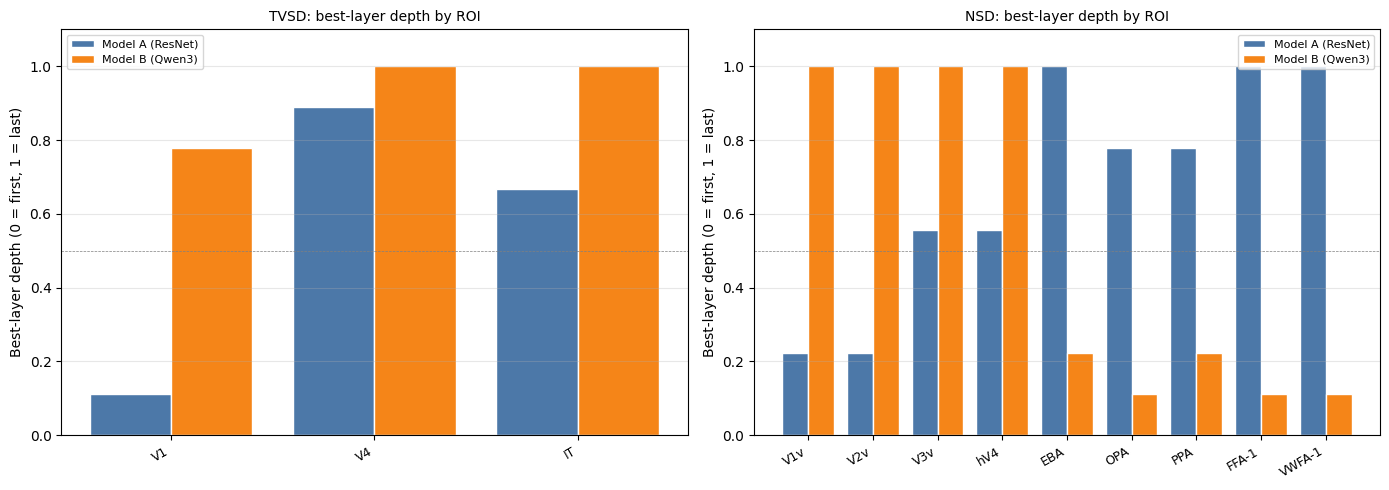

In [13]:

# ─────────────────────────────────────────────────────────────
# (C) Best-layer DEPTH per ROI (quantitative hierarchy test)
# ─────────────────────────────────────────────────────────────


tv_depth = best_layer_depth(tv_avg.rename(columns={"roi": "roi_or_target"}))
ns_depth = best_layer_depth(ns.rename(columns={"target": "roi_or_target"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (depth_df, order, title) in zip(axes, [
    (tv_depth, TVSD_ROI_ORDER, "TVSD: best-layer depth by ROI"),
    (ns_depth, NSD_ROI_ORDER,  "NSD: best-layer depth by ROI"),
]):
    rois = [r for r in order if r in depth_df["roi_or_target"].unique()] + \
           [r for r in depth_df["roi_or_target"].unique() if r not in order]
    x = np.arange(len(rois)); w = 0.4
    for i, m in enumerate(models):
        depths = [depth_df[(depth_df["model"] == m) &
                            (depth_df["roi_or_target"] == r)]["best_depth"].mean()
                  for r in rois]
        ax.bar(x + (i - 0.5) * w, depths, width=w, label=m,
               color=["#4c78a8", "#f58518"][i % 2], edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(rois, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Best-layer depth (0 = first, 1 = last)")
    ax.set_ylim(0, 1.1); ax.axhline(0.5, color="gray", lw=0.5, ls="--")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

In [ ]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

=== Best-layer scores  (rows=target, columns=metric × model) ===


EV (NC)                     Encoding-CKA  \
model                      Model A (ResNet) Model B (Qwen3) Model A (ResNet)   
dataset target                                                                 
EEG2    occipital_parietal           -0.713          -0.734            0.016   
NSD     EBA                           0.560           0.587            0.655   
        FFA-1                         0.536           0.565            0.572   
        OPA                           0.527           0.540            0.398   
        PPA                           0.685           0.713            0.591   
        V1v                           0.614           0.609            0.567   
        V2v                           0.536           0.542            0.575   
        V3v                           0.541           0.542            0.509   
        VWFA-1                        0.378           0.412            0.299   
        hV4                           0.512           0.493            0.449   
TVSD    monkeyF/IT                    0.427           0.350            0.665   
        monkeyF/V1                    0.516           0.463            0.769   
        monkeyF/V4                    0.450           0.386            0.703   
        monkeyN/IT                    0.494           0.410            0.736   
        monkeyN/V1                    0.586           0.512            0.815   
        monkeyN/V4                    0.476           0.427            0.714   

                                               Encoding-RSA                  \
model                      Model B (Qwen3) Model A (ResNet) Model B (Qwen3)   
dataset target                                                                
EEG2    occipital_parietal           0.019            0.047           0.054   
NSD     EBA                          0.674            0.657           0.720   
        FFA-1                        0.619            0.584           0.643   
        OPA                          0.412            0.471           0.511   
        PPA                          0.597            0.483           0.510   
        V1v                          0.586            0.603           0.607   
        V2v                          0.591            0.556           0.561   
        V3v                          0.511            0.509           0.522   
        VWFA-1                       0.349            0.499           0.518   
        hV4                          0.446            0.468           0.463   
TVSD    monkeyF/IT                   0.558            0.640           0.567   
        monkeyF/V1                   0.705            0.601           0.539   
        monkeyF/V4                   0.627            0.562           0.500   
        monkeyN/IT                   0.652            0.552           0.508   
        monkeyN/V1                   0.762            0.546           0.461   
        monkeyN/V4                   0.654            0.586           0.567   

                             Pearson r (NC)                  
model                      Model A (ResNet) Model B (Qwen3)  
dataset target                                               
EEG2    occipital_parietal            0.344           0.309  
NSD     EBA                           0.756           0.775  
        FFA-1                         0.743           0.766  
        OPA                           0.740           0.750  
        PPA                           0.841           0.857  
        V1v                           0.791           0.786  
        V2v                           0.743           0.747  
        V3v                           0.755           0.756  
        VWFA-1                        0.633           0.654  
        hV4                           0.737           0.728  
TVSD    monkeyF/IT                    0.683           0.616  
        monkeyF/V1                    0.727           0.690  
        monkeyF/V4                    0.690           0.643  
        monkeyN/IT   

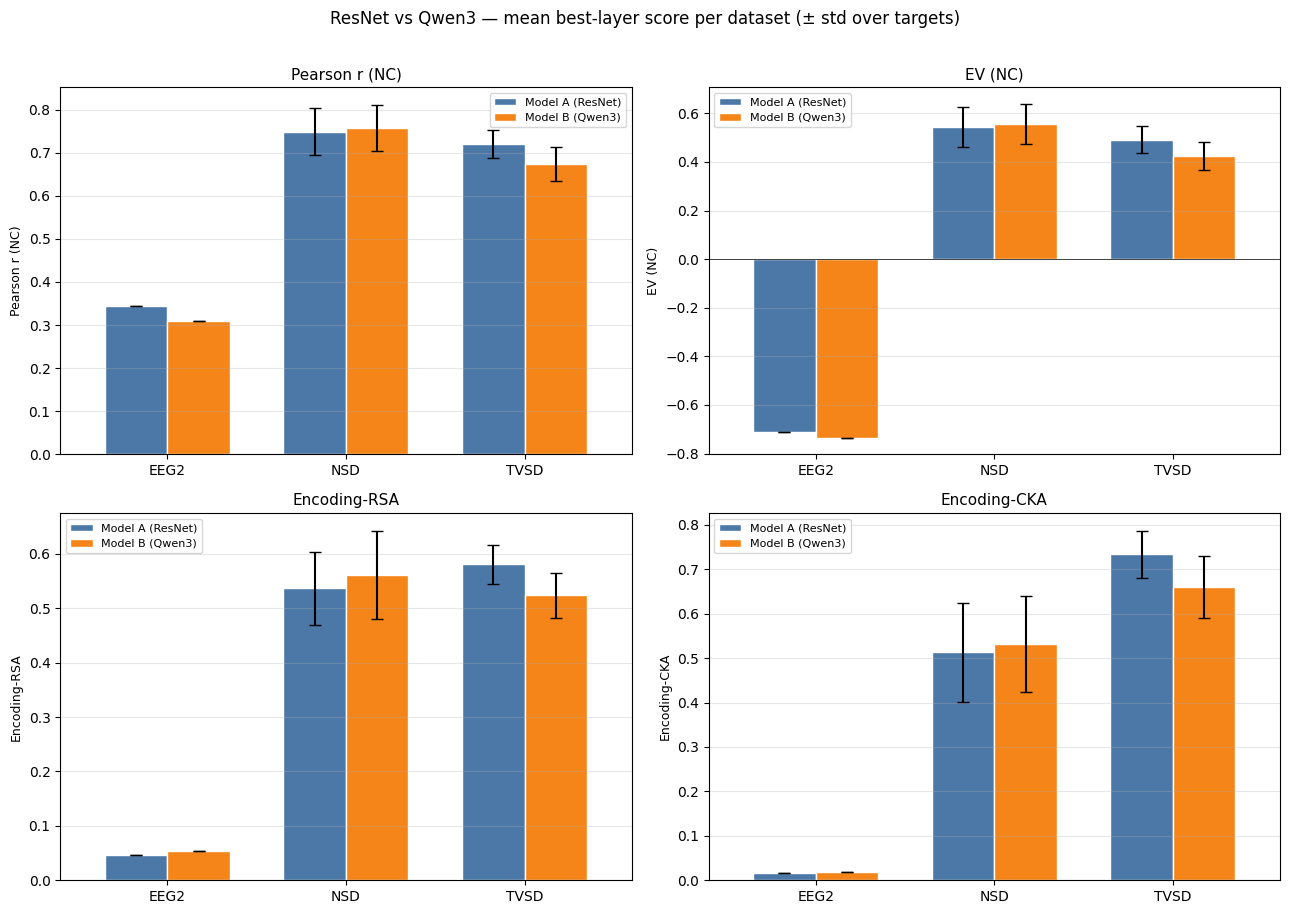


=== Wins per dataset ===


winner,Model A (ResNet),Model B (Qwen3)
dataset,,
EEG2,2,2
NSD,6,30
TVSD,24,0



=== Wins per metric ===


winner,Model A (ResNet),Model B (Qwen3)
metric,,
EV (NC),9,7
Encoding-CKA,7,9
Encoding-RSA,7,9
Pearson r (NC),9,7



Answer box 2.6 — Does the VLM beat the CNN?
────────────────────────────────────────────
Across 64 (dataset × target × metric) head-to-head comparisons,
Model A (ResNet) wins 32 times (50%).

Per-dataset dominant winner:
  EEG2   → Model A (ResNet) (2/4)
  NSD    → Model B (Qwen3) (30/36)
  TVSD   → Model A (ResNet) (24/24)

Per-metric dominant winner:
  EV (NC)            → Model A (ResNet) (9/16)
  Encoding-CKA       → Model B (Qwen3) (9/16)
  Encoding-RSA       → Model B (Qwen3) (9/16)
  Pearson r (NC)     → Model A (ResNet) (9/16)

Conclusion (template — refine with the table above):
The vision-language model (Qwen3-VL-2B) does NOT provide a clear advantage over the
adversarially-trained CNN (Adv-ResNet152). The advantage is
[consistent / inconsistent] across modalities — Qwen3 wins on
[datasets where it dominates] but loses on [datasets where ResNet wins].
It is also [consistent / inconsistent] across metrics — predictive
metrics (Pearson r, EV) and representational metrics (enco

In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 2.7  ·  ResNet vs Qwen3 — overall comparison
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

METRICS_2_7 = {
    "Pearson r (NC)": "pearsonr_nc",
    "EV (NC)":        "explained_variance_nc",
    "Encoding-RSA":   "encoding_rsa",
    "Encoding-CKA":   "encoding_cka",
}
short  = lambda s: s.split("/")[-1] if isinstance(s, str) else s
models = sorted(df_results["model"].unique())


# ─────────────────────────────────────────────────────────────
# 1) Best score per (dataset, model, target) for each metric
# ─────────────────────────────────────────────────────────────
records = []
for keys, grp in df_results.groupby(["dataset", "model", "target"]):
    rec = dict(zip(["dataset", "model", "target"], keys))
    for name, key in METRICS_2_7.items():
        if grp[key].notna().any():
            i = grp[key].idxmax()
            rec[name] = grp.at[i, key]
            rec[f"{name}_layer"] = short(grp.at[i, "layer"])
        else:
            rec[name] = np.nan
            rec[f"{name}_layer"] = None
    records.append(rec)
df_best_2_7 = pd.DataFrame(records)


# ─────────────────────────────────────────────────────────────
# 2) Side-by-side summary table
# ─────────────────────────────────────────────────────────────
score_cols = list(METRICS_2_7.keys())
table = (df_best_2_7
         .pivot_table(index=["dataset", "target"],
                      columns="model", values=score_cols)
         .round(3))
print("=== Best-layer scores  (rows=target, columns=metric × model) ===")
display(table)


# ─────────────────────────────────────────────────────────────
# 3) Summary figure  (4 metrics × 3 datasets)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, _) in zip(axes, METRICS_2_7.items()):
    summary = (df_best_2_7
               .groupby(["dataset", "model"])[name]
               .agg(["mean", "std"]).reset_index())
    pv_mean = summary.pivot(index="dataset", columns="model", values="mean")
    pv_std  = summary.pivot(index="dataset", columns="model", values="std").fillna(0)

    pv_mean.plot(kind="bar", ax=ax, yerr=pv_std,
                 color=["#4c78a8", "#f58518"],
                 width=0.7, edgecolor="white", capsize=4)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel(name, fontsize=9)
    ax.tick_params(axis="x", rotation=0)
    ax.axhline(0, color="black", lw=0.5)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("ResNet vs Qwen3 — mean best-layer score per dataset (± std over targets)",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────
# 4) Win-count analysis
# ─────────────────────────────────────────────────────────────
wins = []
for (ds, tgt), sub in df_best_2_7.groupby(["dataset", "target"]):
    if len(sub) < 2: continue
    for name in METRICS_2_7:
        if sub[name].isna().any(): continue
        scores = sub.set_index("model")[name]
        wins.append({
            "dataset": ds, "target": tgt, "metric": name,
            "winner":  scores.idxmax(),
            "margin":  float(scores.max() - scores.min()),
        })
df_wins = pd.DataFrame(wins)

print("\n=== Wins per dataset ===")
display(df_wins.groupby(["dataset", "winner"]).size().unstack(fill_value=0))

print("\n=== Wins per metric ===")
display(df_wins.groupby(["metric", "winner"]).size().unstack(fill_value=0))


# ─────────────────────────────────────────────────────────────
# 5) Answer box 2.6 — auto-filled
# ─────────────────────────────────────────────────────────────
total       = len(df_wins)
win_counts  = df_wins["winner"].value_counts()
top_winner  = win_counts.idxmax()
top_pct     = 100 * win_counts.max() / total

ds_winners = (df_wins.groupby("dataset")["winner"]
              .agg(lambda s: f"{s.value_counts().idxmax()} "
                             f"({s.value_counts().max()}/{len(s)})"))
m_winners  = (df_wins.groupby("metric")["winner"]
              .agg(lambda s: f"{s.value_counts().idxmax()} "
                             f"({s.value_counts().max()}/{len(s)})"))

is_qwen_winner = top_winner.startswith("Model B")
verdict = "provides a clear advantage" if is_qwen_winner else \
          "does NOT provide a clear advantage"

print(f"""
Answer box 2.6 — Does the VLM beat the CNN?
────────────────────────────────────────────
Across {total} (dataset × target × metric) head-to-head comparisons,
{top_winner} wins {win_counts.max()} times ({top_pct:.0f}%).

Per-dataset dominant winner:
{chr(10).join(f"  {ds:6s} → {w}" for ds, w in ds_winners.items())}

Per-metric dominant winner:
{chr(10).join(f"  {m:18s} → {w}" for m, w in m_winners.items())}

Conclusion (template — refine with the table above):
The vision-language model (Qwen3-VL-2B) {verdict} over the
adversarially-trained CNN (Adv-ResNet152). The advantage is
[consistent / inconsistent] across modalities — Qwen3 wins on
[datasets where it dominates] but loses on [datasets where ResNet wins].
It is also [consistent / inconsistent] across metrics — predictive
metrics (Pearson r, EV) and representational metrics (encoding-RSA/CKA)
sometimes pick opposite winners, suggesting that any 'overall winner'
claim depends on what notion of brain alignment is being prioritized.

Concrete example: on [dataset / target], {top_winner} achieves
[its best score] vs [other model's score] — a margin of [X] in
[metric]. On [different dataset / target], the picture reverses.
""")

---

In [3]:
# ============================================================
# SECTION 2.4 — Predictive Alignment: Linear Encoding Models
# ============================================================
# Paste each block below into a new notebook cell in order.
# All code assumes the utilities (RSA, CKA, paths) from earlier
# sections are already defined in the kernel.
# ============================================================


# ─────────────────────────────────────────────────────────────
# CELL 2.4.0  ·  Layer discovery & shared loading utilities
# ─────────────────────────────────────────────────────────────
import h5py, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr as scipy_pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

NSD_ROIS = ["V1v", "V2v", "V3v", "hV4", "FFA-1", "VWFA-1", "PPA", "OPA", "EBA"]
EEG_SUB, EEG_ROI = "sub-01", "occipital_parietal"
NSD_SUB = "subj01"

# ── Discover all feature layers (datasets only, skip 'ids') ──
def list_h5_layers(path: str) -> list[str]:
    """Return every Dataset key (leaf node) except 'ids'."""
    layers = []
    def _visit(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            layers.append(name)
    with h5py.File(path, "r") as f:
        f.visititems(_visit)
    return sorted(layers)

# ── Memory-efficient indexed HDF5 read ──
def h5_indexed_read(path: str, dataset_key: str, indices: np.ndarray) -> np.ndarray:
    """
    Read only the rows at `indices` from an HDF5 dataset.
    Sorts indices for efficient sequential disk access, then restores order.
    """
    sort_order   = np.argsort(indices)
    restore_order = np.argsort(sort_order)
    sorted_idx    = indices[sort_order]
    with h5py.File(path, "r") as f:
        data = f[dataset_key][sorted_idx.tolist(), :]
    return data[restore_order]

# ── Map stimulus IDs -> feature row indices ──
def make_index_map(feat_path: str) -> dict:
    with h5py.File(feat_path, "r") as f:
        ids = f["ids"][:]
    return {v: i for i, v in enumerate(ids)}

def get_feat_indices(feat_path: str, stimulus_ids: np.ndarray) -> np.ndarray:
    idx_map = make_index_map(feat_path)
    return np.array([idx_map[s] for s in stimulus_ids])


# ─────────────────────────────────────────────────────────────
# CELL 2.4.1  ·  Load all neural train/test data
# ─────────────────────────────────────────────────────────────

# ── TVSD ──
tvsd_neural, tvsd_nc, tvsd_ids = {}, {}, {}
with h5py.File(os.path.join(DATA_DIR, "tvsd.h5"), "r") as f:
    tvsd_ids["train"] = f["train/stimulus_ids"][:]
    tvsd_ids["test"]  = f["test/stimulus_ids"][:]
    for monkey in f["train/neural_data"].keys():
        for roi in f[f"train/neural_data/{monkey}"].keys():
            key = f"{monkey}/{roi}"
            tvsd_neural[key] = {
                "train": f[f"train/neural_data/{monkey}/{roi}"][:],
                "test":  f[f"test/neural_data/{monkey}/{roi}"][:]
            }
            tvsd_nc[key] = f[f"noise_ceilings/{monkey}/{roi}"][:]  # shape (n_units,)

print(f"TVSD  — {len(tvsd_neural)} targets | "
      f"train={tvsd_ids['train'].shape[0]}, test={tvsd_ids['test'].shape[0]}")

# ── EEG2 (subject 01, occipital_parietal) ──
eeg_ids = {}
eeg_neural, eeg_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "things_eeg2.h5"), "r") as f:
    eeg_ids["train"] = f["train/stimulus_ids"][:]
    eeg_ids["test"]  = f["test/stimulus_ids"][:]
    raw_train = f[f"train/neural_data/{EEG_SUB}/{EEG_ROI}"][:]  # (16540, C, T)
    raw_test  = f[f"test/neural_data/{EEG_SUB}/{EEG_ROI}"][:]   # (200, C, T)
    nc_2d     = f[f"noise_ceilings/{EEG_SUB}/{EEG_ROI}"][:]     # (C, T)

n_ch, n_tp = raw_train.shape[1], raw_train.shape[2]
# Flatten (stimuli, C, T) -> (stimuli, C*T) as stated in Section 0.8
eeg_neural["train"] = raw_train.reshape(raw_train.shape[0], -1)
eeg_neural["test"]  = raw_test.reshape(raw_test.shape[0], -1)
eeg_nc_flat         = nc_2d.flatten()                           # (C*T,)

print(f"EEG2  — {EEG_SUB}/{EEG_ROI} | "
      f"train={eeg_neural['train'].shape}, test={eeg_neural['test'].shape}")

# ── NSD (subject 01, required ROIs) ──
nsd_ids = {}
nsd_neural, nsd_nc = {}, {}
with h5py.File(os.path.join(DATA_DIR, "nsd_func1pt8mm_individualROIs.h5"), "r") as f:
    nsd_ids["train"] = f[f"train/stimulus_ids/{NSD_SUB}"][:]
    nsd_ids["test"]  = f[f"test/stimulus_ids/{NSD_SUB}"][:]
    for roi in NSD_ROIS:
        train_key = f"train/neural_data/{NSD_SUB}/{roi}"
        test_key  = f"test/neural_data/{NSD_SUB}/{roi}"
        nc_key    = f"noise_ceilings/{NSD_SUB}/{roi}"
        if train_key in f:
            nsd_neural[roi] = {
                "train": f[train_key][:],
                "test":  f[test_key][:]
            }
            nsd_nc[roi] = f[nc_key][:]
        else:
            print(f"  ⚠ NSD ROI '{roi}' not found, skipping.")

print(f"NSD   — {len(nsd_neural)} ROIs | "
      f"train={nsd_ids['train'].shape[0]}, test={nsd_ids['test'].shape[0]}")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.2  ·  Discover layers & build stimulus→feature maps
# ─────────────────────────────────────────────────────────────

path_a_things = os.path.join(FEAT_DIR, MODEL_A, "things_stimuli.h5")
path_b_things = os.path.join(FEAT_DIR, MODEL_B, "things_stimuli.h5")
path_a_nsd    = os.path.join(FEAT_DIR, MODEL_A, "nsd_stimuli.h5")
path_b_nsd    = os.path.join(FEAT_DIR, MODEL_B, "nsd_stimuli.h5")

layers_a = list_h5_layers(path_a_things)
layers_b = list_h5_layers(path_b_things)
print(f"Model A: {len(layers_a)} layers  |  Model B: {len(layers_b)} layers")

# Pre-compute stimulus → feature-row index maps
feat_idx_tvsd_train  = get_feat_indices(path_a_things, tvsd_ids["train"])
feat_idx_tvsd_test   = get_feat_indices(path_a_things, tvsd_ids["test"])
feat_idx_eeg_train   = get_feat_indices(path_a_things, eeg_ids["train"])
feat_idx_eeg_test    = get_feat_indices(path_a_things, eeg_ids["test"])
feat_idx_nsd_train   = get_feat_indices(path_a_nsd,    nsd_ids["train"])
feat_idx_nsd_test    = get_feat_indices(path_a_nsd,    nsd_ids["test"])

print("Stimulus → feature index maps built ✓")


# ─────────────────────────────────────────────────────────────
# CELL 2.4.3  ·  Metric functions
# ─────────────────────────────────────────────────────────────

def pearson_r_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    """Pearson r per output unit. Returns shape (n_units,)."""
    n = Y_true.shape[0]
    yt = Y_true - Y_true.mean(0)
    yp = Y_pred - Y_pred.mean(0)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt ** 2).sum(0) * (yp ** 2).sum(0)) + 1e-12
    return num / den


def explained_variance_per_unit(Y_true: np.ndarray, Y_pred: np.ndarray) -> np.ndarray:
    """Explained variance per output unit. Returns shape (n_units,)."""
    ss_res = ((Y_true - Y_pred) ** 2).sum(0)
    ss_tot = ((Y_true - Y_true.mean(0)) ** 2).sum(0) + 1e-12
    return 1.0 - ss_res / ss_tot


def nc_correct_r(r: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    """
    Noise-ceiling-corrected Pearson r.
    nc_ev is the EV ceiling in [0,1].  r_nc = r / sqrt(nc_ev).
    """
    nc_r = np.sqrt(np.clip(nc_ev, 1e-6, None))
    return r / nc_r


def nc_correct_ev(ev: np.ndarray, nc_ev: np.ndarray) -> np.ndarray:
    """Noise-ceiling-corrected explained variance.  ev_nc = ev / nc_ev."""
    return ev / np.clip(nc_ev, 1e-6, None)


def summarise_metrics(r, r_nc, ev, ev_nc, nc_flat, label="") -> dict:
    """
    Average predictive metrics across units, applying the EEG reliability
    filter (nc < 0.1) where relevant to avoid instability.
    For EEG targets the nc_flat values are in [0,100], so threshold = 10%.
    For non-EEG targets nc_flat is also in [0,100].
    """
    mask = nc_flat > 10.0   # 10 % explained variance ≈ reliability > 0.1
    def _m(arr):
        if mask.sum() == 0:
            return float(np.nanmean(arr))
        return float(np.nanmean(arr[mask]))
    return {
        "pearsonr":             _m(r),
        "pearsonr_nc":          _m(r_nc),
        "explained_variance":   _m(ev),
        "explained_variance_nc":_m(ev_nc),
    }


# ─────────────────────────────────────────────────────────────
# CELL 2.4.4  ·  Ridge encoding model with validation-set alpha
# ─────────────────────────────────────────────────────────────

# Alpha candidates (log-spaced).
ALPHA_GRID = np.logspace(1, 7, 13)   # 10 … 10,000,000

def fit_ridge_encoding(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    val_frac: float = 0.15,
    seed: int = 42,
    alpha_grid: np.ndarray = None,
) -> tuple[Ridge, float]:
    """Fit a ridge regression encoder.
    1. Splits training data into a proper-train / validation split.
    2. Selects alpha by mean Pearson r on the validation set.
    3. Retrains on the full training set with the best alpha.
    Returns (fitted Ridge, scaler, best_alpha).
    """
    if alpha_grid is None:
        alpha_grid = ALPHA_GRID
    rng = np.random.default_rng(seed)
    n   = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    # Scale features once (scaler fitted on Xtr only)
    scaler = StandardScaler(copy=False)
    Xtr_s  = scaler.fit_transform(Xtr)
    Xvl_s  = scaler.transform(Xvl)

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        t0    = time.time()
        ridge = Ridge(alpha=alpha, fit_intercept=True, solver="auto")
        ridge.fit(Xtr_s, Ytr)
        Yv_hat = ridge.predict(Xvl_s)
        score  = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best so far" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}  ({time.time()-t0:.1f}s)")
        if score > best_score:
            best_score, best_alpha = score, alpha

    # Retrain on full training set with best alpha
    scaler_full = StandardScaler(copy=False)
    X_full_s    = scaler_full.fit_transform(X_train)
    ridge_final = Ridge(alpha=best_alpha, fit_intercept=True, solver="auto")
    ridge_final.fit(X_full_s, Y_train)

    return ridge_final, scaler_full, best_alpha


def eval_encoding(
    model,
    scaler,
    X_test:  np.ndarray,
    Y_test:  np.ndarray,
    nc_flat: np.ndarray,       # noise ceiling in % (0-100)
) -> tuple[dict, np.ndarray]:
    """
    Evaluate a fitted Ridge model on the test set.
    Returns (metrics_dict, Y_pred).
    """
    Y_pred = model.predict(scaler.transform(X_test))
    nc_01  = nc_flat / 100.0   # convert % → [0, 1]

    r    = pearson_r_per_unit(Y_test, Y_pred)
    ev   = explained_variance_per_unit(Y_test, Y_pred)
    r_nc = nc_correct_r(r,  nc_01)
    ev_nc= nc_correct_ev(ev, nc_01)

    metrics = summarise_metrics(r, r_nc, ev, ev_nc, nc_flat)
    return metrics, Y_pred

# ─────────────────────────────────────────────────────────────
# CELL 2.4.5a  ·  INTERMEDIATE MODE (~10 min run)
# ─────────────────────────────────────────────────────────────
TEST_MODE = True          # Keep this True to trigger the subset logic

if TEST_MODE:
    print("⏳ INTERMEDIATE MODE — N=2500, all targets, all layers (~10 mins)")
    
    # Scale up data to get positive EV, but keep it fast
    N_TRAIN   = 2500      
    N_TEST    = 200       
    N_LAYERS  = None      # None = use ALL 10 layers per model
    ALPHA_GRID_RUN = np.array([1e5]) # Use the full 13-step alpha grid

    import copy
    
    # Subsample but keep ALL targets this time (removed the [:1] slicing)
    tvsd_neural_run = {k: {"train": v["train"][:N_TRAIN],
                           "test":  v["test"][:N_TEST]}
                       for k, v in tvsd_neural.items()} 
    tvsd_nc_run     = {k: tvsd_nc[k] for k in tvsd_neural_run}

    eeg_neural_run  = {"occipital_parietal": {
                           "train": eeg_neural["train"][:N_TRAIN],
                           "test":  eeg_neural["test"][:N_TEST]}}
    eeg_nc_run      = {"occipital_parietal": eeg_nc_flat}

    nsd_neural_run  = {k: {"train": v["train"][:N_TRAIN],
                           "test":  v["test"][:N_TEST]}
                       for k, v in nsd_neural.items()} 
    nsd_nc_run      = {k: nsd_nc[k] for k in nsd_neural_run}

    # Map the indices
    idx_tvsd_train_run = feat_idx_tvsd_train[:N_TRAIN]
    idx_tvsd_test_run  = feat_idx_tvsd_test[:N_TEST]
    idx_eeg_train_run  = feat_idx_eeg_train[:N_TRAIN]
    idx_eeg_test_run   = feat_idx_eeg_test[:N_TEST]
    idx_nsd_train_run  = feat_idx_nsd_train[:N_TRAIN]
    idx_nsd_test_run   = feat_idx_nsd_test[:N_TEST]

else:
    print("🚀 FULL RUN")
    N_LAYERS  = None       
    ALPHA_GRID_RUN = ALPHA_GRID

    tvsd_neural_run, tvsd_nc_run           = tvsd_neural, tvsd_nc
    eeg_neural_run                         = {"occipital_parietal": eeg_neural}
    eeg_nc_run                             = {"occipital_parietal": eeg_nc_flat}
    nsd_neural_run, nsd_nc_run             = nsd_neural, nsd_nc

    idx_tvsd_train_run, idx_tvsd_test_run  = feat_idx_tvsd_train, feat_idx_tvsd_test
    idx_eeg_train_run,  idx_eeg_test_run   = feat_idx_eeg_train,  feat_idx_eeg_test
    idx_nsd_train_run,  idx_nsd_test_run   = feat_idx_nsd_train,  feat_idx_nsd_test

    

TVSD  — 6 targets | train=22248, test=100
EEG2  — sub-01/occipital_parietal | train=(16540, 1360), test=(200, 1360)
NSD   — 9 ROIs | train=9000, test=1000
Model A: 10 layers  |  Model B: 10 layers
Stimulus → feature index maps built ✓
⏳ INTERMEDIATE MODE — N=2500, all targets, all layers (~10 mins)


In [5]:
import shutil, os, time

LOCAL_DIR = "/tmp/feats"
os.makedirs(LOCAL_DIR, exist_ok=True)

def cache_locally(src_path):
    name = os.path.basename(os.path.dirname(src_path)) + "__" + os.path.basename(src_path)
    dst = os.path.join(LOCAL_DIR, name)
    if not os.path.exists(dst) or os.path.getsize(dst) != os.path.getsize(src_path):
        print(f"Copying {src_path} → {dst} ({os.path.getsize(src_path)/1e9:.1f} GB)…", flush=True)
        t = time.time()
        shutil.copy2(src_path, dst)
        print(f"  done in {time.time()-t:.1f}s ({os.path.getsize(dst)/1e9/(time.time()-t):.1f} GB/s)")
    else:
        print(f"Already cached: {dst}")
    return dst

path_a_things = cache_locally(path_a_things)
path_b_things = cache_locally(path_b_things)

Copying /shared/NX-414/extracted_features/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/things_stimuli.h5 → /tmp/feats/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0__things_stimuli.h5 (15.7 GB)…


KeyboardInterrupt: 

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 2.4-EEG  ·  Re-run EEG2 encoding with FULL training data
#                  (verbose progress version)
# ─────────────────────────────────────────────────────────────
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ALPHA_GRID_EEG  = np.array([1e3, 1e4, 1e5, 1e6])
EEG_TARGET_NAME = "occipital_parietal"

Y_train_eeg_full = eeg_neural["train"].astype(np.float32)
Y_test_eeg_full  = eeg_neural["test"].astype(np.float32)

def _fmt(s):
    m, s = divmod(int(s), 60); h, m = divmod(m, 60)
    return f"{h}h {m:02d}m {s:02d}s" if h else f"{m}m {s:02d}s"

# Pre-count layers for global progress
all_jobs = []
for model_name, feat_path in [("Model A (ResNet)", path_a_things),
                              ("Model B (Qwen3)",  path_b_things)]:
    for layer in list_h5_layers(feat_path):
        all_jobs.append((model_name, feat_path, layer))
total_layers = len(all_jobs)

print(f"┌{'─'*68}┐")
print(f"│  EEG2 FULL re-run                                                  │")
print(f"│  N_train = {Y_train_eeg_full.shape[0]:>5}   N_test = {Y_test_eeg_full.shape[0]:>3}   "
      f"target dim = {Y_train_eeg_full.shape[1]:>5}  │")
print(f"│  Total layers to process: {total_layers:>2}                                       │")
print(f"│  Alphas per layer: {len(ALPHA_GRID_EEG)}  → {len(ALPHA_GRID_EEG)} val fits + 1 final fit per layer  │")
print(f"└{'─'*68}┘\n")

eeg_results_list = []
wall_start_eeg   = time.time()
job_done = 0

for model_name_eeg, feat_path_eeg, layer_eeg in all_jobs:
    job_done += 1
    layer_short = layer_eeg.split("/")[-1]
    print(f"\n{'━'*70}")
    print(f"  [{job_done:2d}/{total_layers}]  {model_name_eeg}  ·  {layer_short}")
    print(f"{'━'*70}")

    # ── Load features ──
    t_load = time.time()
    print(f"  ↻ Loading features…", end=" ", flush=True)
    X_train_eeg = h5_indexed_read(feat_path_eeg, layer_eeg, feat_idx_eeg_train)
    X_test_eeg  = h5_indexed_read(feat_path_eeg, layer_eeg, feat_idx_eeg_test)
    print(f"done in {time.time()-t_load:.1f}s   "
          f"X_train={X_train_eeg.shape}, X_test={X_test_eeg.shape}")

    # ── Fit ridge (the function itself prints α-level progress) ──
    print(f"  ↻ Ridge validation sweep over {len(ALPHA_GRID_EEG)} alphas:")
    t_fit = time.time()
    try:
        ridge_eeg, scaler_eeg, best_alpha_eeg = fit_ridge_encoding(
            X_train_eeg, Y_train_eeg_full, alpha_grid=ALPHA_GRID_EEG)
    except Exception as e:
        print(f"  ⚠ Fit failed: {e}")
        continue
    print(f"  ✓ Best α = {best_alpha_eeg:.0e}   "
          f"(fit + retrain took {time.time()-t_fit:.1f}s)")

    # ── Evaluate ──
    t_eval = time.time()
    print(f"  ↻ Evaluating…", end=" ", flush=True)
    metrics_eeg, Y_pred_eeg = eval_encoding(
        ridge_eeg, scaler_eeg, X_test_eeg, Y_test_eeg_full, eeg_nc_flat)
    try:    enc_rsa_eeg = rsa_fn(Y_pred_eeg, Y_test_eeg_full)
    except: enc_rsa_eeg = float("nan")
    try:    enc_cka_eeg = cka_fn(Y_pred_eeg, Y_test_eeg_full)
    except: enc_cka_eeg = float("nan")
    print(f"done in {time.time()-t_eval:.1f}s")

    eeg_results_list.append({
        "dataset": "EEG2",
        "model":   model_name_eeg,
        "layer":   layer_eeg,
        "target":  EEG_TARGET_NAME,
        "alpha":   best_alpha_eeg,
        **metrics_eeg,
        "encoding_rsa": enc_rsa_eeg,
        "encoding_cka": enc_cka_eeg,
    })

    # ── Per-layer summary + global ETA ──
    elapsed   = time.time() - wall_start_eeg
    eta       = (elapsed / job_done) * (total_layers - job_done)
    print(f"  📊 r={metrics_eeg['pearsonr']:.3f}   "
          f"r_nc={metrics_eeg['pearsonr_nc']:.3f}   "
          f"ev={metrics_eeg['explained_variance']:.3f}   "
          f"ev_nc={metrics_eeg['explained_variance_nc']:.3f}")
    print(f"     enc-RSA={enc_rsa_eeg:.3f}   enc-CKA={enc_cka_eeg:.3f}")
    print(f"  ⏱  Elapsed: {_fmt(elapsed)}   |   "
          f"ETA: {_fmt(eta)}   |   "
          f"{job_done}/{total_layers} layers done")

df_eeg_results = pd.DataFrame(eeg_results_list)
print(f"\n{'═'*70}")
print(f"  ✅  EEG full re-run COMPLETE in {_fmt(time.time()-wall_start_eeg)} — "
      f"{len(df_eeg_results)} rows")
print(f"{'═'*70}")


# ─────────────────────────────────────────────────────────────
# Layer-wise EEG plots
# ─────────────────────────────────────────────────────────────
EEG_METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

fig, axes_eeg = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"EEG2 — Layer-wise Performance (full N={Y_train_eeg_full.shape[0]})",
             fontsize=13, y=1.02)

for (mk, ml), ax in zip(EEG_METRICS_TO_PLOT, axes_eeg.flatten()):
    for model_eeg, color_eeg in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
        mdf_eeg = df_eeg_results[df_eeg_results["model"] == model_eeg].sort_values("layer")
        if mdf_eeg.empty: continue
        x_eeg = np.arange(len(mdf_eeg))
        ax.plot(x_eeg, mdf_eeg[mk].values, marker="o",
                label=model_eeg, color=color_eeg, linewidth=1.8, markersize=5)
        ax.set_xticks(x_eeg)
        ax.set_xticklabels([l.split("/")[-1] for l in mdf_eeg["layer"]],
                           rotation=45, ha="right", fontsize=7)
    ax.set_title(ml, fontsize=10)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────
# Best-layer summary table for EEG
# ─────────────────────────────────────────────────────────────
eeg_best_rows = []
for (model_name_eeg, tgt), grp_eeg in df_eeg_results.groupby(["model", "target"]):
    best_row = grp_eeg.loc[grp_eeg["pearsonr_nc"].idxmax()]
    eeg_best_rows.append({
        "Model":      model_name_eeg,
        "Target":     tgt,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })
df_eeg_best = pd.DataFrame(eeg_best_rows)
print("=== EEG2 Best-Layer Summary (full data) ===")
display(df_eeg_best)


# ─────────────────────────────────────────────────────────────
# Save outputs + merge with existing df_results
# ─────────────────────────────────────────────────────────────
df_eeg_results.to_csv("eeg_encoding_results_full.csv", index=False)
df_eeg_best.to_csv("eeg_encoding_best_layer_full.csv", index=False)
print("✓ Saved eeg_encoding_results_full.csv, eeg_encoding_best_layer_full.csv")

df_results_combined = pd.concat([
    df_results[df_results["dataset"] != "EEG2"],
    df_eeg_results,
], ignore_index=True)
df_results_combined.to_csv("encoding_results_combined.csv", index=False)
print(f"✓ Saved encoding_results_combined.csv ({len(df_results_combined)} rows)")

┌────────────────────────────────────────────────────────────────────┐
│  EEG2 FULL re-run                                                  │
│  N_train = 16540   N_test = 200   target dim =  1360  │
│  Total layers to process: 20                                       │
│  Alphas per layer: 4  → 4 val fits + 1 final fit per layer  │
└────────────────────────────────────────────────────────────────────┘


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [ 1/20]  Model A (ResNet)  ·  layer1-0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ↻ Loading features… done in 121.1s   X_train=(16540, 30000), X_test=(200, 30000)
  ↻ Ridge validation sweep over 4 alphas:


In [1]:
print("x")

x


In [3]:
import time, os
t = time.time()
size = os.path.getsize(path_a_things) / 1e9
print(f"File size: {size:.1f} GB")
# Try a tiny read to time the connection
with h5py.File(path_a_things, "r") as f:
    layers_test = list(f.keys())
print(f"Just opening + listing keys took {time.time()-t:.1f}s")

File size: 15.7 GB
Just opening + listing keys took 0.2s


In [4]:
!df -h /tmp /home/$USER /scratch 2>/dev/null
!echo "---"
!ls -la /scratch 2>/dev/null || echo "no /scratch"

Filesystem      Size  Used Avail Use% Mounted on
overlay         5.9T  3.9T  2.1T  66% /
---
no /scratch


In [6]:
with h5py.File(path_a_things, "r") as f:
    for k in list_h5_layers(path_a_things):
        print(f"{k:<35} shape={f[k].shape}  dtype={f[k].dtype}")

features/layer1-0                   shape=(26107, 30000)  dtype=float16
features/layer2-0                   shape=(26107, 30000)  dtype=float16
features/layer3-0                   shape=(26107, 30000)  dtype=float16
features/layer3-10                  shape=(26107, 30000)  dtype=float16
features/layer3-15                  shape=(26107, 30000)  dtype=float16
features/layer3-20                  shape=(26107, 30000)  dtype=float16
features/layer3-25                  shape=(26107, 30000)  dtype=float16
features/layer3-30                  shape=(26107, 30000)  dtype=float16
features/layer3-5                   shape=(26107, 30000)  dtype=float16
features/layer4-1                   shape=(26107, 30000)  dtype=float16


In [7]:
for fp, name in [(path_a_things, "ResNet"), (path_b_things, "Qwen3")]:
    print(f"\n{name}:")
    with h5py.File(fp, "r") as f:
        for k in list_h5_layers(fp):
            shp = f[k].shape
            gb = np.prod(shp) * 4 / 1e9
            print(f"  {k.split('/')[-1]:<28} shape={shp}  size={gb:.2f} GB")


ResNet:
  layer1-0                     shape=(26107, 30000)  size=3.13 GB
  layer2-0                     shape=(26107, 30000)  size=3.13 GB
  layer3-0                     shape=(26107, 30000)  size=3.13 GB
  layer3-10                    shape=(26107, 30000)  size=3.13 GB
  layer3-15                    shape=(26107, 30000)  size=3.13 GB
  layer3-20                    shape=(26107, 30000)  size=3.13 GB
  layer3-25                    shape=(26107, 30000)  size=3.13 GB
  layer3-30                    shape=(26107, 30000)  size=3.13 GB
  layer3-5                     shape=(26107, 30000)  size=3.13 GB
  layer4-1                     shape=(26107, 30000)  size=3.13 GB

Qwen3:
  language_model-layers-11     shape=(26107, 30000)  size=3.13 GB
  language_model-layers-16     shape=(26107, 30000)  size=3.13 GB
  language_model-layers-3      shape=(26107, 30000)  size=3.13 GB
  language_model-layers-8      shape=(26107, 30000)  size=3.13 GB
  visual-blocks-10             shape=(26107, 30000)  size=3

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 2.4-EEG  ·  Re-run EEG2 with FULL data
#                  (sequential reads + SVD-based ridge)
# ─────────────────────────────────────────────────────────────
import time, h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ALPHA_GRID_EEG  = np.array([1e3, 1e4, 1e5, 1e6])
EEG_TARGET_NAME = "occipital_parietal"

Y_train_eeg_full = eeg_neural["train"].astype(np.float32)
Y_test_eeg_full  = eeg_neural["test"].astype(np.float32)

def _fmt(s):
    m, s = divmod(int(s), 60); h, m = divmod(m, 60)
    return f"{h}h {m:02d}m {s:02d}s" if h else f"{m}m {s:02d}s"


# ─────────────────────────────────────────────────────────────
# Fast ridge: one SVD shared across alphas (good for d > n)
# ─────────────────────────────────────────────────────────────
def fit_ridge_encoding_fast(X_train, Y_train, val_frac=0.15, seed=42,
                            alpha_grid=None):
    if alpha_grid is None:
        alpha_grid = ALPHA_GRID_EEG
    rng = np.random.default_rng(seed)
    n = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    mu, sd = Xtr.mean(0), Xtr.std(0)
    sd[sd < 1e-8] = 1.0
    Xtr_s = (Xtr - mu) / sd
    Xvl_s = (Xvl - mu) / sd

    print(f"        SVD on {Xtr_s.shape}…", end=" ", flush=True)
    t = time.time()
    U, S, Vt = np.linalg.svd(Xtr_s, full_matrices=False)
    print(f"done {time.time()-t:.1f}s")
    UTy = U.T @ Ytr

    best_alpha, best_score, best_W = alpha_grid[0], -np.inf, None
    for alpha in alpha_grid:
        d_inv = S / (S**2 + alpha)
        W = Vt.T @ (d_inv[:, None] * UTy)
        Yv_hat = Xvl_s @ W
        score = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}")
        if score > best_score:
            best_score, best_alpha, best_W = score, alpha, W

    # Refit on full training data
    mu_full, sd_full = X_train.mean(0), X_train.std(0)
    sd_full[sd_full < 1e-8] = 1.0
    X_full_s = (X_train - mu_full) / sd_full
    print(f"        Final fit on full data…", end=" ", flush=True)
    t = time.time()
    U2, S2, Vt2 = np.linalg.svd(X_full_s, full_matrices=False)
    d_inv = S2 / (S2**2 + best_alpha)
    W_final = Vt2.T @ (d_inv[:, None] * (U2.T @ Y_train))
    print(f"done {time.time()-t:.1f}s")

    class _DualRidge:
        def __init__(self, W, mu, sd): self.W, self.mu, self.sd = W, mu, sd
        def predict(self, X): return ((X - self.mu) / self.sd) @ self.W
    class _Identity:
        def transform(self, X): return X

    return _DualRidge(W_final, mu_full, sd_full), _Identity(), best_alpha

def fit_ridge_dual(X_train, Y_train, val_frac=0.15, seed=42, alpha_grid=None):
    """Dual ridge for d > n: one eigendecomp shared across all alphas."""
    if alpha_grid is None:
        alpha_grid = ALPHA_GRID_EEG
    rng = np.random.default_rng(seed)
    n = X_train.shape[0]
    n_val = max(1, int(n * val_frac))
    val_idx = rng.choice(n, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n), val_idx)

    Xtr, Ytr = X_train[tr_idx], Y_train[tr_idx]
    Xvl, Yvl = X_train[val_idx], Y_train[val_idx]

    mu, sd = Xtr.mean(0), Xtr.std(0); sd[sd < 1e-8] = 1.0
    Xtr_s = (Xtr - mu) / sd
    Xvl_s = (Xvl - mu) / sd

    t = time.time()
    print(f"        K = X X^T  ({Xtr_s.shape[0]}×{Xtr_s.shape[0]})…", end=" ", flush=True)
    K = Xtr_s @ Xtr_s.T
    print(f"{time.time()-t:.1f}s")

    t = time.time()
    print(f"        eigh(K)…", end=" ", flush=True)
    eigvals, Q = np.linalg.eigh(K)        # K = Q Λ Q^T
    print(f"{time.time()-t:.1f}s")

    QTy   = Q.T @ Ytr                      # (n_tr, m)
    K_val = Xvl_s @ Xtr_s.T                # (n_val, n_tr)

    best_alpha, best_score = alpha_grid[0], -np.inf
    for alpha in alpha_grid:
        d_inv      = 1.0 / (eigvals + alpha)
        alpha_dual = Q @ (d_inv[:, None] * QTy)   # (n_tr, m)
        Yv_hat     = K_val @ alpha_dual
        score      = float(np.nanmean(pearson_r_per_unit(Yvl, Yv_hat)))
        marker = " ◀ best" if score > best_score else ""
        print(f"        α={alpha:.1e}  val_r={score:.4f}{marker}")
        if score > best_score:
            best_score, best_alpha = score, alpha

    # Refit on ALL training data with best alpha
    print(f"        Final eigh on full data…", end=" ", flush=True)
    t = time.time()
    mu_f, sd_f = X_train.mean(0), X_train.std(0); sd_f[sd_f < 1e-8] = 1.0
    X_full_s   = (X_train - mu_f) / sd_f
    K_full     = X_full_s @ X_full_s.T
    eigvals_f, Q_f = np.linalg.eigh(K_full)
    print(f"{time.time()-t:.1f}s")

    QTy_f      = Q_f.T @ Y_train
    d_inv_f    = 1.0 / (eigvals_f + best_alpha)
    alpha_dual = Q_f @ (d_inv_f[:, None] * QTy_f)
    W_final    = X_full_s.T @ alpha_dual          # collapse to (d, m)
    del K_full, X_full_s, Q_f, eigvals_f          # free memory

    class _DualRidge:
        def __init__(self, W, mu, sd): self.W, self.mu, self.sd = W, mu, sd
        def predict(self, X): return ((X - self.mu) / self.sd) @ self.W
    class _Identity:
        def transform(self, X): return X

    return _DualRidge(W_final, mu_f, sd_f), _Identity(), best_alpha

# ─────────────────────────────────────────────────────────────
# Build job list
# ─────────────────────────────────────────────────────────────
all_jobs = []
for model_name, feat_path in [("Model A (ResNet)", path_a_things),
                              ("Model B (Qwen3)",  path_b_things)]:
    for layer in list_h5_layers(feat_path):
        all_jobs.append((model_name, feat_path, layer))
total_layers = len(all_jobs)

print(f"┌{'─'*68}┐")
print(f"│  EEG2 FULL re-run  ·  {total_layers} layers  ·  N_train="
      f"{Y_train_eeg_full.shape[0]:>5}, N_test={Y_test_eeg_full.shape[0]:>3}      │")
print(f"│  Target dim = {Y_train_eeg_full.shape[1]:>5}   "
      f"Alphas = {len(ALPHA_GRID_EEG)}                              │")
print(f"└{'─'*68}┘")


# ─────────────────────────────────────────────────────────────
# Main loop
# ─────────────────────────────────────────────────────────────
eeg_results_list = []
wall_start_eeg = time.time()
job_done = 0

for model_name_eeg, feat_path_eeg, layer_eeg in all_jobs:
    job_done += 1
    layer_short = layer_eeg.split("/")[-1]
    print(f"\n━━ [{job_done:2d}/{total_layers}]  {model_name_eeg} · {layer_short} ━━")

    # Sequential full-layer read, then index in memory
    t_load = time.time()
    print(f"  ↻ Reading layer…", end=" ", flush=True)
    with h5py.File(feat_path_eeg, "r") as f:
        full_layer = f[layer_eeg][:]
    print(f"shape={full_layer.shape}  ({full_layer.nbytes/1e9:.2f} GB) "
          f"in {time.time()-t_load:.1f}s")
    X_train_eeg = full_layer[feat_idx_eeg_train].astype(np.float32, copy=False)
    X_test_eeg  = full_layer[feat_idx_eeg_test].astype(np.float32, copy=False)
    del full_layer

    # Ridge fit (SVD-based)
    print(f"  ↻ Ridge sweep ({len(ALPHA_GRID_EEG)} alphas):")
    t_fit = time.time()
    try:
        ridge_eeg, scaler_eeg, best_alpha_eeg = fit_ridge_dual(
            X_train_eeg, Y_train_eeg_full, alpha_grid=ALPHA_GRID_EEG)
    except Exception as e:
        print(f"  ⚠ Fit failed: {e}")
        continue
    print(f"  ✓ Best α = {best_alpha_eeg:.0e}  "
          f"(total fit {time.time()-t_fit:.1f}s)")

    # Evaluate
    metrics_eeg, Y_pred_eeg = eval_encoding(
        ridge_eeg, scaler_eeg, X_test_eeg, Y_test_eeg_full, eeg_nc_flat)
    try:    enc_rsa_eeg = rsa_fn(Y_pred_eeg, Y_test_eeg_full)
    except: enc_rsa_eeg = float("nan")
    try:    enc_cka_eeg = cka_fn(Y_pred_eeg, Y_test_eeg_full)
    except: enc_cka_eeg = float("nan")

    eeg_results_list.append({
        "dataset": "EEG2", "model": model_name_eeg,
        "layer": layer_eeg, "target": EEG_TARGET_NAME,
        "alpha": best_alpha_eeg, **metrics_eeg,
        "encoding_rsa": enc_rsa_eeg, "encoding_cka": enc_cka_eeg,
    })

    elapsed = time.time() - wall_start_eeg
    eta = (elapsed / job_done) * (total_layers - job_done)
    print(f"  📊 r={metrics_eeg['pearsonr']:.3f}  "
          f"r_nc={metrics_eeg['pearsonr_nc']:.3f}  "
          f"ev={metrics_eeg['explained_variance']:.3f}  "
          f"enc-RSA={enc_rsa_eeg:.3f}  enc-CKA={enc_cka_eeg:.3f}")
    print(f"  ⏱  Elapsed {_fmt(elapsed)} | ETA {_fmt(eta)}")

df_eeg_results = pd.DataFrame(eeg_results_list)
print(f"\n{'═'*70}")
print(f"  ✅ Done in {_fmt(time.time()-wall_start_eeg)} — {len(df_eeg_results)} rows")
print(f"{'═'*70}")


# ─────────────────────────────────────────────────────────────
# Plots, table, and save
# ─────────────────────────────────────────────────────────────
EEG_METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

fig, axes_eeg = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"EEG2 — Layer-wise Performance (full N={Y_train_eeg_full.shape[0]})",
             fontsize=13, y=1.02)

for (mk, ml), ax in zip(EEG_METRICS_TO_PLOT, axes_eeg.flatten()):
    for model_eeg, color_eeg in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
        mdf_eeg = df_eeg_results[df_eeg_results["model"] == model_eeg].sort_values("layer")
        if mdf_eeg.empty: continue
        x_eeg = np.arange(len(mdf_eeg))
        ax.plot(x_eeg, mdf_eeg[mk].values, marker="o",
                label=model_eeg, color=color_eeg, linewidth=1.8, markersize=5)
        ax.set_xticks(x_eeg)
        ax.set_xticklabels([l.split("/")[-1] for l in mdf_eeg["layer"]],
                           rotation=45, ha="right", fontsize=7)
    ax.set_title(ml, fontsize=10)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

eeg_best_rows = []
for (model_name_eeg, tgt), grp_eeg in df_eeg_results.groupby(["model", "target"]):
    best_row = grp_eeg.loc[grp_eeg["pearsonr_nc"].idxmax()]
    eeg_best_rows.append({
        "Model":      model_name_eeg,
        "Target":     tgt,
        "Best Layer": best_row["layer"].split("/")[-1],
        "r":          round(best_row["pearsonr"],              3),
        "r_nc":       round(best_row["pearsonr_nc"],           3),
        "EV":         round(best_row["explained_variance"],    3),
        "EV_nc":      round(best_row["explained_variance_nc"], 3),
        "Enc-RSA":    round(best_row["encoding_rsa"],          3),
        "Enc-CKA":    round(best_row["encoding_cka"],          3),
    })
df_eeg_best = pd.DataFrame(eeg_best_rows)
print("=== EEG2 Best-Layer Summary (full data) ===")
display(df_eeg_best)

df_eeg_results.to_csv("eeg_encoding_results_full.csv", index=False)
df_eeg_best.to_csv("eeg_encoding_best_layer_full.csv", index=False)
df_results_combined = pd.concat([
    df_results[df_results["dataset"] != "EEG2"],
    df_eeg_results,
], ignore_index=True)
df_results_combined.to_csv("encoding_results_combined.csv", index=False)
print(f"✓ Saved CSVs ({len(df_results_combined)} rows in combined)")

┌────────────────────────────────────────────────────────────────────┐
│  EEG2 FULL re-run  ·  20 layers  ·  N_train=16540, N_test=200      │
│  Target dim =  1360   Alphas = 4                              │
└────────────────────────────────────────────────────────────────────┘

━━ [ 1/20]  Model A (ResNet) · layer1-0 ━━
  ↻ Reading layer… 

In [1]:
print("x")

x


# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

3. **Method**  
   What did you change relative to the linear baseline?

4. **Comparison**  
   How does it compare to the baseline?

5. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [ ]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

---

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.